# 09 — Forced Grid-Outage / Sudden Islanding Supplementary Study — v3

This notebook is the **fair causal-emergency-recourse version** of the outage study.

### Frozen supplementary design
- Forecast uncertainty: **Combined PV + Wind + Load**, \(\alpha=20\%\).
- Normal operation: grid connected.
- Sudden outage: **18:00–22:00** (hours 18, 19, 20, 21 unavailable).
- DET/STO do **not** know the outage in day-ahead scheduling.
- Before hour 18, DET/STO preserve their day-ahead discrete schedule and outage-onset SOC anchor.
- At hour 18, after the outage is observed, **both DET and STO receive the same one-shot emergency re-dispatch** with free diesel commitment and battery mode for the remaining day.
- The one-shot emergency plan uses the updated forecast available at hour 18 and the known outage/restoration status; it is not re-solved again for DET/STO.
- MPC does not anticipate the outage before hour 18, but after detection it continues **hourly rolling re-optimization**.
- PF is the oracle benchmark and knows the full realized trajectory and outage profile.
- Evaluation: all **127 held-out OOS days**, paired against the frozen no-outage GC \(\alpha=20\%\) baseline.

### Why v3 exists
The earlier smoke test showed that freezing DET/STO diesel and battery-mode binaries through the outage could force artificial load shedding even though emergency resources were physically available. v3 removes that restriction while preserving a clear distinction between one-shot contingency recourse and rolling MPC adaptation.

### Main outputs
1. `forced_outage_alpha20_v3_daily.csv`
2. `forced_outage_alpha20_v3_with_baseline.csv`
3. `forced_outage_alpha20_v3_summary.csv`
4. optional representative-day hourly CSV files

### Recommended run order
Run top-to-bottom. **Stop after the one-day smoke test first.** Only after it passes should the 127-day cell be enabled.


In [14]:
# Run only if the active environment does not already have these packages.
# %pip install -q pyomo highspy pandas numpy scipy matplotlib

In [15]:
from pathlib import Path
import json
import heapq
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import cdist
import pyomo.environ as pyo

ROOT = Path.cwd()
SEARCH_ROOTS = [ROOT, ROOT.parent, ROOT.parent.parent]


def find_file(filename, prefer_contains=None):
    """Find a study file in the current project tree.

    If multiple copies exist, paths containing `prefer_contains` are preferred.
    """
    hits = []
    for base in SEARCH_ROOTS:
        if not base.exists():
            continue
        direct = [base / filename, base / 'data' / filename, base / 'config' / filename,
                  base / 'bra_outputs' / filename]
        for p in direct:
            if p.exists():
                hits.append(p.resolve())
        try:
            hits.extend([p.resolve() for p in base.rglob(filename)])
        except Exception:
            pass

    # Unique, preserving order.
    uniq = []
    seen = set()
    for p in hits:
        if str(p) not in seen:
            seen.add(str(p)); uniq.append(p)

    if prefer_contains:
        preferred = [p for p in uniq if prefer_contains.lower() in str(p).lower()]
        if preferred:
            return preferred[0]
    if uniq:
        return uniq[0]
    raise FileNotFoundError(f'Could not locate {filename} from {SEARCH_ROOTS}')


# Prefer files from THIS outage-study package.
DEV_FILE = find_file('rye_development_304days.csv')
OOS_FILE = find_file('rye_oos_127days.csv')

PARAM_FILE = None
for pname in (
    'study_parameters_frozen_v12.json',
    'study_parameters_frozen_v11.json',
    'study_parameters_frozen_v10.json',
    'study_parameters_frozen_v9.json',
):
    try:
        PARAM_FILE = find_file(pname)
        break
    except FileNotFoundError:
        pass
if PARAM_FILE is None:
    raise FileNotFoundError('Could not locate a frozen study parameter JSON.')

COMBINED_FILE = find_file('final_oos_det_sto_mpc_pf_daily.csv')

dev = pd.read_csv(DEV_FILE)
oos = pd.read_csv(OOS_FILE)
combined_daily = pd.read_csv(COMBINED_FILE)

with open(PARAM_FILE, 'r', encoding='utf-8') as f:
    CFG = json.load(f)

print('ROOT:', ROOT)
print('Development file:', DEV_FILE)
print('OOS file:', OOS_FILE)
print('Parameter file:', PARAM_FILE)
print('Frozen combined baseline:', COMBINED_FILE)
print('Development days:', dev['date_utc'].astype(str).nunique())
print('OOS days:', oos['date_utc'].astype(str).nunique())
print('Combined baseline rows:', len(combined_daily))

assert dev['date_utc'].astype(str).nunique() == 304
assert oos['date_utc'].astype(str).nunique() == 127
assert len(combined_daily) == 1016
assert PARAM_FILE.name == 'study_parameters_frozen_v12.json', \
    f'Expected v12 config for outage v3 package, found {PARAM_FILE.name}'

print('\nOUTAGE PACKAGE INPUT LOADING PASSED.')


ROOT: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL
Development file: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\rye_development_304days.csv
OOS file: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\rye_oos_127days.csv
Parameter file: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\config\study_parameters_frozen_v12.json
Frozen combined baseline: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\final_oos_det_sto_mpc_pf_daily.csv
Development days: 304

In [16]:
print(combined_daily.shape)

(1016, 61)


In [17]:
# ============================================================
# Frozen study parameters
# ============================================================
T = int(CFG['time']['T_hours'])
DT = float(CFG['time']['delta_t_h'])

PV_RATED = float(CFG['rye_physical_system']['pv_rated_kwp'])
WIND_RATED = float(CFG['rye_physical_system']['wind_rated_kw'])
BESS_E = float(CFG['rye_physical_system']['bess_energy_kwh'])
P_CH_MAX = float(CFG['rye_physical_system']['bess_charge_max_kw'])
P_DIS_MAX = float(CFG['rye_physical_system']['bess_discharge_max_kw'])
ETA_CH = float(CFG['rye_physical_system']['eta_charge'])
ETA_DIS = float(CFG['rye_physical_system']['eta_discharge'])

SOC_MIN = float(CFG['bess_study_settings']['soc_min'])
SOC_MAX = float(CFG['bess_study_settings']['soc_max'])
SOC_INIT = float(CFG['bess_study_settings']['soc_initial'])
SOC_TERM = float(CFG['bess_study_settings']['soc_terminal'])

DG_MIN = float(CFG['study_added_diesel_generator']['p_min_kw'])
DG_MAX = float(CFG['study_added_diesel_generator']['p_max_kw'])
C_DG = float(CFG['study_added_diesel_generator']['marginal_cost_nok_per_kwh'])

GRID_IMPORT_MAX = float(CFG['grid']['import_max_kw'])
GRID_EXPORT_MAX = float(CFG['grid']['export_max_kw'])
GRID_TARIFF = float(CFG['grid']['energy_tariff_nok_per_kwh'])
SELL_FACTOR = float(CFG['grid']['sell_price_fraction_of_buy'])

CRIT_SHARE = float(CFG['load_priority']['critical_fraction'])
NCRIT_SHARE = float(CFG['load_priority']['noncritical_fraction'])

C_BATT = float(CFG['objective_coefficients']['battery_throughput_nok_per_kwh'])
C_CURT = float(CFG['objective_coefficients']['renewable_curtailment_nok_per_kwh'])
C_SHED_N = float(CFG['objective_coefficients']['noncritical_shedding_penalty_nok_per_kwh'])
C_SHED_C = float(CFG['objective_coefficients']['critical_shedding_penalty_nok_per_kwh'])

N0 = int(CFG['uncertainty']['initial_monte_carlo_scenarios'])
K_FINAL = int(CFG['uncertainty'].get('final_reduced_scenarios', 50))
BASE_SEED = int(CFG['uncertainty']['random_seed'])
CONFIDENCE = float(CFG['evaluation']['confidence_level'])

HP_MAIN = int(CFG.get('mpc', {}).get('main_prediction_horizon_h', 12))
TERMINAL_SOC_PENALTY_NOK_PER_KWH = float(
    CFG.get('mpc', {}).get('terminal_soft_penalty_nok_per_kwh', 1000.0)
)
TERMINAL_SOC_REVIEW_BAND = float(
    CFG.get('mpc', {}).get('terminal_soc_review_band_absolute', 0.01)
)

MAIN_MIP_REL_GAP = float(CFG['solver'].get('main_mip_rel_gap', 1e-6))
MAIN_MIP_ABS_GAP = float(CFG['solver'].get('main_mip_abs_gap', 1e-7))

# ============================================================
# Frozen forced-outage supplementary design
# ============================================================
OUTAGE_ALPHA = 0.20
OUTAGE_START_H = 18
OUTAGE_END_H = 22
OUTAGE_HOURS = list(range(OUTAGE_START_H, OUTAGE_END_H))

assert T == 24 and DT == 1.0
assert N0 == 5000
assert K_FINAL == 50
assert HP_MAIN == 12

print('Outage alpha:', OUTAGE_ALPHA)
print('Outage hours:', OUTAGE_HOURS)
print('Outage duration:', len(OUTAGE_HOURS), 'h')
print('Hp:', HP_MAIN, '| K:', K_FINAL, '| N0:', N0)

Outage alpha: 0.2
Outage hours: [18, 19, 20, 21]
Outage duration: 4 h
Hp: 12 | K: 50 | N0: 5000


In [18]:
print("Main MPC HP =", HP_MAIN)

print(
    "Forced outage HP =",
    CFG["forced_grid_outage_study"]["mpc_prediction_horizon_h"]
)

Main MPC HP = 12
Forced outage HP = 12


In [19]:
print("HP_MAIN =", HP_MAIN)

# check one outage MPC run configuration
print(
    "Config outage HP =",
    CFG["forced_grid_outage_study"]["mpc_prediction_horizon_h"]
)

HP_MAIN = 12
Config outage HP = 12


## 1. Actual-day and forecast construction

The combined point forecast uses the same common-random-number rule as the frozen main OOS experiment. Therefore the day-ahead DET/STO plans remain directly comparable with the existing combined \(\alpha=20\%\) results.

In [20]:
def get_day(df, date_string):
    x = df[df['date_utc'].astype(str) == str(date_string)].copy()
    x = x.sort_values('hour_utc')
    if len(x) != 24:
        raise ValueError(f'{date_string}: expected 24 rows, got {len(x)}')

    day = pd.DataFrame({
        'hour': np.arange(24),
        'pv': x['pv_clean_kw'].to_numpy(float),
        'wind': x['wind_clean_kw'].to_numpy(float),
        'load': x['load_kw'].to_numpy(float),
        'spot': x['spot_price_nok_per_kwh'].to_numpy(float),
    })
    day['buy_price'] = day['spot'] + GRID_TARIFF
    day['sell_price'] = SELL_FACTOR * day['buy_price']
    day['load_crit'] = CRIT_SHARE * day['load']
    day['load_ncrit'] = NCRIT_SHARE * day['load']
    return day


def oos_forecast_seed(date_string, alpha, base_seed=BASE_SEED):
    date_num = int(str(date_string).replace('-', ''))
    alpha_num = int(round(float(alpha) * 1000))
    return (base_seed + date_num * 1009 + alpha_num * 9176) % (2**32 - 1)


def make_combined_forecast(actual, alpha, date_string):
    rng = np.random.default_rng(oos_forecast_seed(date_string, alpha))
    fc = actual.copy()

    for col, cap in [('pv', PV_RATED), ('wind', WIND_RATED), ('load', None)]:
        realized = actual[col].to_numpy(float)
        e = rng.normal(0.0, float(alpha), size=24)
        e = np.clip(e, -0.80, 1.50)
        forecast = realized / (1.0 + e)
        forecast = np.maximum(forecast, 0.0)
        if cap is not None:
            forecast = np.minimum(forecast, cap)
        fc[col] = forecast

    fc['load_crit'] = CRIT_SHARE * fc['load']
    fc['load_ncrit'] = NCRIT_SHARE * fc['load']
    return fc


counts = oos.groupby('date_utc').size()
assert len(counts) == 127 and (counts == 24).all()
print('OOS data integrity PASSED.')

OOS data integrity PASSED.


## 2. Combined BRA K=50 template

The stochastic day-ahead model uses the same 72-dimensional (PV, wind, load) reduced scenario structure as the main combined uncertainty study. If the existing \(\alpha=20\%\), \(N_0=5000\), \(K=50\) BRA file is available, it is reused; otherwise it is rebuilt deterministically.

In [21]:
def bra_seed(*parts, base=BASE_SEED):
    value = int(base)
    for p in parts:
        for ch in str(p):
            value = (value * 131 + ord(ch)) % (2**32 - 1)
    return value


def generate_error_pool(alpha, n_scenarios, seed):
    rng = np.random.default_rng(seed)
    e_pv = rng.normal(0.0, alpha, size=(n_scenarios, 24))
    e_w = rng.normal(0.0, alpha, size=(n_scenarios, 24))
    e_l = rng.normal(0.0, alpha, size=(n_scenarios, 24))
    errors = np.concatenate([e_pv, e_w, e_l], axis=1).astype(np.float32)
    probs = np.full(n_scenarios, 1.0 / n_scenarios, dtype=np.float64)
    return errors, probs


def backward_reduction_to_target(errors, probabilities, target_count):
    errors = np.asarray(errors, dtype=np.float32)
    probs = np.asarray(probabilities, dtype=np.float64).copy()
    n = len(probs)

    D = cdist(errors, errors, metric='euclidean').astype(np.float32)
    np.fill_diagonal(D, np.inf)
    active = np.ones(n, dtype=bool)
    version = np.zeros(n, dtype=np.int64)

    def nearest_active(i):
        work = D[i].copy()
        work[~active] = np.inf
        work[i] = np.inf
        j = int(np.argmin(work))
        return j, float(work[j])

    heap = []
    for i in range(n):
        _, d = nearest_active(i)
        heapq.heappush(heap, (probs[i] * d, i, version[i]))

    remaining = n
    while remaining > target_count:
        while True:
            old_cost, i, ver = heapq.heappop(heap)
            if not active[i] or ver != version[i]:
                continue
            j, d = nearest_active(i)
            true_cost = probs[i] * d
            if true_cost > old_cost + 1e-12:
                version[i] += 1
                heapq.heappush(heap, (true_cost, i, version[i]))
                continue
            break

        removed_prob = probs[i]
        active[i] = False
        probs[i] = 0.0
        remaining -= 1
        probs[j] += removed_prob
        version[j] += 1

        if remaining > 1:
            _, d2 = nearest_active(j)
            heapq.heappush(heap, (probs[j] * d2, j, version[j]))

    idx = np.where(active)[0]
    pr = probs[idx]
    return idx, pr / pr.sum()


def load_or_build_bra50_template():
    fname = f'bra_alpha20_N{N0}_K{K_FINAL}.npz'
    try:
        p = find_file(fname)
        z = np.load(p)
        errors20 = z['errors'].astype(float)
        probs = z['probability'].astype(float)
        probs = probs / probs.sum()
        print('Loaded BRA template:', p)
        return errors20 / 0.20, probs
    except FileNotFoundError:
        print('BRA K=50 file not found; rebuilding deterministic template...')
        errors, probs = generate_error_pool(0.20, N0, bra_seed('main_BRA', 0.20))
        idx, probs_red = backward_reduction_to_target(errors, probs, K_FINAL)
        return errors[idx].astype(float) / 0.20, probs_red


Z_TEMPLATE, BRA_PROBS = load_or_build_bra50_template()
assert Z_TEMPLATE.shape == (K_FINAL, 72)
assert np.isclose(BRA_PROBS.sum(), 1.0, atol=1e-10)


def scenarios_from_forecast(forecast, alpha):
    errors = float(alpha) * Z_TEMPLATE
    e_pv = errors[:, 0:24]
    e_w = errors[:, 24:48]
    e_l = errors[:, 48:72]

    pv = np.clip(forecast['pv'].to_numpy(float)[None, :] * (1.0 + e_pv), 0.0, PV_RATED)
    wind = np.clip(forecast['wind'].to_numpy(float)[None, :] * (1.0 + e_w), 0.0, WIND_RATED)
    load = np.maximum(forecast['load'].to_numpy(float)[None, :] * (1.0 + e_l), 0.0)
    return {'pv': pv, 'wind': wind, 'load': load}

print('BRA K=50 template ready.')

Loaded BRA template: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Pyomo_DET_PF_Step1\bra_outputs\bra_alpha20_N5000_K50.npz
BRA K=50 template ready.


In [22]:
def configure_highs_solver(rel_gap=MAIN_MIP_REL_GAP, abs_gap=MAIN_MIP_ABS_GAP):
    for name in ('appsi_highs', 'highs'):
        try:
            s = pyo.SolverFactory(name)
            if s is None or not s.available(exception_flag=False):
                continue
            if name == 'appsi_highs':
                try: s.config.mip_gap = rel_gap
                except Exception: pass
                try:
                    s.highs_options['mip_rel_gap'] = rel_gap
                    s.highs_options['mip_abs_gap'] = abs_gap
                except Exception: pass
            else:
                try:
                    s.options['mip_rel_gap'] = rel_gap
                    s.options['mip_abs_gap'] = abs_gap
                except Exception: pass
            print(f'Using {name}: rel_gap={rel_gap:g}, abs_gap={abs_gap:g}')
            return s
        except Exception:
            pass
    raise RuntimeError('HiGHS not found. Install pyomo and highspy.')

solver = configure_highs_solver()


def solve_checked(model, tee=False):
    t0 = time.perf_counter()
    result = solver.solve(model, tee=tee)
    elapsed = time.perf_counter() - t0
    term = str(result.solver.termination_condition).lower()
    if 'optimal' not in term:
        raise RuntimeError(f'Solver termination: {result.solver.termination_condition}')
    return elapsed

Using appsi_highs: rel_gap=1e-06, abs_gap=1e-07


## 3. Time-varying grid availability and information pattern

- DET/STO day-ahead planning: \(g_t=1\) for all 24 h — the sudden outage is not anticipated.
- Realized operation and PF: \(g_t=0\) for hours 18–21.
- MPC before hour 18: assumes the grid remains available.
- MPC from hour 18 onward: uses the updated realized grid-status profile.

Thus, the outage is a **separate operational disturbance**, not another PV/wind/load forecast scenario.

In [23]:
def grid_status_normal():
    return np.ones(24, dtype=int)


def grid_status_outage():
    g = np.ones(24, dtype=int)
    g[OUTAGE_START_H:OUTAGE_END_H] = 0
    return g

GRID_DA = grid_status_normal()
GRID_REAL = grid_status_outage()


def normalize_grid_status(grid_status, H):
    if np.isscalar(grid_status):
        return np.full(H, int(grid_status), dtype=int)
    arr = np.asarray(grid_status, dtype=int).reshape(-1)
    if len(arr) != H:
        raise ValueError(f'Expected grid status length {H}, got {len(arr)}')
    if not np.isin(arr, [0, 1]).all():
        raise ValueError('grid_status must contain only 0/1.')
    return arr


def mpc_grid_forecast(current_hour, H):
    current_hour = int(current_hour)
    H = int(H)
    if current_hour < OUTAGE_START_H:
        # Sudden outage is not anticipated in advance.
        return np.ones(H, dtype=int)
    return GRID_REAL[current_hour:current_hour + H].copy()

print('Day-ahead status:', GRID_DA)
print('Realized status:', GRID_REAL)
assert GRID_DA.sum() == 24
assert GRID_REAL.sum() == 20
assert np.all(GRID_REAL[18:22] == 0)
print('Forced-outage definition PASSED.')

Day-ahead status: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Realized status: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 1]
Forced-outage definition PASSED.


## 4. Single-scenario MILP with time-varying grid status

This is the frozen deterministic/PF/realized-recourse model with only one structural change: the previous scalar GC/IS flag is replaced by the hourly availability parameter \(g_t\). All physical limits and objective coefficients are unchanged.

In [24]:

def build_single_scenario_model(
    day,
    grid_status,
    fixed_u=None,
    fixed_y=None,
    initial_soc=SOC_INIT,
    terminal_soc=SOC_TERM,
):
    H = len(day)
    if H != 24:
        raise ValueError('Single-scenario daily model expects 24 hours.')
    gvec = normalize_grid_status(grid_status, H)

    m = pyo.ConcreteModel(name='Single_TimeVaryingGrid')
    m.T = pyo.RangeSet(0, 23)
    m.Tsoc = pyo.RangeSet(0, 24)

    m.g = pyo.Param(m.T, initialize={t: int(gvec[t]) for t in range(24)})
    m.pv_av = pyo.Param(m.T, initialize={t: float(day['pv'].iloc[t]) for t in range(24)}, within=pyo.NonNegativeReals)
    m.w_av = pyo.Param(m.T, initialize={t: float(day['wind'].iloc[t]) for t in range(24)}, within=pyo.NonNegativeReals)
    m.P_load = pyo.Param(m.T, initialize={t: float(day['load'].iloc[t]) for t in range(24)}, within=pyo.NonNegativeReals)
    m.cbuy = pyo.Param(m.T, initialize={t: float(day['buy_price'].iloc[t]) for t in range(24)})
    m.csell = pyo.Param(m.T, initialize={t: float(day['sell_price'].iloc[t]) for t in range(24)})

    m.u_dg = pyo.Var(m.T, domain=pyo.Binary)
    m.y_b = pyo.Var(m.T, domain=pyo.Binary)
    m.P_pv = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_w = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_dg = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_ch = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_dis = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.SOC = pyo.Var(m.Tsoc, bounds=(SOC_MIN, SOC_MAX))
    m.P_buy = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_sell = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.shed_c = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.shed_n = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.curt = pyo.Var(m.T, domain=pyo.NonNegativeReals)

    m.cost = pyo.Objective(
        expr=sum((
            m.cbuy[t] * m.P_buy[t]
            - m.csell[t] * m.P_sell[t]
            + C_DG * m.P_dg[t]
            + C_BATT * (m.P_ch[t] + m.P_dis[t])
            + C_CURT * m.curt[t]
            + C_SHED_C * m.shed_c[t]
            + C_SHED_N * m.shed_n[t]
        ) * DT for t in m.T),
        sense=pyo.minimize,
    )

    m.pvlim = pyo.Constraint(m.T, rule=lambda m,t: m.P_pv[t] <= m.pv_av[t])
    m.wlim = pyo.Constraint(m.T, rule=lambda m,t: m.P_w[t] <= m.w_av[t])
    m.curtdef = pyo.Constraint(m.T, rule=lambda m,t:
        m.curt[t] == (m.pv_av[t] - m.P_pv[t]) + (m.w_av[t] - m.P_w[t]))
    m.dgmin = pyo.Constraint(m.T, rule=lambda m,t: m.P_dg[t] >= DG_MIN * m.u_dg[t])
    m.dgmax = pyo.Constraint(m.T, rule=lambda m,t: m.P_dg[t] <= DG_MAX * m.u_dg[t])
    m.soc0 = pyo.Constraint(expr=m.SOC[0] == float(initial_soc))
    m.socterm = pyo.Constraint(expr=m.SOC[24] == float(terminal_soc))
    m.socdyn = pyo.Constraint(m.T, rule=lambda m,t:
        m.SOC[t+1] == m.SOC[t]
        + ETA_CH * m.P_ch[t] * DT / BESS_E
        - m.P_dis[t] * DT / (ETA_DIS * BESS_E))
    m.chlim = pyo.Constraint(m.T, rule=lambda m,t: m.P_ch[t] <= P_CH_MAX * m.y_b[t])
    m.dislim = pyo.Constraint(m.T, rule=lambda m,t: m.P_dis[t] <= P_DIS_MAX * (1 - m.y_b[t]))
    m.shedclim = pyo.Constraint(m.T, rule=lambda m,t: m.shed_c[t] <= CRIT_SHARE * m.P_load[t])
    m.shednlim = pyo.Constraint(m.T, rule=lambda m,t: m.shed_n[t] <= NCRIT_SHARE * m.P_load[t])
    m.buylim = pyo.Constraint(m.T, rule=lambda m,t: m.P_buy[t] <= m.g[t] * GRID_IMPORT_MAX)
    m.selllim = pyo.Constraint(m.T, rule=lambda m,t: m.P_sell[t] <= m.g[t] * GRID_EXPORT_MAX)
    m.balance = pyo.Constraint(m.T, rule=lambda m,t:
        m.P_pv[t] + m.P_w[t] + m.P_dg[t] + m.P_dis[t] + m.P_buy[t]
        == m.P_load[t] - m.shed_c[t] - m.shed_n[t] + m.P_ch[t] + m.P_sell[t])

    if fixed_u is not None:
        for t in range(24):
            m.u_dg[t].fix(int(round(float(fixed_u[t]))))
    if fixed_y is not None:
        for t in range(24):
            m.y_b[t].fix(int(round(float(fixed_y[t]))))
    return m


def build_segment_model(
    day_segment,
    grid_status,
    initial_soc,
    terminal_soc,
    fixed_u=None,
    fixed_y=None,
    name='Segment',
):
    """Variable-horizon MILP used for causal pre-outage and emergency recourse."""
    H = len(day_segment)
    if H < 1:
        raise ValueError('Segment horizon must be at least one hour.')
    gvec = normalize_grid_status(grid_status, H)

    m = pyo.ConcreteModel(name=name)
    m.K = pyo.RangeSet(0, H - 1)
    m.Ksoc = pyo.RangeSet(0, H)

    m.g = pyo.Param(m.K, initialize={k: int(gvec[k]) for k in range(H)})
    m.pv_av = pyo.Param(m.K, initialize={k: float(day_segment['pv'].iloc[k]) for k in range(H)}, within=pyo.NonNegativeReals)
    m.w_av = pyo.Param(m.K, initialize={k: float(day_segment['wind'].iloc[k]) for k in range(H)}, within=pyo.NonNegativeReals)
    m.P_load = pyo.Param(m.K, initialize={k: float(day_segment['load'].iloc[k]) for k in range(H)}, within=pyo.NonNegativeReals)
    m.cbuy = pyo.Param(m.K, initialize={k: float(day_segment['buy_price'].iloc[k]) for k in range(H)})
    m.csell = pyo.Param(m.K, initialize={k: float(day_segment['sell_price'].iloc[k]) for k in range(H)})

    m.u_dg = pyo.Var(m.K, domain=pyo.Binary)
    m.y_b = pyo.Var(m.K, domain=pyo.Binary)
    m.P_pv = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.P_w = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.P_dg = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.P_ch = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.P_dis = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.SOC = pyo.Var(m.Ksoc, bounds=(SOC_MIN, SOC_MAX))
    m.P_buy = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.P_sell = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.shed_c = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.shed_n = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.curt = pyo.Var(m.K, domain=pyo.NonNegativeReals)

    m.cost = pyo.Objective(
        expr=sum((
            m.cbuy[k] * m.P_buy[k]
            - m.csell[k] * m.P_sell[k]
            + C_DG * m.P_dg[k]
            + C_BATT * (m.P_ch[k] + m.P_dis[k])
            + C_CURT * m.curt[k]
            + C_SHED_C * m.shed_c[k]
            + C_SHED_N * m.shed_n[k]
        ) * DT for k in m.K),
        sense=pyo.minimize,
    )

    m.pvlim = pyo.Constraint(m.K, rule=lambda m,k: m.P_pv[k] <= m.pv_av[k])
    m.wlim = pyo.Constraint(m.K, rule=lambda m,k: m.P_w[k] <= m.w_av[k])
    m.curtdef = pyo.Constraint(m.K, rule=lambda m,k:
        m.curt[k] == (m.pv_av[k] - m.P_pv[k]) + (m.w_av[k] - m.P_w[k]))
    m.dgmin = pyo.Constraint(m.K, rule=lambda m,k: m.P_dg[k] >= DG_MIN * m.u_dg[k])
    m.dgmax = pyo.Constraint(m.K, rule=lambda m,k: m.P_dg[k] <= DG_MAX * m.u_dg[k])
    m.soc0 = pyo.Constraint(expr=m.SOC[0] == float(initial_soc))
    m.socterm = pyo.Constraint(expr=m.SOC[H] == float(terminal_soc))
    m.socdyn = pyo.Constraint(m.K, rule=lambda m,k:
        m.SOC[k+1] == m.SOC[k]
        + ETA_CH * m.P_ch[k] * DT / BESS_E
        - m.P_dis[k] * DT / (ETA_DIS * BESS_E))
    m.chlim = pyo.Constraint(m.K, rule=lambda m,k: m.P_ch[k] <= P_CH_MAX * m.y_b[k])
    m.dislim = pyo.Constraint(m.K, rule=lambda m,k: m.P_dis[k] <= P_DIS_MAX * (1 - m.y_b[k]))
    m.shedclim = pyo.Constraint(m.K, rule=lambda m,k: m.shed_c[k] <= CRIT_SHARE * m.P_load[k])
    m.shednlim = pyo.Constraint(m.K, rule=lambda m,k: m.shed_n[k] <= NCRIT_SHARE * m.P_load[k])
    m.buylim = pyo.Constraint(m.K, rule=lambda m,k: m.P_buy[k] <= m.g[k] * GRID_IMPORT_MAX)
    m.selllim = pyo.Constraint(m.K, rule=lambda m,k: m.P_sell[k] <= m.g[k] * GRID_EXPORT_MAX)
    m.balance = pyo.Constraint(m.K, rule=lambda m,k:
        m.P_pv[k] + m.P_w[k] + m.P_dg[k] + m.P_dis[k] + m.P_buy[k]
        == m.P_load[k] - m.shed_c[k] - m.shed_n[k] + m.P_ch[k] + m.P_sell[k])

    if fixed_u is not None:
        if len(fixed_u) != H:
            raise ValueError(f'fixed_u length {len(fixed_u)} != segment length {H}')
        for k in range(H):
            m.u_dg[k].fix(int(round(float(fixed_u[k]))))
    if fixed_y is not None:
        if len(fixed_y) != H:
            raise ValueError(f'fixed_y length {len(fixed_y)} != segment length {H}')
        for k in range(H):
            m.y_b[k].fix(int(round(float(fixed_y[k]))))
    return m


def extract_first_stage(model):
    idx = list(model.T) if hasattr(model, 'T') else list(model.K)
    u = np.array([pyo.value(model.u_dg[k]) for k in idx], dtype=float)
    y = np.array([pyo.value(model.y_b[k]) for k in idx], dtype=float)
    return u, y


def extract_segment_hourly(model, hour_offset=0, phase='segment'):
    idx = list(model.T) if hasattr(model, 'T') else list(model.K)
    rows = []
    for j, k in enumerate(idx):
        load = float(pyo.value(model.P_load[k]))
        pv = float(pyo.value(model.P_pv[k]))
        wind = float(pyo.value(model.P_w[k]))
        dg = float(pyo.value(model.P_dg[k]))
        ch = float(pyo.value(model.P_ch[k]))
        dis = float(pyo.value(model.P_dis[k]))
        buy = float(pyo.value(model.P_buy[k]))
        sell = float(pyo.value(model.P_sell[k]))
        shed_c = float(pyo.value(model.shed_c[k]))
        shed_n = float(pyo.value(model.shed_n[k]))
        curt = float(pyo.value(model.curt[k]))
        lhs = pv + wind + dg + dis + buy
        rhs = load - shed_c - shed_n + ch + sell
        rows.append({
            'hour': int(hour_offset + j),
            'phase': phase,
            'grid_available': int(round(float(pyo.value(model.g[k])))),
            'pv': pv, 'wind': wind, 'dg': dg,
            'charge': ch, 'discharge': dis,
            'buy': buy, 'sell': sell,
            'shed_crit': shed_c, 'shed_ncrit': shed_n,
            'curtailment': curt,
            'soc_start': float(pyo.value(model.SOC[j])),
            'soc_end': float(pyo.value(model.SOC[j+1])),
            'balance_residual_kw': float(lhs - rhs),
        })
    return pd.DataFrame(rows)


def extract_single_hourly(model):
    return extract_segment_hourly(model, hour_offset=0, phase='full_day')


def hourly_metrics(hourly, total_cost_nok):
    h = hourly.sort_values('hour').reset_index(drop=True)
    out = h[h['hour'].isin(OUTAGE_HOURS)]
    final_soc = float(h['soc_end'].iloc[-1])
    final_dev = final_soc - SOC_TERM
    return {
        'cost_nok': float(total_cost_nok),
        'critical_eens_kwh': float(h['shed_crit'].sum() * DT),
        'noncritical_eens_kwh': float(h['shed_ncrit'].sum() * DT),
        'outage_critical_eens_kwh': float(out['shed_crit'].sum() * DT),
        'outage_noncritical_eens_kwh': float(out['shed_ncrit'].sum() * DT),
        'critical_interrupted': int((h['shed_crit'].sum() * DT) > 1e-6),
        'outage_critical_interrupted': int((out['shed_crit'].sum() * DT) > 1e-6),
        'diesel_energy_kwh': float(h['dg'].sum() * DT),
        'battery_throughput_kwh': float((h['charge'] + h['discharge']).sum() * DT),
        'curtailment_kwh': float(h['curtailment'].sum() * DT),
        'grid_import_kwh': float(h['buy'].sum() * DT),
        'grid_export_kwh': float(h['sell'].sum() * DT),
        'min_soc': float(min(h['soc_start'].min(), h['soc_end'].min())),
        'soc_at_outage': float(h.loc[h['hour'] == OUTAGE_START_H, 'soc_start'].iloc[0]),
        'terminal_soc': final_soc,
        'final_soc_abs_deviation': abs(final_dev),
        'final_energy_abs_deviation_kwh': abs(final_dev) * BESS_E,
        'max_outage_grid_exchange_kw': float(
            np.maximum(out['buy'].to_numpy(float), out['sell'].to_numpy(float)).max()
        ),
        'max_simultaneous_buy_sell_kw': float(np.minimum(h['buy'], h['sell']).max()),
        'max_balance_residual_kw': float(h['balance_residual_kw'].abs().max()),
    }


def single_model_metrics(model):
    h = extract_single_hourly(model)
    return hourly_metrics(h, float(pyo.value(model.cost)))


## 5. STO day-ahead model and causal emergency-recourse policy

The stochastic day-ahead plan is still formed under **normal grid-connected availability**; the sudden outage is not included in its scenario tree.

For the v3 supplementary outage comparison:

1. DET/STO discrete schedules are preserved only **before** outage detection.
2. Their pre-outage realized dispatch is anchored to the SOC that the corresponding day-ahead plan intended at hour 18.
3. At hour 18, the outage is observed and **both DET and STO are allowed the same one-shot emergency re-dispatch** for the remaining day.
4. Diesel commitment and BESS charge/discharge mode are free in this emergency plan.
5. DET/STO do not re-solve again after this one contingency response; MPC still re-solves every hour.

This avoids artificial outage shedding caused solely by frozen pre-contingency binaries.


In [25]:
def build_sto_model(forecast, scenarios, probs, grid_status=GRID_DA):
    K = len(probs)
    gvec = normalize_grid_status(grid_status, 24)

    m = pyo.ConcreteModel(name=f'STO_GC_K{K}')
    m.T = pyo.RangeSet(0, 23)
    m.S = pyo.RangeSet(0, K-1)
    m.Tsoc = pyo.RangeSet(0, 24)

    m.g = pyo.Param(m.T, initialize={t: int(gvec[t]) for t in range(24)})
    m.pi = pyo.Param(m.S, initialize={s: float(probs[s]) for s in range(K)})
    m.pv_av = pyo.Param(m.S, m.T,
        initialize={(s,t): float(scenarios['pv'][s,t]) for s in range(K) for t in range(24)},
        within=pyo.NonNegativeReals)
    m.w_av = pyo.Param(m.S, m.T,
        initialize={(s,t): float(scenarios['wind'][s,t]) for s in range(K) for t in range(24)},
        within=pyo.NonNegativeReals)
    m.P_load = pyo.Param(m.S, m.T,
        initialize={(s,t): float(scenarios['load'][s,t]) for s in range(K) for t in range(24)},
        within=pyo.NonNegativeReals)
    m.cbuy = pyo.Param(m.T, initialize={t: float(forecast['buy_price'].iloc[t]) for t in range(24)})
    m.csell = pyo.Param(m.T, initialize={t: float(forecast['sell_price'].iloc[t]) for t in range(24)})

    m.u_dg = pyo.Var(m.T, domain=pyo.Binary)
    m.y_b = pyo.Var(m.T, domain=pyo.Binary)
    m.P_pv = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.P_w = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.P_dg = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.P_ch = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.P_dis = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.SOC = pyo.Var(m.S, m.Tsoc, bounds=(SOC_MIN, SOC_MAX))
    m.P_buy = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.P_sell = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.shed_c = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.shed_n = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.curt = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)

    m.cost = pyo.Objective(
        expr=sum(m.pi[s] * sum((
            m.cbuy[t] * m.P_buy[s,t]
            - m.csell[t] * m.P_sell[s,t]
            + C_DG * m.P_dg[s,t]
            + C_BATT * (m.P_ch[s,t] + m.P_dis[s,t])
            + C_CURT * m.curt[s,t]
            + C_SHED_C * m.shed_c[s,t]
            + C_SHED_N * m.shed_n[s,t]
        ) * DT for t in m.T) for s in m.S),
        sense=pyo.minimize)

    m.pvlim = pyo.Constraint(m.S,m.T,rule=lambda m,s,t: m.P_pv[s,t] <= m.pv_av[s,t])
    m.wlim = pyo.Constraint(m.S,m.T,rule=lambda m,s,t: m.P_w[s,t] <= m.w_av[s,t])
    m.curtdef = pyo.Constraint(m.S,m.T,rule=lambda m,s,t:
        m.curt[s,t] == (m.pv_av[s,t] - m.P_pv[s,t]) + (m.w_av[s,t] - m.P_w[s,t]))
    m.dgmin = pyo.Constraint(m.S,m.T,rule=lambda m,s,t: m.P_dg[s,t] >= DG_MIN * m.u_dg[t])
    m.dgmax = pyo.Constraint(m.S,m.T,rule=lambda m,s,t: m.P_dg[s,t] <= DG_MAX * m.u_dg[t])
    m.soc0 = pyo.Constraint(m.S,rule=lambda m,s: m.SOC[s,0] == SOC_INIT)
    m.socterm = pyo.Constraint(m.S,rule=lambda m,s: m.SOC[s,24] == SOC_TERM)
    m.socdyn = pyo.Constraint(m.S,m.T,rule=lambda m,s,t:
        m.SOC[s,t+1] == m.SOC[s,t]
        + ETA_CH * m.P_ch[s,t] * DT / BESS_E
        - m.P_dis[s,t] * DT / (ETA_DIS * BESS_E))
    m.chlim = pyo.Constraint(m.S,m.T,rule=lambda m,s,t: m.P_ch[s,t] <= P_CH_MAX * m.y_b[t])
    m.dislim = pyo.Constraint(m.S,m.T,rule=lambda m,s,t: m.P_dis[s,t] <= P_DIS_MAX * (1 - m.y_b[t]))
    m.shedclim = pyo.Constraint(m.S,m.T,rule=lambda m,s,t: m.shed_c[s,t] <= CRIT_SHARE * m.P_load[s,t])
    m.shednlim = pyo.Constraint(m.S,m.T,rule=lambda m,s,t: m.shed_n[s,t] <= NCRIT_SHARE * m.P_load[s,t])
    m.buylim = pyo.Constraint(m.S,m.T,rule=lambda m,s,t: m.P_buy[s,t] <= m.g[t] * GRID_IMPORT_MAX)
    m.selllim = pyo.Constraint(m.S,m.T,rule=lambda m,s,t: m.P_sell[s,t] <= m.g[t] * GRID_EXPORT_MAX)
    m.balance = pyo.Constraint(m.S,m.T,rule=lambda m,s,t:
        m.P_pv[s,t] + m.P_w[s,t] + m.P_dg[s,t] + m.P_dis[s,t] + m.P_buy[s,t]
        == m.P_load[s,t] - m.shed_c[s,t] - m.shed_n[s,t] + m.P_ch[s,t] + m.P_sell[s,t])
    return m

In [26]:

def sto_expected_soc(sto_model, hour):
    return float(sum(
        float(pyo.value(sto_model.pi[s])) * float(pyo.value(sto_model.SOC[s, hour]))
        for s in sto_model.S
    ))


def common_emergency_recourse(actual, date_string, current_soc, alpha=OUTAGE_ALPHA):
    """
    One causal contingency re-dispatch at outage detection (hour 18).
    The plan uses the current-hour measurement plus the frozen future forecast model,
    and the known outage/restoration profile from hour 18 onward.
    """
    rem_forecast = build_mpc_forecast_horizon(
        actual, date_string, alpha, OUTAGE_START_H, hp=24
    )
    H = len(rem_forecast)
    g_rem = GRID_REAL[OUTAGE_START_H:OUTAGE_START_H + H].copy()

    emergency_plan = build_segment_model(
        rem_forecast,
        g_rem,
        initial_soc=float(current_soc),
        terminal_soc=SOC_TERM,
        fixed_u=None,
        fixed_y=None,
        name='Common_Emergency_Plan',
    )
    t_plan = solve_checked(emergency_plan)
    u_emg, y_emg = extract_first_stage(emergency_plan)

    actual_rem = actual.iloc[OUTAGE_START_H:].copy().reset_index(drop=True)
    realized_rem = build_segment_model(
        actual_rem,
        g_rem,
        initial_soc=float(current_soc),
        terminal_soc=SOC_TERM,
        fixed_u=u_emg,
        fixed_y=y_emg,
        name='Common_Emergency_Realized_Recourse',
    )
    t_real = solve_checked(realized_rem)
    h_rem = extract_segment_hourly(
        realized_rem, hour_offset=OUTAGE_START_H, phase='post_outage_emergency'
    )
    return {
        'u': u_emg,
        'y': y_emg,
        'forecast': rem_forecast,
        'hourly': h_rem,
        'actual_cost_nok': float(pyo.value(realized_rem.cost)),
        'plan_solve_time_s': float(t_plan),
        'realized_solve_time_s': float(t_real),
    }


def run_det_outage_day(actual, forecast, date_string, alpha=OUTAGE_ALPHA):
    # 1) Normal GC day-ahead plan: outage is unknown.
    da = build_single_scenario_model(forecast, GRID_DA)
    t_da = solve_checked(da)
    u_da, y_da = extract_first_stage(da)
    soc18_anchor = float(pyo.value(da.SOC[OUTAGE_START_H]))

    # 2) Realized pre-outage dispatch only; no outage foresight is introduced.
    pre_actual = actual.iloc[:OUTAGE_START_H].copy().reset_index(drop=True)
    pre = build_segment_model(
        pre_actual,
        GRID_DA[:OUTAGE_START_H],
        initial_soc=SOC_INIT,
        terminal_soc=soc18_anchor,
        fixed_u=u_da[:OUTAGE_START_H],
        fixed_y=y_da[:OUTAGE_START_H],
        name='DET_PreOutage_Realized',
    )
    t_pre = solve_checked(pre)
    h_pre = extract_segment_hourly(pre, hour_offset=0, phase='pre_outage')
    soc18_real = float(h_pre['soc_end'].iloc[-1])

    # 3) One common emergency re-dispatch at hour 18.
    emg = common_emergency_recourse(actual, date_string, soc18_real, alpha=alpha)

    h = pd.concat([h_pre, emg['hourly']], ignore_index=True).sort_values('hour').reset_index(drop=True)
    total_actual_cost = float(pyo.value(pre.cost)) + emg['actual_cost_nok']
    metrics = hourly_metrics(h, total_actual_cost)
    metrics.update({
        'preoutage_soc_anchor': soc18_anchor,
        'emergency_dg_commitment_changes': int(np.sum(
            np.rint(emg['u']).astype(int) != np.rint(u_da[OUTAGE_START_H:]).astype(int)
        )),
        'emergency_battery_mode_changes': int(np.sum(
            np.rint(emg['y']).astype(int) != np.rint(y_da[OUTAGE_START_H:]).astype(int)
        )),
        'emergency_plan_solve_time_s': emg['plan_solve_time_s'],
    })
    total_time = t_da + t_pre + emg['plan_solve_time_s'] + emg['realized_solve_time_s']
    return metrics, h, float(total_time)


def run_sto_outage_day(actual, forecast, date_string, alpha=OUTAGE_ALPHA):
    # 1) Normal GC stochastic day-ahead plan: outage is unknown.
    scen = scenarios_from_forecast(forecast, alpha)
    sto = build_sto_model(forecast, scen, BRA_PROBS, grid_status=GRID_DA)
    t_sto = solve_checked(sto)
    u_da, y_da = extract_first_stage(sto)
    soc18_anchor = sto_expected_soc(sto, OUTAGE_START_H)

    # 2) Realized pre-outage dispatch, anchored to expected STO SOC at outage onset.
    pre_actual = actual.iloc[:OUTAGE_START_H].copy().reset_index(drop=True)
    pre = build_segment_model(
        pre_actual,
        GRID_DA[:OUTAGE_START_H],
        initial_soc=SOC_INIT,
        terminal_soc=soc18_anchor,
        fixed_u=u_da[:OUTAGE_START_H],
        fixed_y=y_da[:OUTAGE_START_H],
        name='STO_PreOutage_Realized',
    )
    t_pre = solve_checked(pre)
    h_pre = extract_segment_hourly(pre, hour_offset=0, phase='pre_outage')
    soc18_real = float(h_pre['soc_end'].iloc[-1])

    # 3) Same one-shot emergency dispatcher used by DET.
    emg = common_emergency_recourse(actual, date_string, soc18_real, alpha=alpha)

    h = pd.concat([h_pre, emg['hourly']], ignore_index=True).sort_values('hour').reset_index(drop=True)
    total_actual_cost = float(pyo.value(pre.cost)) + emg['actual_cost_nok']
    metrics = hourly_metrics(h, total_actual_cost)
    metrics.update({
        'preoutage_soc_anchor': soc18_anchor,
        'emergency_dg_commitment_changes': int(np.sum(
            np.rint(emg['u']).astype(int) != np.rint(u_da[OUTAGE_START_H:]).astype(int)
        )),
        'emergency_battery_mode_changes': int(np.sum(
            np.rint(emg['y']).astype(int) != np.rint(y_da[OUTAGE_START_H:]).astype(int)
        )),
        'emergency_plan_solve_time_s': emg['plan_solve_time_s'],
    })
    total_time = t_sto + t_pre + emg['plan_solve_time_s'] + emg['realized_solve_time_s']
    return metrics, h, float(total_time)


def run_pf_outage_day(actual):
    pf = build_single_scenario_model(actual, GRID_REAL)
    t_pf = solve_checked(pf)
    metrics = single_model_metrics(pf)
    metrics.update({
        'preoutage_soc_anchor': np.nan,
        'emergency_dg_commitment_changes': np.nan,
        'emergency_battery_mode_changes': np.nan,
        'emergency_plan_solve_time_s': np.nan,
    })
    return metrics, extract_single_hourly(pf), float(t_pf)


## 6. Rolling-horizon MPC with sudden outage detection

The current hour uses the realized PV, wind, and load exactly, while future forecasts follow the frozen horizon-dependent error model. Before 18:00, the MPC grid-status forecast remains all ones. At 18:00 the outage is detected, after which the optimizer receives the updated grid-status trajectory and re-dispatches from the measured SOC.

In [27]:
def mpc_seed(date_string, alpha, current_hour, base_seed=BASE_SEED):
    date_num = int(str(date_string).replace('-', ''))
    alpha_num = int(round(float(alpha) * 1000))
    return (
        int(base_seed) + date_num * 1009 + alpha_num * 9176 + int(current_hour) * 7919
    ) % (2**32 - 1)


def build_mpc_forecast_horizon(actual_day, date_string, alpha, current_hour, hp):
    H = min(int(hp), 24 - int(current_hour))
    rng = np.random.default_rng(mpc_seed(date_string, alpha, current_hour))
    out = actual_day.iloc[current_hour:current_hour + H].copy().reset_index(drop=True)

    for col, cap in [('pv', PV_RATED), ('wind', WIND_RATED), ('load', None)]:
        realized = out[col].to_numpy(float)
        forecast = realized.copy()
        for k in range(1, H):
            sigma = float(alpha) * np.sqrt(k / 24.0)
            e = np.clip(rng.normal(0.0, sigma), -0.80, 1.50)
            forecast[k] = max(realized[k] / (1.0 + e), 0.0)
            if cap is not None:
                forecast[k] = min(forecast[k], cap)
        out[col] = forecast
    return out

In [28]:
def build_mpc_model(
    horizon_df,
    grid_status_horizon,
    current_soc,
    terminal_soc_target,
    soft_terminal=False,
    terminal_penalty_nok_per_kwh=TERMINAL_SOC_PENALTY_NOK_PER_KWH,
):
    H = len(horizon_df)
    gvec = normalize_grid_status(grid_status_horizon, H)

    m = pyo.ConcreteModel(name=f'MPC_Outage_H{H}')
    m.K = pyo.RangeSet(0, H - 1)
    m.Ksoc = pyo.RangeSet(0, H)
    m.g = pyo.Param(m.K, initialize={k: int(gvec[k]) for k in range(H)})
    m.pv_av = pyo.Param(m.K, initialize={k: float(horizon_df['pv'].iloc[k]) for k in range(H)}, within=pyo.NonNegativeReals)
    m.w_av = pyo.Param(m.K, initialize={k: float(horizon_df['wind'].iloc[k]) for k in range(H)}, within=pyo.NonNegativeReals)
    m.P_load = pyo.Param(m.K, initialize={k: float(horizon_df['load'].iloc[k]) for k in range(H)}, within=pyo.NonNegativeReals)
    m.cbuy = pyo.Param(m.K, initialize={k: float(horizon_df['buy_price'].iloc[k]) for k in range(H)})
    m.csell = pyo.Param(m.K, initialize={k: float(horizon_df['sell_price'].iloc[k]) for k in range(H)})

    m.u_dg = pyo.Var(m.K, domain=pyo.Binary)
    m.y_b = pyo.Var(m.K, domain=pyo.Binary)
    m.P_pv = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.P_w = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.P_dg = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.P_ch = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.P_dis = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.SOC = pyo.Var(m.Ksoc, bounds=(SOC_MIN, SOC_MAX))
    m.P_buy = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.P_sell = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.shed_c = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.shed_n = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.curt = pyo.Var(m.K, domain=pyo.NonNegativeReals)

    m.operating_cost = pyo.Expression(expr=sum((
        m.cbuy[k] * m.P_buy[k]
        - m.csell[k] * m.P_sell[k]
        + C_DG * m.P_dg[k]
        + C_BATT * (m.P_ch[k] + m.P_dis[k])
        + C_CURT * m.curt[k]
        + C_SHED_C * m.shed_c[k]
        + C_SHED_N * m.shed_n[k]
    ) * DT for k in m.K))

    m.soc0 = pyo.Constraint(expr=m.SOC[0] == float(current_soc))
    if soft_terminal:
        m.soc_dev_pos = pyo.Var(domain=pyo.NonNegativeReals)
        m.soc_dev_neg = pyo.Var(domain=pyo.NonNegativeReals)
        m.socterm = pyo.Constraint(expr=
            m.SOC[H] - float(terminal_soc_target) == m.soc_dev_pos - m.soc_dev_neg)
        m.terminal_penalty_cost = pyo.Expression(expr=
            float(terminal_penalty_nok_per_kwh) * BESS_E * (m.soc_dev_pos + m.soc_dev_neg))
    else:
        m.socterm = pyo.Constraint(expr=m.SOC[H] == float(terminal_soc_target))
        m.terminal_penalty_cost = pyo.Expression(expr=0.0)

    m.cost = pyo.Objective(expr=m.operating_cost + m.terminal_penalty_cost, sense=pyo.minimize)
    m.pvlim = pyo.Constraint(m.K, rule=lambda m,k: m.P_pv[k] <= m.pv_av[k])
    m.wlim = pyo.Constraint(m.K, rule=lambda m,k: m.P_w[k] <= m.w_av[k])
    m.curtdef = pyo.Constraint(m.K, rule=lambda m,k:
        m.curt[k] == (m.pv_av[k] - m.P_pv[k]) + (m.w_av[k] - m.P_w[k]))
    m.dgmin = pyo.Constraint(m.K, rule=lambda m,k: m.P_dg[k] >= DG_MIN * m.u_dg[k])
    m.dgmax = pyo.Constraint(m.K, rule=lambda m,k: m.P_dg[k] <= DG_MAX * m.u_dg[k])
    m.socdyn = pyo.Constraint(m.K, rule=lambda m,k:
        m.SOC[k+1] == m.SOC[k] + ETA_CH * m.P_ch[k] * DT / BESS_E
        - m.P_dis[k] * DT / (ETA_DIS * BESS_E))
    m.chlim = pyo.Constraint(m.K, rule=lambda m,k: m.P_ch[k] <= P_CH_MAX * m.y_b[k])
    m.dislim = pyo.Constraint(m.K, rule=lambda m,k: m.P_dis[k] <= P_DIS_MAX * (1 - m.y_b[k]))
    m.shedclim = pyo.Constraint(m.K, rule=lambda m,k: m.shed_c[k] <= CRIT_SHARE * m.P_load[k])
    m.shednlim = pyo.Constraint(m.K, rule=lambda m,k: m.shed_n[k] <= NCRIT_SHARE * m.P_load[k])
    m.buylim = pyo.Constraint(m.K, rule=lambda m,k: m.P_buy[k] <= m.g[k] * GRID_IMPORT_MAX)
    m.selllim = pyo.Constraint(m.K, rule=lambda m,k: m.P_sell[k] <= m.g[k] * GRID_EXPORT_MAX)
    m.balance = pyo.Constraint(m.K, rule=lambda m,k:
        m.P_pv[k] + m.P_w[k] + m.P_dg[k] + m.P_dis[k] + m.P_buy[k]
        == m.P_load[k] - m.shed_c[k] - m.shed_n[k] + m.P_ch[k] + m.P_sell[k])
    return m


def first_action(model):
    k = 0
    return {
        'grid_available': int(round(float(pyo.value(model.g[k])))),
        'pv': float(pyo.value(model.P_pv[k])),
        'wind': float(pyo.value(model.P_w[k])),
        'dg': float(pyo.value(model.P_dg[k])),
        'charge': float(pyo.value(model.P_ch[k])),
        'discharge': float(pyo.value(model.P_dis[k])),
        'buy': float(pyo.value(model.P_buy[k])),
        'sell': float(pyo.value(model.P_sell[k])),
        'shed_crit': float(pyo.value(model.shed_c[k])),
        'shed_ncrit': float(pyo.value(model.shed_n[k])),
        'curtailment': float(pyo.value(model.curt[k])),
        'soc_start': float(pyo.value(model.SOC[0])),
        'soc_end': float(pyo.value(model.SOC[1])),
    }


def realized_first_hour_cost(action, actual_row):
    return (
        float(actual_row['buy_price']) * action['buy']
        - float(actual_row['sell_price']) * action['sell']
        + C_DG * action['dg']
        + C_BATT * (action['charge'] + action['discharge'])
        + C_CURT * action['curtailment']
        + C_SHED_C * action['shed_crit']
        + C_SHED_N * action['shed_ncrit']
    ) * DT


def action_balance_residual(action, actual_row):
    lhs = action['pv'] + action['wind'] + action['dg'] + action['discharge'] + action['buy']
    rhs = float(actual_row['load']) - action['shed_crit'] - action['shed_ncrit'] + action['charge'] + action['sell']
    return lhs - rhs

In [29]:
def build_dynamic_outage_anchor(actual_day, date_string, alpha, current_hour, current_soc):
    remaining_forecast = build_mpc_forecast_horizon(
        actual_day, date_string, alpha, current_hour, hp=24
    )
    H_rem = len(remaining_forecast)
    g_rem = mpc_grid_forecast(current_hour, H_rem)

    anchor_model = build_mpc_model(
        horizon_df=remaining_forecast,
        grid_status_horizon=g_rem,
        current_soc=current_soc,
        terminal_soc_target=SOC_TERM,
        soft_terminal=True,
        terminal_penalty_nok_per_kwh=TERMINAL_SOC_PENALTY_NOK_PER_KWH,
    )
    anchor_time = solve_checked(anchor_model)
    anchor_soc = np.array([float(pyo.value(anchor_model.SOC[k])) for k in range(H_rem + 1)])
    term_soc = float(anchor_soc[-1])
    return {
        'forecast': remaining_forecast,
        'grid': g_rem,
        'soc': anchor_soc,
        'solve_time_s': float(anchor_time),
        'terminal_dev_soc': float(term_soc - SOC_TERM),
        'terminal_dev_kwh': float((term_soc - SOC_TERM) * BESS_E),
    }


def run_mpc_outage_day(actual_day, date_string, alpha=OUTAGE_ALPHA, hp=HP_MAIN):
    current_soc = float(SOC_INIT)
    rows = []
    total_local_time = 0.0
    total_anchor_time = 0.0

    for t in range(24):
        anchor = build_dynamic_outage_anchor(actual_day, date_string, alpha, t, current_soc)
        total_anchor_time += anchor['solve_time_s']

        H = min(int(hp), len(anchor['forecast']))
        horizon = anchor['forecast'].iloc[:H].copy().reset_index(drop=True)
        g_h = anchor['grid'][:H].copy()
        terminal_target = float(anchor['soc'][H])

        local_model = build_mpc_model(
            horizon_df=horizon,
            grid_status_horizon=g_h,
            current_soc=current_soc,
            terminal_soc_target=terminal_target,
            soft_terminal=False,
        )
        local_time = solve_checked(local_model)
        total_local_time += local_time
        action = first_action(local_model)
        actual_row = actual_day.iloc[t]

        rows.append({
            'hour': t,
            **action,
            'cost_nok': realized_first_hour_cost(action, actual_row),
            'critical_eens_kwh': action['shed_crit'] * DT,
            'noncritical_eens_kwh': action['shed_ncrit'] * DT,
            'diesel_kwh': action['dg'] * DT,
            'curtailment_kwh': action['curtailment'] * DT,
            'grid_import_kwh': action['buy'] * DT,
            'grid_export_kwh': action['sell'] * DT,
            'anchor_terminal_dev_soc': anchor['terminal_dev_soc'],
            'anchor_terminal_dev_kwh': anchor['terminal_dev_kwh'],
            'balance_residual_kw': action_balance_residual(action, actual_row),
            'local_solve_time_s': local_time,
            'anchor_solve_time_s': anchor['solve_time_s'],
        })
        current_soc = float(action['soc_end'])

    h = pd.DataFrame(rows)
    out = h[h['hour'].isin(OUTAGE_HOURS)]
    final_dev = float(current_soc - SOC_TERM)

    metrics = {
        'cost_nok': float(h['cost_nok'].sum()),
        'critical_eens_kwh': float(h['critical_eens_kwh'].sum()),
        'noncritical_eens_kwh': float(h['noncritical_eens_kwh'].sum()),
        'outage_critical_eens_kwh': float(out['critical_eens_kwh'].sum()),
        'outage_noncritical_eens_kwh': float(out['noncritical_eens_kwh'].sum()),
        'critical_interrupted': int(h['critical_eens_kwh'].sum() > 1e-6),
        'outage_critical_interrupted': int(out['critical_eens_kwh'].sum() > 1e-6),
        'diesel_energy_kwh': float(h['diesel_kwh'].sum()),
        'battery_throughput_kwh': float((h['charge'] + h['discharge']).sum() * DT),
        'curtailment_kwh': float(h['curtailment_kwh'].sum()),
        'grid_import_kwh': float(h['grid_import_kwh'].sum()),
        'grid_export_kwh': float(h['grid_export_kwh'].sum()),
        'min_soc': float(min(h['soc_start'].min(), h['soc_end'].min())),
        'soc_at_outage': float(h.loc[h['hour'] == OUTAGE_START_H, 'soc_start'].iloc[0]),
        'terminal_soc': float(current_soc),
        'final_soc_abs_deviation': abs(final_dev),
        'final_energy_abs_deviation_kwh': abs(final_dev) * BESS_E,
        'max_outage_grid_exchange_kw': float(
            np.maximum(out['buy'].to_numpy(float), out['sell'].to_numpy(float)).max()
        ),
        'max_balance_residual_kw': float(h['balance_residual_kw'].abs().max()),
        'max_anchor_terminal_soc_abs_deviation': float(h['anchor_terminal_dev_soc'].abs().max()),
        'total_solve_time_s': float(total_local_time + total_anchor_time),
        'preoutage_soc_anchor': np.nan,
        'emergency_dg_commitment_changes': np.nan,
        'emergency_battery_mode_changes': np.nan,
        'emergency_plan_solve_time_s': np.nan,
    }
    return metrics, h

## 7. One-day smoke test — v3 quality gate

Run this before the 127-day experiment.

The smoke test now checks both **numerical validity** and the revised **fair emergency-response structure**:
- all four strategies solve,
- grid exchange is zero during the outage,
- PF remains the oracle lower bound,
- DET/STO finish at the frozen terminal SOC,
- MPC balance/terminal diagnostics remain acceptable,
- DET/STO emergency binary-change counts are reported so we can verify that the contingency dispatcher is actually free to respond.

A large DET/STO cost is no longer accepted merely because the MILP solved; inspect the printed emergency-response diagnostics before enabling the full run.


In [30]:
# Pre-smoke package integrity checks
assert 'dev' in globals() and 'oos' in globals()
assert dev['date_utc'].astype(str).nunique() == 304
assert oos['date_utc'].astype(str).nunique() == 127
assert PARAM_FILE.name == 'study_parameters_frozen_v12.json'
assert Z_TEMPLATE.shape == (K_FINAL, 72)
assert np.isclose(BRA_PROBS.sum(), 1.0, atol=1e-10)

print('PRE-SMOKE PACKAGE INTEGRITY PASSED.')
print('Development days =', dev['date_utc'].astype(str).nunique())
print('OOS days =', oos['date_utc'].astype(str).nunique())
print('Config =', PARAM_FILE.name)
print('Outage response policy = v3 common one-shot emergency recourse')
print('BRA template shape =', Z_TEMPLATE.shape)


PRE-SMOKE PACKAGE INTEGRITY PASSED.
Development days = 304
OOS days = 127
Config = study_parameters_frozen_v12.json
Outage response policy = v3 common one-shot emergency recourse
BRA template shape = (50, 72)


In [32]:
SMOKE_DATE = '2020-03-26'
assert SMOKE_DATE in set(dev['date_utc'].astype(str)), \
    f'{SMOKE_DATE} is missing from the development dataset.'

actual_smoke = get_day(dev, SMOKE_DATE)
forecast_smoke = make_combined_forecast(actual_smoke, OUTAGE_ALPHA, SMOKE_DATE)

print('Smoke-test dataset = development')
print('Outage-response policy = v3 fair causal emergency recourse')

print('Running DET smoke...')
det_smoke, det_h, det_time = run_det_outage_day(
    actual_smoke, forecast_smoke, SMOKE_DATE
)
print('Running STO smoke...')
sto_smoke, sto_h, sto_time = run_sto_outage_day(
    actual_smoke, forecast_smoke, SMOKE_DATE
)
print('Running PF smoke...')
pf_smoke, pf_h, pf_time = run_pf_outage_day(actual_smoke)
print('Running MPC smoke...')
mpc_smoke, mpc_h = run_mpc_outage_day(actual_smoke, SMOKE_DATE)

smoke = pd.DataFrame([
    {'strategy':'DET', **det_smoke},
    {'strategy':'STO', **sto_smoke},
    {'strategy':'MPC', **mpc_smoke},
    {'strategy':'PF', **pf_smoke},
])

display(smoke[[
    'strategy','cost_nok',
    'critical_eens_kwh','noncritical_eens_kwh',
    'outage_critical_eens_kwh','outage_noncritical_eens_kwh',
    'diesel_energy_kwh','battery_throughput_kwh',
    'soc_at_outage','min_soc',
    'emergency_dg_commitment_changes',
    'emergency_battery_mode_changes',
    'max_outage_grid_exchange_kw'
]])

assert smoke['max_outage_grid_exchange_kw'].max() <= 1e-8
assert pf_smoke['cost_nok'] <= det_smoke['cost_nok'] + 1e-5
assert pf_smoke['cost_nok'] <= sto_smoke['cost_nok'] + 1e-5
assert pf_smoke['cost_nok'] <= mpc_smoke['cost_nok'] + 1e-5
assert det_smoke['final_soc_abs_deviation'] <= 1e-8
assert sto_smoke['final_soc_abs_deviation'] <= 1e-8
assert det_smoke['max_balance_residual_kw'] <= 1e-6
assert sto_smoke['max_balance_residual_kw'] <= 1e-6
assert mpc_smoke['max_balance_residual_kw'] <= 1e-6
assert mpc_smoke['final_soc_abs_deviation'] <= TERMINAL_SOC_REVIEW_BAND

print('\nDET emergency changes:',
      det_smoke['emergency_dg_commitment_changes'], 'DG hours,',
      det_smoke['emergency_battery_mode_changes'], 'battery-mode hours')
print('STO emergency changes:',
      sto_smoke['emergency_dg_commitment_changes'], 'DG hours,',
      sto_smoke['emergency_battery_mode_changes'], 'battery-mode hours')

print('\nFORCED-OUTAGE v3 ONE-DAY SMOKE TEST PASSED.')


Smoke-test dataset = development
Outage-response policy = v3 fair causal emergency recourse
Running DET smoke...
Running STO smoke...
Running PF smoke...
Running MPC smoke...


,strategy,cost_nok,critical_eens_kwh,noncritical_eens_kwh,outage_critical_eens_kwh,outage_noncritical_eens_kwh,diesel_energy_kwh,battery_throughput_kwh,soc_at_outage,min_soc,emergency_dg_commitment_changes,emergency_battery_mode_changes,max_outage_grid_exchange_kw
0,DET,53.308242,0.0,0.0,0.0,0.0,0.000000e+00,215.428858,0.500000,0.302038,0.0,2.0,0.0
1,STO,53.308242,0.0,0.0,0.0,0.0,0.000000e+00,215.428858,0.500000,0.302038,0.0,2.0,0.0
2,MPC,53.308665,0.0,0.0,0.0,0.0,7.771561e-16,215.428858,0.500000,0.302038,NaN,NaN,0.0
3,PF,42.473283,0.0,0.0,0.0,0.0,-1.221245e-15,215.428858,0.697962,0.500000,NaN,NaN,0.0



DET emergency changes: 0 DG hours, 2 battery-mode hours
STO emergency changes: 0 DG hours, 2 battery-mode hours

FORCED-OUTAGE v3 ONE-DAY SMOKE TEST PASSED.


In [33]:
# ============================================================
# v3 smoke-day dispatch audit: hours 16--23
# ============================================================

audit_cols = [
    "strategy", "hour", "grid_available",
    "pv", "wind", "dg",
    "charge", "discharge",
    "buy", "sell",
    "shed_crit", "shed_ncrit",
    "soc_start", "soc_end",
    "balance_residual_kw",
]

def tag_strategy(df, name):
    x = df.copy()

    # MPC hourly output does not explicitly store this column.
    if "grid_available" not in x.columns:
        x["grid_available"] = [
            int(GRID_REAL[int(h)]) for h in x["hour"]
        ]

    x["strategy"] = name
    return x


dispatch_audit = pd.concat([
    tag_strategy(det_h, "DET"),
    tag_strategy(sto_h, "STO"),
    tag_strategy(mpc_h, "MPC"),
    tag_strategy(pf_h, "PF"),
], ignore_index=True)

dispatch_audit = dispatch_audit[
    dispatch_audit["hour"].between(16, 23)
][audit_cols].sort_values(["strategy", "hour"])

display(dispatch_audit)

,strategy,hour,grid_available,pv,wind,dg,charge,discharge,buy,sell,shed_crit,shed_ncrit,soc_start,soc_end,balance_residual_kw
16,DET,16,1,3.048083,19.30,0.000000e+00,0.000000,0.000000e+00,0.000000,7.997499,0.0,0.0,0.500000,0.500000,0.000000e+00
17,DET,17,1,0.470500,8.11,0.000000e+00,0.000000,0.000000e+00,8.269751,0.000000,0.0,0.0,0.500000,0.500000,0.000000e+00
18,DET,18,0,0.000000,2.20,0.000000e+00,0.000000,4.272583e+01,0.000000,0.000000,0.0,0.0,0.500000,0.414548,0.000000e+00
19,DET,19,0,0.000000,2.09,0.000000e+00,0.000000,1.877264e+01,0.000000,0.000000,0.0,0.0,0.414548,0.377003,0.000000e+00
20,DET,20,0,0.000000,1.84,0.000000e+00,0.000000,1.961870e+01,0.000000,0.000000,0.0,0.0,0.377003,0.337766,0.000000e+00
21,DET,21,0,0.000000,3.92,0.000000e+00,0.000000,1.786366e+01,0.000000,0.000000,0.0,0.0,0.337766,0.302038,3.552714e-15
22,DET,22,1,0.000000,0.92,0.000000e+00,0.913279,0.000000e+00,10.692065,0.000000,0.0,0.0,0.302038,0.303591,-1.776357e-15
23,DET,23,1,0.000000,7.81,0.000000e+00,115.534752,0.000000e+00,120.000000,0.000000,0.0,0.0,0.303591,0.500000,0.000000e+00
64,MPC,16,1,3.048083,19.30,0.000000e+00,0.000000,0.000000e+00,0.000000,7.997499,0.0,0.0,0.500000,0.500000,0.000000e+00
65,MPC,17,1,0.470500,8.11,0.000000e+00,0.000000,0.000000e+00,8.269751,0.000000,0.0,0.0,0.500000,0.500000,0.000000e+00


## 8. Checkpointed 127-day forced-outage experiment

Each OOS day produces one row containing DET, STO, MPC, and PF outage metrics. The checkpoint is written after every day, so the run can resume safely after interruption.

In [35]:
OUT_DIR = ROOT / 'forced_outage_results_v3'
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUTAGE_CHECKPOINT = OUT_DIR / 'forced_outage_alpha20_v3_checkpoint.csv'
OUTAGE_DAILY_FILE = OUT_DIR / 'forced_outage_alpha20_v3_daily.csv'
OUTAGE_BASELINE_FILE = OUT_DIR / 'forced_outage_alpha20_v3_with_baseline.csv'
OUTAGE_SUMMARY_FILE = OUT_DIR / 'forced_outage_alpha20_v3_summary.csv'


def _prefixed(prefix, metrics):
    return {f'{prefix}_{k}': v for k, v in metrics.items()}


def run_forced_outage_oos(oos_df):
    dates = sorted(oos_df['date_utc'].astype(str).unique())
    if OUTAGE_CHECKPOINT.exists():
        out = pd.read_csv(OUTAGE_CHECKPOINT)
        done = set(out['date'].astype(str))
        print(f'Resuming checkpoint: {len(out)}/{len(dates)} days already saved.')
    else:
        out = pd.DataFrame()
        done = set()

    for i, date in enumerate(dates, start=1):
        if date in done:
            print(f'Outage study {i}/{len(dates)} days ({len(out)}/{len(dates)} saved)')
            continue

        actual = get_day(oos_df, date)
        forecast = make_combined_forecast(actual, OUTAGE_ALPHA, date)

        try:
            det, _, det_time = run_det_outage_day(actual, forecast, date)
            sto, _, sto_time = run_sto_outage_day(actual, forecast, date)
            pf, _, pf_time = run_pf_outage_day(actual)
            mpc, _ = run_mpc_outage_day(actual, date)
        except Exception:
            print('FAILED forced outage date:', date)
            raise

        row = {
            'date': date,
            'alpha': OUTAGE_ALPHA,
            'outage_start_h': OUTAGE_START_H,
            'outage_end_h': OUTAGE_END_H,
            **_prefixed('det', det),
            **_prefixed('sto', sto),
            **_prefixed('mpc', mpc),
            **_prefixed('pf', pf),
            'det_total_solve_time_s': float(det_time),
            'sto_total_solve_time_s': float(sto_time),
            'pf_total_solve_time_s': float(pf_time),
        }

        out = pd.concat([out, pd.DataFrame([row])], ignore_index=True)
        out = out.sort_values('date').reset_index(drop=True)
        out.to_csv(OUTAGE_CHECKPOINT, index=False)
        done.add(date)
        print(f'Outage study {i}/{len(dates)} days ({len(out)}/{len(dates)} saved)')

    out.to_csv(OUTAGE_DAILY_FILE, index=False)
    print('Forced-outage daily file saved:', OUTAGE_DAILY_FILE)
    return out

In [37]:
# FULL RUN — execute only after the smoke test passes.
forced_outage_daily = run_forced_outage_oos(oos)

Resuming checkpoint: 127/127 days already saved.
Outage study 1/127 days (127/127 saved)
Outage study 2/127 days (127/127 saved)
Outage study 3/127 days (127/127 saved)
Outage study 4/127 days (127/127 saved)
Outage study 5/127 days (127/127 saved)
Outage study 6/127 days (127/127 saved)
Outage study 7/127 days (127/127 saved)
Outage study 8/127 days (127/127 saved)
Outage study 9/127 days (127/127 saved)
Outage study 10/127 days (127/127 saved)
Outage study 11/127 days (127/127 saved)
Outage study 12/127 days (127/127 saved)
Outage study 13/127 days (127/127 saved)
Outage study 14/127 days (127/127 saved)
Outage study 15/127 days (127/127 saved)
Outage study 16/127 days (127/127 saved)
Outage study 17/127 days (127/127 saved)
Outage study 18/127 days (127/127 saved)
Outage study 19/127 days (127/127 saved)
Outage study 20/127 days (127/127 saved)
Outage study 21/127 days (127/127 saved)
Outage study 22/127 days (127/127 saved)
Outage study 23/127 days (127/127 saved)
Outage study 24/1

In [39]:
forced_outage_daily.head()

,date,alpha,outage_start_h,outage_end_h,det_cost_nok,det_critical_eens_kwh,det_noncritical_eens_kwh,det_outage_critical_eens_kwh,det_outage_noncritical_eens_kwh,det_critical_interrupted,...,pf_max_outage_grid_exchange_kw,pf_max_simultaneous_buy_sell_kw,pf_max_balance_residual_kw,pf_preoutage_soc_anchor,pf_emergency_dg_commitment_changes,pf_emergency_battery_mode_changes,pf_emergency_plan_solve_time_s,det_total_solve_time_s,sto_total_solve_time_s,pf_total_solve_time_s
0,2020-11-01,0.2,18,22,29.648576,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.121139,1.990186,0.053961
1,2020-11-02,0.2,18,22,-0.476376,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.147491,1.882932,0.070750
2,2020-11-03,0.2,18,22,26.171036,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.139103,2.092735,0.072618
3,2020-11-04,0.2,18,22,2.426545,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.147393,2.087111,0.092833
4,2020-11-05,0.2,18,22,20.636186,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.152765,1.983208,0.076873


In [43]:
print(forced_outage_daily.columns.tolist())

['date', 'alpha', 'outage_start_h', 'outage_end_h', 'det_cost_nok', 'det_critical_eens_kwh', 'det_noncritical_eens_kwh', 'det_outage_critical_eens_kwh', 'det_outage_noncritical_eens_kwh', 'det_critical_interrupted', 'det_outage_critical_interrupted', 'det_diesel_energy_kwh', 'det_battery_throughput_kwh', 'det_curtailment_kwh', 'det_grid_import_kwh', 'det_grid_export_kwh', 'det_min_soc', 'det_soc_at_outage', 'det_terminal_soc', 'det_final_soc_abs_deviation', 'det_final_energy_abs_deviation_kwh', 'det_max_outage_grid_exchange_kw', 'det_max_simultaneous_buy_sell_kw', 'det_max_balance_residual_kw', 'det_preoutage_soc_anchor', 'det_emergency_dg_commitment_changes', 'det_emergency_battery_mode_changes', 'det_emergency_plan_solve_time_s', 'sto_cost_nok', 'sto_critical_eens_kwh', 'sto_noncritical_eens_kwh', 'sto_outage_critical_eens_kwh', 'sto_outage_noncritical_eens_kwh', 'sto_critical_interrupted', 'sto_outage_critical_interrupted', 'sto_diesel_energy_kwh', 'sto_battery_throughput_kwh', 'sto

In [46]:
forced_outage_daily[
[
"date",
"mpc_cost_nok",
"mpc_noncritical_eens_kwh",
"mpc_diesel_energy_kwh",
"mpc_battery_throughput_kwh",
"mpc_total_solve_time_s"
]
].head()

,date,mpc_cost_nok,mpc_noncritical_eens_kwh,mpc_diesel_energy_kwh,mpc_battery_throughput_kwh,mpc_total_solve_time_s
0,2020-11-01,29.648576,0.0,-2.486900e-14,0.000000,1.592545
1,2020-11-02,-0.476376,0.0,8.890458e-15,72.775261,1.469191
2,2020-11-03,26.171036,0.0,1.776357e-15,89.609773,1.562259
3,2020-11-04,2.426545,0.0,3.552714e-15,51.918395,1.534991
4,2020-11-05,20.636186,0.0,-9.769963e-15,139.974966,1.438934


In [47]:
forced_outage_daily[
[
"mpc_cost_nok",
"mpc_noncritical_eens_kwh",
"mpc_diesel_energy_kwh",
"mpc_battery_throughput_kwh",
"mpc_total_solve_time_s"
]
].mean()

mpc_cost_nok                  245.150736
mpc_noncritical_eens_kwh        0.292356
mpc_diesel_energy_kwh          16.890683
mpc_battery_throughput_kwh    259.020971
mpc_total_solve_time_s          1.604799
dtype: float64

In [48]:
forced_outage_daily.to_csv(
    "forced_outage_daily_Hp12.csv",
    index=False
)

## 9. Hard numerical validation

Run this after the full 127-day experiment. No interpretation should be made until all checks pass.

In [38]:
def validate_forced_outage(outage_daily, tol=1e-5):
    print('Rows:', len(outage_daily))
    print('Duplicate dates:', int(outage_daily['date'].duplicated().sum()))

    assert len(outage_daily) == 127
    assert outage_daily['date'].duplicated().sum() == 0

    for s in ['det','sto','mpc']:
        diff = outage_daily['pf_cost_nok'] - outage_daily[f'{s}_cost_nok']
        print(f'PF > {s.upper()} violations:', int((diff > tol).sum()), '| max =', float(diff.max()))
        assert int((diff > tol).sum()) == 0

    grid_cols = [f'{s}_max_outage_grid_exchange_kw' for s in ['det','sto','mpc','pf']]
    max_grid = float(outage_daily[grid_cols].max().max())
    print('Max grid exchange during outage (kW):', max_grid)
    assert max_grid <= 1e-8


    for s in ['det','sto']:
        max_bal_s = float(outage_daily[f'{s}_max_balance_residual_kw'].max())
        max_soc_s = float(outage_daily[f'{s}_final_soc_abs_deviation'].max())
        print(f'Max {s.upper()} balance residual (kW):', max_bal_s)
        print(f'Max {s.upper()} final SOC abs deviation:', max_soc_s)
        assert max_bal_s <= 1e-6
        assert max_soc_s <= 1e-8

    max_bal = float(outage_daily['mpc_max_balance_residual_kw'].max())
    max_soc = float(outage_daily['mpc_final_soc_abs_deviation'].max())
    max_soc_kwh = float(outage_daily['mpc_final_energy_abs_deviation_kwh'].max())
    print('Max MPC balance residual (kW):', max_bal)
    print('Max MPC final SOC abs deviation:', max_soc)
    print('Max MPC final energy abs deviation (kWh):', max_soc_kwh)
    assert max_bal <= 1e-6
    assert max_soc <= TERMINAL_SOC_REVIEW_BAND

    print('FULL FORCED-OUTAGE v3 NUMERICAL VALIDATION PASSED.')


# After the full run:
forced_outage_daily = pd.read_csv(OUTAGE_DAILY_FILE)
validate_forced_outage(forced_outage_daily)

Rows: 127
Duplicate dates: 0
PF > DET violations: 0 | max = 1.0302869668521453e-13
PF > STO violations: 0 | max = 1.1013412404281553e-13
PF > MPC violations: 0 | max = 5.684341886080802e-14
Max grid exchange during outage (kW): 0.0
Max DET balance residual (kW): 1.2789769243681806e-13
Max DET final SOC abs deviation: 0.0
Max STO balance residual (kW): 1.2789769243681806e-13
Max STO final SOC abs deviation: 0.0
Max MPC balance residual (kW): 2.8421709430404014e-14
Max MPC final SOC abs deviation: 0.0
Max MPC final energy abs deviation (kWh): 0.0
FULL FORCED-OUTAGE v3 NUMERICAL VALIDATION PASSED.


## 10. Merge with frozen normal-GC baseline and build the paper summary

The no-outage comparison is not recomputed. It is taken from the already validated frozen combined \(\alpha=20\%\), grid-connected OOS results. This gives a paired per-day **outage incremental cost** for each strategy.

In [23]:
forced_outage_daily = pd.read_csv(OUTAGE_DAILY_FILE)

print(forced_outage_daily.shape)
display(forced_outage_daily.head())

(127, 104)


,date,alpha,outage_start_h,outage_end_h,det_cost_nok,det_critical_eens_kwh,det_noncritical_eens_kwh,det_outage_critical_eens_kwh,det_outage_noncritical_eens_kwh,det_critical_interrupted,...,pf_max_outage_grid_exchange_kw,pf_max_simultaneous_buy_sell_kw,pf_max_balance_residual_kw,pf_preoutage_soc_anchor,pf_emergency_dg_commitment_changes,pf_emergency_battery_mode_changes,pf_emergency_plan_solve_time_s,det_total_solve_time_s,sto_total_solve_time_s,pf_total_solve_time_s
0,2020-11-01,0.2,18,22,29.648576,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.121139,1.990186,0.053961
1,2020-11-02,0.2,18,22,-0.476376,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.147491,1.882932,0.070750
2,2020-11-03,0.2,18,22,26.171036,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.139103,2.092735,0.072618
3,2020-11-04,0.2,18,22,2.426545,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.147393,2.087111,0.092833
4,2020-11-05,0.2,18,22,20.636186,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.152765,1.983208,0.076873


In [24]:
outage_with_baseline = merge_outage_with_baseline(forced_outage_daily)

outage_summary = build_outage_summary(outage_with_baseline)

display(outage_summary)

NameError: name 'merge_outage_with_baseline' is not defined

In [44]:
print(combined_daily.shape)
print(OUTAGE_ALPHA)

(1016, 61)
0.2


In [41]:
def paired_mean_ci(values, confidence=CONFIDENCE):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    mean = float(x.mean())
    if n < 2:
        return mean, np.nan, np.nan
    se = stats.sem(x)
    if not np.isfinite(se) or se == 0:
        return mean, mean, mean
    h = stats.t.ppf((1 + confidence) / 2, n - 1) * se
    return mean, mean - h, mean + h


def merge_outage_with_baseline(outage_daily):
    base = combined_daily[
        (combined_daily['mode'].astype(str) == 'GC')
        & np.isclose(combined_daily['alpha'].astype(float), OUTAGE_ALPHA)
    ].copy()
    assert len(base) == 127

    keep = ['date']
    for s in ['det','sto','mpc','pf']:
        for metric in ['cost_nok','critical_eens_kwh','noncritical_eens_kwh','diesel_kwh']:
            c = f'{s}_{metric}'
            if c in base.columns:
                keep.append(c)
    base = base[keep].copy()
    base = base.rename(columns={c: f'baseline_{c}' for c in keep if c != 'date'})

    merged = outage_daily.merge(base, on='date', how='inner', validate='one_to_one')
    assert len(merged) == 127

    for s in ['det','sto','mpc','pf']:
        merged[f'{s}_outage_increment_cost_nok'] = (
            merged[f'{s}_cost_nok'] - merged[f'baseline_{s}_cost_nok']
        )
    merged.to_csv(OUTAGE_BASELINE_FILE, index=False)
    print('Merged outage + baseline file saved:', OUTAGE_BASELINE_FILE)
    return merged


def build_outage_summary(merged):
    rows = []
    for s in ['det','sto','mpc','pf']:
        inc, inc_lo, inc_hi = paired_mean_ci(merged[f'{s}_outage_increment_cost_nok'])
        rows.append({
            'strategy': s.upper(),
            'baseline_mean_cost_nok': float(merged[f'baseline_{s}_cost_nok'].mean()),
            'outage_mean_cost_nok': float(merged[f'{s}_cost_nok'].mean()),
            'outage_increment_cost_nok': inc,
            'outage_increment_ci95_low': inc_lo,
            'outage_increment_ci95_high': inc_hi,
            'critical_eens_kwh': float(merged[f'{s}_critical_eens_kwh'].mean()),
            'noncritical_eens_kwh': float(merged[f'{s}_noncritical_eens_kwh'].mean()),
            'outage_critical_eens_kwh': float(merged[f'{s}_outage_critical_eens_kwh'].mean()),
            'outage_noncritical_eens_kwh': float(merged[f'{s}_outage_noncritical_eens_kwh'].mean()),
            'critical_interruption_probability': float(merged[f'{s}_critical_interrupted'].mean()),
            'outage_critical_interruption_probability': float(merged[f'{s}_outage_critical_interrupted'].mean()),
            'diesel_energy_kwh': float(merged[f'{s}_diesel_energy_kwh'].mean()),
            'battery_throughput_kwh': float(merged[f'{s}_battery_throughput_kwh'].mean()),
            'soc_at_outage_mean': float(merged[f'{s}_soc_at_outage'].mean()),
            'min_soc_mean': float(merged[f'{s}_min_soc'].mean()),
            'min_soc_minimum': float(merged[f'{s}_min_soc'].min()),
            'mean_total_solve_time_s': float(merged[f'{s}_total_solve_time_s'].mean()),
            'mean_emergency_dg_commitment_changes': (
                float(merged[f'{s}_emergency_dg_commitment_changes'].mean())
                if f'{s}_emergency_dg_commitment_changes' in merged.columns else np.nan
            ),
            'mean_emergency_battery_mode_changes': (
                float(merged[f'{s}_emergency_battery_mode_changes'].mean())
                if f'{s}_emergency_battery_mode_changes' in merged.columns else np.nan
            ),
        })

    summary = pd.DataFrame(rows)
    summary.to_csv(OUTAGE_SUMMARY_FILE, index=False)
    print('Outage summary saved:', OUTAGE_SUMMARY_FILE)
    return summary

outage_with_baseline = merge_outage_with_baseline(forced_outage_daily)
outage_summary = build_outage_summary(outage_with_baseline)
display(outage_summary)

Merged outage + baseline file saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\forced_outage_alpha20_v3_with_baseline.csv
Outage summary saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\forced_outage_alpha20_v3_summary.csv


C:\Users\sheik\AppData\Local\Temp\ipykernel_7792\4178151819.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged[f'{s}_outage_increment_cost_nok'] = (


,strategy,baseline_mean_cost_nok,outage_mean_cost_nok,outage_increment_cost_nok,outage_increment_ci95_low,outage_increment_ci95_high,critical_eens_kwh,noncritical_eens_kwh,outage_critical_eens_kwh,outage_noncritical_eens_kwh,critical_interruption_probability,outage_critical_interruption_probability,diesel_energy_kwh,battery_throughput_kwh,soc_at_outage_mean,min_soc_mean,min_soc_minimum,mean_total_solve_time_s,mean_emergency_dg_commitment_changes,mean_emergency_battery_mode_changes
0,DET,150.418153,242.850399,92.432246,69.140748,115.723744,0.0,0.298651,0.0,0.298651,0.0,0.0,1.601587e+01,258.739734,0.496719,0.317342,0.22,0.151633,0.543307,1.740157
1,STO,150.240158,241.362140,91.121982,68.284155,113.959810,0.0,0.259231,0.0,0.259231,0.0,0.0,1.578761e+01,260.633733,0.497318,0.317278,0.22,3.089368,0.527559,1.692913
2,MPC,150.409431,245.150736,94.741306,70.571712,118.910899,0.0,0.292356,0.0,0.149022,0.0,0.0,1.689068e+01,259.020971,0.499058,0.320385,0.22,1.604799,NaN,NaN
3,PF,150.116163,175.426043,25.309879,21.856738,28.763021,0.0,0.000000,0.0,0.000000,0.0,0.0,6.637430e-15,273.572606,0.653287,0.440404,0.22,0.068936,NaN,NaN


## 11. Direct paired DET/STO/MPC comparisons under outage

These paired confidence intervals are useful for the Results and Discussion section. A positive `STO-MPC` value means MPC is cheaper; a negative value means STO is cheaper.

In [45]:
def print_outage_key_tables(outage_with_baseline, outage_summary):
    display(outage_summary)

    print('\n=== Direct paired outage-cost comparisons ===')
    for a, b in [('DET','STO'), ('DET','MPC'), ('STO','MPC')]:
        x = outage_with_baseline[f'{a.lower()}_cost_nok'] - outage_with_baseline[f'{b.lower()}_cost_nok']
        mean, lo, hi = paired_mean_ci(x)
        print(f'{a} - {b}: {mean:.6f} NOK/day | 95% CI [{lo:.6f}, {hi:.6f}]')

    print('\n=== Mean outage-window noncritical EENS ===')
    for s in ['det','sto','mpc','pf']:
        print(f'{s.upper()}: {outage_with_baseline[f"{s}_outage_noncritical_eens_kwh"].mean():.6f} kWh/day')


print_outage_key_tables(outage_with_baseline, outage_summary)

,strategy,baseline_mean_cost_nok,outage_mean_cost_nok,outage_increment_cost_nok,outage_increment_ci95_low,outage_increment_ci95_high,critical_eens_kwh,noncritical_eens_kwh,outage_critical_eens_kwh,outage_noncritical_eens_kwh,critical_interruption_probability,outage_critical_interruption_probability,diesel_energy_kwh,battery_throughput_kwh,soc_at_outage_mean,min_soc_mean,min_soc_minimum,mean_total_solve_time_s,mean_emergency_dg_commitment_changes,mean_emergency_battery_mode_changes
0,DET,150.418153,242.850399,92.432246,69.140748,115.723744,0.0,0.298651,0.0,0.298651,0.0,0.0,1.601587e+01,258.739734,0.496719,0.317342,0.22,0.151633,0.543307,1.740157
1,STO,150.240158,241.362140,91.121982,68.284155,113.959810,0.0,0.259231,0.0,0.259231,0.0,0.0,1.578761e+01,260.633733,0.497318,0.317278,0.22,3.089368,0.527559,1.692913
2,MPC,150.409431,245.150736,94.741306,70.571712,118.910899,0.0,0.292356,0.0,0.149022,0.0,0.0,1.689068e+01,259.020971,0.499058,0.320385,0.22,1.604799,NaN,NaN
3,PF,150.116163,175.426043,25.309879,21.856738,28.763021,0.0,0.000000,0.0,0.000000,0.0,0.0,6.637430e-15,273.572606,0.653287,0.440404,0.22,0.068936,NaN,NaN



=== Direct paired outage-cost comparisons ===
DET - STO: 1.488259 NOK/day | 95% CI [0.150925, 2.825593]
DET - MPC: -2.300337 NOK/day | 95% CI [-6.223204, 1.622531]
STO - MPC: -3.788596 NOK/day | 95% CI [-7.646492, 0.069300]

=== Mean outage-window noncritical EENS ===
DET: 0.298651 kWh/day
STO: 0.259231 kWh/day
MPC: 0.149022 kWh/day
PF: 0.000000 kWh/day


## 12. Representative and stress-day candidates

To avoid arbitrary cherry-picking, two candidates are reported:
- **Representative day**: DET outage-cost increment closest to the median.
- **Stress day**: largest DET outage-cost increment.

The final paper figure can be selected later after all results are consolidated.

In [46]:
def outage_day_candidates(outage_with_baseline):
    x = outage_with_baseline.copy()
    col = 'det_outage_increment_cost_nok'
    med = float(x[col].median())
    rep_idx = (x[col] - med).abs().idxmin()
    stress_idx = x[col].idxmax()
    return {
        'representative_date': str(x.loc[rep_idx, 'date']),
        'representative_det_increment_nok': float(x.loc[rep_idx, col]),
        'stress_date': str(x.loc[stress_idx, 'date']),
        'stress_det_increment_nok': float(x.loc[stress_idx, col]),
    }


def run_and_save_hourly_outage_day(date_string, label='representative'):
    actual = get_day(oos, date_string)
    forecast = make_combined_forecast(actual, OUTAGE_ALPHA, date_string)

    det, det_h, _ = run_det_outage_day(actual, forecast, date_string)
    sto, sto_h, _ = run_sto_outage_day(actual, forecast, date_string)
    pf, pf_h, _ = run_pf_outage_day(actual)
    mpc, mpc_h = run_mpc_outage_day(actual, date_string)

    hourly = {}
    for name, h in [('DET',det_h),('STO',sto_h),('MPC',mpc_h),('PF',pf_h)]:
        h = h.copy()
        h['strategy'] = name
        h['date'] = date_string
        f = OUT_DIR / f'forced_outage_{label}_{date_string}_{name.lower()}_hourly.csv'
        h.to_csv(f, index=False)
        hourly[name] = h
        print('Saved:', f)
    return {'DET':det,'STO':sto,'MPC':mpc,'PF':pf}, hourly


candidates = outage_day_candidates(outage_with_baseline)
print(candidates)
representative_metrics, representative_hourly = run_and_save_hourly_outage_day(
     candidates['representative_date'], label='representative'
 )

{'representative_date': '2020-11-19', 'representative_det_increment_nok': 33.140217066925814, 'stress_date': '2021-02-02', 'stress_det_increment_nok': 758.7245568357916}
Saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\forced_outage_representative_2020-11-19_det_hourly.csv
Saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\forced_outage_representative_2020-11-19_sto_hourly.csv
Saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\forced_outage_representative_2020-11-19_mpc_hourly.csv
Saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATIO

In [48]:
stress_metrics, stress_hourly = run_and_save_hourly_outage_day(
    candidates['stress_date'],
    label='stress'
)

Saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\forced_outage_stress_2021-02-02_det_hourly.csv
Saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\forced_outage_stress_2021-02-02_sto_hourly.csv
Saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\forced_outage_stress_2021-02-02_mpc_hourly.csv
Saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\forced_outage_stress_2021-02-02_pf_hourly.csv


In [50]:
display(stress_metrics)

{'DET': {'cost_nok': 1114.2182207565795,
  'critical_eens_kwh': 0.0,
  'noncritical_eens_kwh': 13.418898665000007,
  'outage_critical_eens_kwh': 0.0,
  'outage_noncritical_eens_kwh': 13.418898665000007,
  'critical_interrupted': 0,
  'outage_critical_interrupted': 0,
  'diesel_energy_kwh': 172.04099667,
  'battery_throughput_kwh': 357.4298314005883,
  'curtailment_kwh': 0.0,
  'grid_import_kwh': 376.6219981855884,
  'grid_export_kwh': 7.112474005000003,
  'min_soc': 0.22,
  'soc_at_outage': 0.22,
  'terminal_soc': 0.5,
  'final_soc_abs_deviation': 0.0,
  'final_energy_abs_deviation_kwh': 0.0,
  'max_outage_grid_exchange_kw': 0.0,
  'max_simultaneous_buy_sell_kw': 0.0,
  'max_balance_residual_kw': 1.4210854715202004e-14,
  'preoutage_soc_anchor': 0.22,
  'emergency_dg_commitment_changes': 4,
  'emergency_battery_mode_changes': 1,
  'emergency_plan_solve_time_s': 0.02815520000149263},
 'STO': {'cost_nok': 1084.2584314262554,
  'critical_eens_kwh': 0.0,
  'noncritical_eens_kwh': 10.337974

In [51]:
for k,v in stress_hourly.items():
    print("\n====", k, "====")
    display(v)


==== DET ====


,hour,phase,grid_available,pv,wind,dg,charge,discharge,buy,sell,shed_crit,shed_ncrit,curtailment,soc_start,soc_end,balance_residual_kw,strategy,date
0,0,pre_outage,1,0.000000,40.53,0.000000,7.053327,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.500000,0.511991,0.000000e+00,DET,2021-02-02
1,1,pre_outage,1,0.000000,30.59,0.000000,0.000000,0.000000,11.134397,0.000000,0.0,0.000000,0.0,0.511991,0.511991,-1.421085e-14,DET,2021-02-02
2,2,pre_outage,1,0.000000,26.38,0.000000,15.214432,0.000000,28.243399,0.000000,0.0,0.000000,0.0,0.511991,0.537855,0.000000e+00,DET,2021-02-02
3,3,pre_outage,1,0.000000,23.64,0.000000,0.000000,0.000000,17.248093,0.000000,0.0,0.000000,0.0,0.537855,0.537855,0.000000e+00,DET,2021-02-02
4,4,pre_outage,1,0.000000,30.30,0.000000,0.000000,0.000000,13.340393,0.000000,0.0,0.000000,0.0,0.537855,0.537855,1.421085e-14,DET,2021-02-02
5,5,pre_outage,1,0.000000,41.39,0.000000,0.000000,0.000000,0.810190,0.000000,0.0,0.000000,0.0,0.537855,0.537855,0.000000e+00,DET,2021-02-02
6,6,pre_outage,1,0.000000,41.39,0.000000,2.818393,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.537855,0.542646,0.000000e+00,DET,2021-02-02
7,7,pre_outage,1,0.001143,26.40,0.000000,0.000000,23.998210,0.000000,0.000000,0.0,0.000000,0.0,0.542646,0.494650,0.000000e+00,DET,2021-02-02
8,8,pre_outage,1,2.946333,28.49,0.000000,0.000000,20.239843,0.000000,0.000000,0.0,0.000000,0.0,0.494650,0.454170,0.000000e+00,DET,2021-02-02
9,9,pre_outage,1,14.419750,25.94,0.000000,0.000000,10.013543,0.000000,0.000000,0.0,0.000000,0.0,0.454170,0.434143,0.000000e+00,DET,2021-02-02



==== STO ====


,hour,phase,grid_available,pv,wind,dg,charge,discharge,buy,sell,shed_crit,shed_ncrit,curtailment,soc_start,soc_end,balance_residual_kw,strategy,date
0,0,pre_outage,1,0.000000,40.53,0.000000,7.053327,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.500000,0.511991,7.105427e-15,STO,2021-02-02
1,1,pre_outage,1,0.000000,30.59,0.000000,0.000000,0.000000,11.134397,0.000000,0.0,0.000000,0.0,0.511991,0.511991,0.000000e+00,STO,2021-02-02
2,2,pre_outage,1,0.000000,26.38,0.000000,14.544968,0.000000,27.573935,0.000000,0.0,0.000000,0.0,0.511991,0.536717,0.000000e+00,STO,2021-02-02
3,3,pre_outage,1,0.000000,23.64,0.000000,0.000000,0.000000,17.248093,0.000000,0.0,0.000000,0.0,0.536717,0.536717,-7.105427e-15,STO,2021-02-02
4,4,pre_outage,1,0.000000,30.30,0.000000,0.000000,0.000000,13.340393,0.000000,0.0,0.000000,0.0,0.536717,0.536717,0.000000e+00,STO,2021-02-02
5,5,pre_outage,1,0.000000,41.39,0.000000,0.000000,0.000000,0.810190,0.000000,0.0,0.000000,0.0,0.536717,0.536717,0.000000e+00,STO,2021-02-02
6,6,pre_outage,1,0.000000,41.39,0.000000,0.000000,0.000000,0.000000,2.818393,0.0,0.000000,0.0,0.536717,0.536717,-5.684342e-14,STO,2021-02-02
7,7,pre_outage,1,0.001143,26.40,0.000000,0.000000,23.998210,0.000000,0.000000,0.0,0.000000,0.0,0.536717,0.488721,0.000000e+00,STO,2021-02-02
8,8,pre_outage,1,2.946333,28.49,0.000000,0.000000,20.239843,0.000000,0.000000,0.0,0.000000,0.0,0.488721,0.448241,0.000000e+00,STO,2021-02-02
9,9,pre_outage,1,14.419750,25.94,0.000000,0.000000,10.013543,0.000000,0.000000,0.0,0.000000,0.0,0.448241,0.428214,0.000000e+00,STO,2021-02-02



==== MPC ====


,hour,grid_available,pv,wind,dg,charge,discharge,buy,sell,shed_crit,...,curtailment_kwh,grid_import_kwh,grid_export_kwh,anchor_terminal_dev_soc,anchor_terminal_dev_kwh,balance_residual_kw,local_solve_time_s,anchor_solve_time_s,strategy,date
0,0,1,0.000000,40.53,0.000000e+00,7.053327,0.000000e+00,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.041885,0.056560,MPC,2021-02-02
1,1,1,0.000000,30.59,0.000000e+00,0.000000,0.000000e+00,11.134397,0.0,0.0,...,0.0,11.134397,0.0,0.0,0.0,0.0,0.020956,0.053292,MPC,2021-02-02
2,2,1,0.000000,26.38,-1.776357e-15,14.208503,0.000000e+00,27.237469,0.0,0.0,...,0.0,27.237469,0.0,0.0,0.0,0.0,0.030409,0.054185,MPC,2021-02-02
3,3,1,0.000000,23.64,0.000000e+00,0.000000,0.000000e+00,17.248093,0.0,0.0,...,0.0,17.248093,0.0,0.0,0.0,0.0,0.029615,0.055677,MPC,2021-02-02
4,4,1,0.000000,30.30,0.000000e+00,0.000000,0.000000e+00,13.340393,0.0,0.0,...,0.0,13.340393,0.0,0.0,0.0,0.0,0.028449,0.052391,MPC,2021-02-02
5,5,1,0.000000,41.39,0.000000e+00,0.000000,0.000000e+00,0.810190,0.0,0.0,...,0.0,0.810190,0.0,0.0,0.0,0.0,0.029484,0.068659,MPC,2021-02-02
6,6,1,0.000000,41.39,0.000000e+00,2.818393,0.000000e+00,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.042754,0.047599,MPC,2021-02-02
7,7,1,0.001143,26.40,0.000000e+00,0.000000,2.399821e+01,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.034320,0.066821,MPC,2021-02-02
8,8,1,2.946333,28.49,0.000000e+00,0.000000,2.023984e+01,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.043170,0.043544,MPC,2021-02-02
9,9,1,14.419750,25.94,0.000000e+00,0.000000,1.001354e+01,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.027743,0.050989,MPC,2021-02-02



==== PF ====


,hour,phase,grid_available,pv,wind,dg,charge,discharge,buy,sell,shed_crit,shed_ncrit,curtailment,soc_start,soc_end,balance_residual_kw,strategy,date
0,0,full_day,1,0.000000,40.53,0.000000e+00,7.053327,0.000000,0.000000,0.0,0.0,0.0,0.0,0.500000,0.511991,0.0,PF,2021-02-02
1,1,full_day,1,0.000000,30.59,3.552714e-15,46.336934,0.000000,57.471331,0.0,0.0,0.0,0.0,0.511991,0.590763,0.0,PF,2021-02-02
2,2,full_day,1,0.000000,26.38,-1.065814e-14,106.971033,0.000000,120.000000,0.0,0.0,0.0,0.0,0.590763,0.772614,0.0,PF,2021-02-02
3,3,full_day,1,0.000000,23.64,0.000000e+00,0.000000,0.000000,17.248093,0.0,0.0,0.0,0.0,0.772614,0.772614,0.0,PF,2021-02-02
4,4,full_day,1,0.000000,30.30,0.000000e+00,0.000000,0.000000,13.340393,0.0,0.0,0.0,0.0,0.772614,0.772614,0.0,PF,2021-02-02
5,5,full_day,1,0.000000,41.39,0.000000e+00,0.000000,0.000000,0.810190,0.0,0.0,0.0,0.0,0.772614,0.772614,0.0,PF,2021-02-02
6,6,full_day,1,0.000000,41.39,0.000000e+00,2.818393,0.000000,0.000000,0.0,0.0,0.0,0.0,0.772614,0.777405,0.0,PF,2021-02-02
7,7,full_day,1,0.001143,26.40,0.000000e+00,0.000000,23.998210,0.000000,0.0,0.0,0.0,0.0,0.777405,0.729409,0.0,PF,2021-02-02
8,8,full_day,1,2.946333,28.49,0.000000e+00,0.000000,20.239843,0.000000,0.0,0.0,0.0,0.0,0.729409,0.688929,0.0,PF,2021-02-02
9,9,full_day,1,14.419750,25.94,0.000000e+00,0.000000,10.013543,0.000000,0.0,0.0,0.0,0.0,0.688929,0.668902,0.0,PF,2021-02-02


## 13. Optional diagnostic plots — not final paper figures

These plots are only for checking the outage response. Final figure selection and IEEE styling should be done later after all sensitivity results are consolidated.

In [13]:
def plot_outage_diagnostics(hourly_dict):
    fig, ax = plt.subplots(figsize=(8.0, 4.3))
    for name, h in hourly_dict.items():
        ax.plot(h['hour'], h['buy'] - h['sell'], marker='o', label=name)
    ax.axvspan(OUTAGE_START_H, OUTAGE_END_H, alpha=0.15, label='Forced outage')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Net grid exchange (kW)')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(8.0, 4.3))
    for name, h in hourly_dict.items():
        ax.plot(h['hour'], h['dg'], marker='o', label=f'{name} diesel')
    ax.axvspan(OUTAGE_START_H, OUTAGE_END_H, alpha=0.15)
    ax.set_xlabel('Hour')
    ax.set_ylabel('Diesel power (kW)')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(8.0, 4.3))
    for name, h in hourly_dict.items():
        ax.plot(h['hour'], h['soc_start'], marker='o', label=name)
    ax.axvspan(OUTAGE_START_H, OUTAGE_END_H, alpha=0.15)
    ax.set_xlabel('Hour')
    ax.set_ylabel('BESS SOC (p.u.)')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

plot_outage_diagnostics(representative_hourly)

NameError: name 'representative_hourly' is not defined

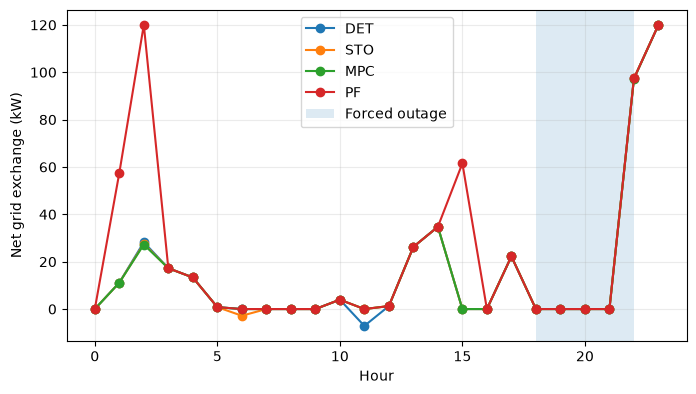

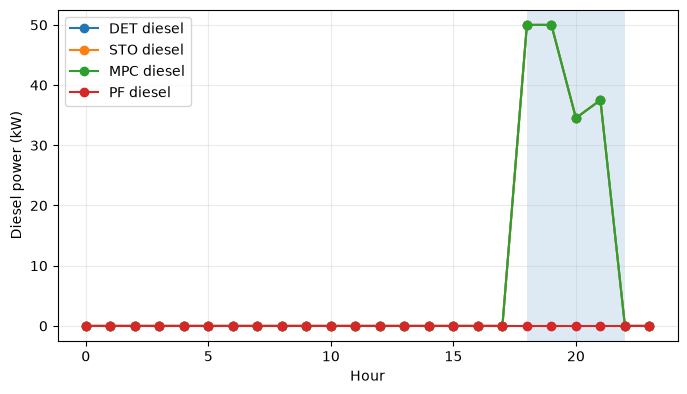

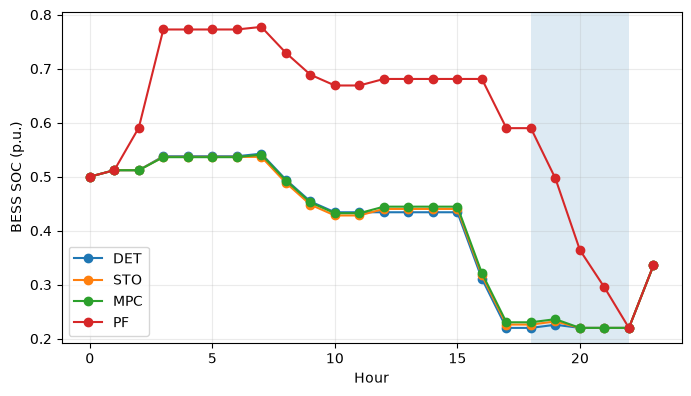

In [49]:
plot_outage_diagnostics(stress_hourly)

## What to send back after running

Please send the outputs in this order:

1. `FORCED-OUTAGE v3 ONE-DAY SMOKE TEST PASSED.` table/output — **stop here first**.
2. Only after we inspect that table together: enable the 127-day run.
3. Full-run final progress line showing `127/127`.
4. `validate_forced_outage(...)` output.
5. `outage_summary` and direct paired comparison output.

Do not reuse any v1/v2 outage checkpoint. v3 writes to `forced_outage_results_v3/`.
Do **not** finalize figures yet.


In [52]:
import pandas as pd
from pathlib import Path

REP_DIR = Path(
    "E:/AIUB Ref. Book & Class Materials/MASTERS/2ND SEMESTER/OPTIMIZATION OF POWER SYSTEM OPERATION/FINAL TERM/Simulation/Rye_Microgrid_Forced_Grid_Outage_FULL/forced_outage_results_v3"
)

date = "2020-11-19"

rep = {}

for s in ["det","sto","mpc","pf"]:
    f = REP_DIR / f"forced_outage_representative_{date}_{s}_hourly.csv"
    rep[s.upper()] = pd.read_csv(f)


rows=[]

for strategy,df in rep.items():

    x=df[
        df["hour"].between(16,23)
    ][[
        "hour",
        "grid_available",
        "soc_start",
        "soc_end",
        "dg",
        "charge",
        "discharge",
        "buy",
        "sell",
        "shed_crit",
        "shed_ncrit"
    ]].copy()

    x["strategy"]=strategy
    rows.append(x)


representative_hourly_summary = pd.concat(
    rows,
    ignore_index=True
)


representative_hourly_summary = representative_hourly_summary[
[
"strategy",
"hour",
"grid_available",
"soc_start",
"soc_end",
"dg",
"charge",
"discharge",
"buy",
"sell",
"shed_crit",
"shed_ncrit"
]
]


display(representative_hourly_summary)


out = REP_DIR / "Table_Representative_Outage_Hourly.csv"

representative_hourly_summary.to_csv(
    out,
    index=False
)

print("Saved:", out)

,strategy,hour,grid_available,soc_start,soc_end,dg,charge,discharge,buy,sell,shed_crit,shed_ncrit
0,DET,16,1,0.500000,0.500000,0.000000e+00,0.000000,0.000000e+00,23.430378,0.0,0.0,0.0
1,DET,17,1,0.500000,0.500000,0.000000e+00,0.000000,0.000000e+00,24.251340,0.0,0.0,0.0
2,DET,18,0,0.500000,0.441030,0.000000e+00,0.000000,2.948517e+01,0.000000,0.0,0.0,0.0
3,DET,19,0,0.441030,0.378200,0.000000e+00,0.000000,3.141475e+01,0.000000,0.0,0.0,0.0
4,DET,20,0,0.378200,0.319249,0.000000e+00,0.000000,2.947574e+01,0.000000,0.0,0.0,0.0
5,DET,21,0,0.319249,0.266938,0.000000e+00,0.000000,2.615532e+01,0.000000,0.0,0.0,0.0
6,DET,22,1,0.266938,0.328404,0.000000e+00,36.156289,0.000000e+00,59.411895,0.0,0.0,0.0
7,DET,23,1,0.328404,0.500000,0.000000e+00,100.938984,0.000000e+00,120.000000,0.0,0.0,0.0
8,STO,16,1,0.500000,0.500000,0.000000e+00,0.000000,0.000000e+00,23.430378,0.0,0.0,0.0
9,STO,17,1,0.500000,0.500000,0.000000e+00,0.000000,0.000000e+00,24.251340,0.0,0.0,0.0


Saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\Table_Representative_Outage_Hourly.csv


In [54]:
for s,df in stress.items():
    print("\n====",s,"====")
    print(df.columns.tolist())


==== DET ====
['hour', 'phase', 'grid_available', 'pv', 'wind', 'dg', 'charge', 'discharge', 'buy', 'sell', 'shed_crit', 'shed_ncrit', 'curtailment', 'soc_start', 'soc_end', 'balance_residual_kw', 'strategy', 'date']

==== STO ====
['hour', 'phase', 'grid_available', 'pv', 'wind', 'dg', 'charge', 'discharge', 'buy', 'sell', 'shed_crit', 'shed_ncrit', 'curtailment', 'soc_start', 'soc_end', 'balance_residual_kw', 'strategy', 'date']

==== MPC ====
['hour', 'grid_available', 'pv', 'wind', 'dg', 'charge', 'discharge', 'buy', 'sell', 'shed_crit', 'shed_ncrit', 'curtailment', 'soc_start', 'soc_end', 'cost_nok', 'critical_eens_kwh', 'noncritical_eens_kwh', 'diesel_kwh', 'curtailment_kwh', 'grid_import_kwh', 'grid_export_kwh', 'anchor_terminal_dev_soc', 'anchor_terminal_dev_kwh', 'balance_residual_kw', 'local_solve_time_s', 'anchor_solve_time_s', 'strategy', 'date']

==== PF ====
['hour', 'phase', 'grid_available', 'pv', 'wind', 'dg', 'charge', 'discharge', 'buy', 'sell', 'shed_crit', 'shed_n

In [55]:
rows=[]

for strategy,df in stress.items():

    cols = [
        "hour",
        "grid_available",
        "soc_start",
        "soc_end",
        "dg",
        "charge",
        "discharge",
        "buy",
        "sell",
        "shed_crit",
        "shed_ncrit"
    ]

    # phase optional
    if "phase" in df.columns:
        cols.insert(1,"phase")

    x=df[
        df["hour"].between(16,23)
    ][cols].copy()

    x["strategy"]=strategy
    rows.append(x)


stress_hourly_summary = pd.concat(
    rows,
    ignore_index=True
)


# reorder
base_cols=[
"strategy",
"hour"
]

if "phase" in stress_hourly_summary.columns:
    base_cols.append("phase")

base_cols += [
"grid_available",
"soc_start",
"soc_end",
"dg",
"charge",
"discharge",
"buy",
"sell",
"shed_crit",
"shed_ncrit"
]

stress_hourly_summary = stress_hourly_summary[base_cols]


display(stress_hourly_summary)


out = STRESS_DIR / "Table_Stress_Outage_Hourly.csv"

stress_hourly_summary.to_csv(
    out,
    index=False
)

print("Saved:", out)

,strategy,hour,phase,grid_available,soc_start,soc_end,dg,charge,discharge,buy,sell,shed_crit,shed_ncrit
0,DET,16,pre_outage,1,0.311098,0.220000,0.000000e+00,0.000000,4.554884e+01,0.000000,0.0,0.0,0.000000
1,DET,17,pre_outage,1,0.220000,0.220000,0.000000e+00,0.000000,0.000000e+00,22.261137,0.0,0.0,0.000000
2,DET,18,post_outage_emergency,0,0.220000,0.225803,5.000000e+01,3.413280,0.000000e+00,0.000000,0.0,0.0,0.000000
3,DET,19,post_outage_emergency,0,0.225803,0.220000,5.000000e+01,0.000000,2.901288e+00,0.000000,0.0,0.0,13.418899
4,DET,20,post_outage_emergency,0,0.220000,0.220000,3.452913e+01,0.000000,0.000000e+00,0.000000,0.0,0.0,0.000000
5,DET,21,post_outage_emergency,0,0.220000,0.220000,3.751187e+01,0.000000,0.000000e+00,0.000000,0.0,0.0,0.000000
6,DET,22,post_outage_emergency,1,0.220000,0.335845,0.000000e+00,68.143899,0.000000e+00,97.374702,0.0,0.0,0.000000
7,DET,23,post_outage_emergency,1,0.335845,0.500000,0.000000e+00,96.561983,0.000000e+00,120.000000,0.0,0.0,0.000000
8,STO,16,pre_outage,1,0.317260,0.226162,0.000000e+00,0.000000,4.554884e+01,0.000000,0.0,0.0,0.000000
9,STO,17,pre_outage,1,0.226162,0.226162,0.000000e+00,0.000000,0.000000e+00,22.261137,0.0,0.0,0.000000


Saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\Table_Stress_Outage_Hourly.csv


In [57]:
# Check available columns in final daily result

print(combined_daily.shape)

for c in combined_daily.columns:
    print(c)

(1016, 61)
date
mode
alpha
det_cost_nok
sto_cost_nok
cou_nok
sto_savings_vs_det_nok
sto_residual_gap_vs_pf_nok
det_critical_eens_kwh
sto_critical_eens_kwh
det_noncritical_eens_kwh
sto_noncritical_eens_kwh
det_critical_interrupted
sto_critical_interrupted
det_diesel_kwh
sto_diesel_kwh
det_curtailment_kwh
sto_curtailment_kwh
det_grid_import_kwh
sto_grid_import_kwh
det_grid_export_kwh
sto_grid_export_kwh
det_solve_time_s
sto_solve_time_s
sto_recourse_time_s
det_max_simultaneous_buy_sell_kw
sto_max_simultaneous_buy_sell_kw
pf_cost_nok
pf_critical_eens_kwh
pf_noncritical_eens_kwh
pf_critical_interrupted
pf_diesel_kwh
pf_curtailment_kwh
pf_grid_import_kwh
pf_grid_export_kwh
pf_solve_time_s
pf_max_simultaneous_buy_sell_kw
Hp
mpc_cost_nok
mpc_critical_eens_kwh
mpc_noncritical_eens_kwh
mpc_critical_interrupted
mpc_diesel_kwh
mpc_curtailment_kwh
mpc_grid_import_kwh
mpc_grid_export_kwh
mpc_total_solve_time_s
mpc_total_local_solve_time_s
mpc_total_anchor_solve_time_s
mpc_mean_hourly_local_solve_ti

In [58]:
print(combined_daily.shape)

print("\nColumns:")
for c in combined_daily.columns:
    print(c)

(1016, 61)

Columns:
date
mode
alpha
det_cost_nok
sto_cost_nok
cou_nok
sto_savings_vs_det_nok
sto_residual_gap_vs_pf_nok
det_critical_eens_kwh
sto_critical_eens_kwh
det_noncritical_eens_kwh
sto_noncritical_eens_kwh
det_critical_interrupted
sto_critical_interrupted
det_diesel_kwh
sto_diesel_kwh
det_curtailment_kwh
sto_curtailment_kwh
det_grid_import_kwh
sto_grid_import_kwh
det_grid_export_kwh
sto_grid_export_kwh
det_solve_time_s
sto_solve_time_s
sto_recourse_time_s
det_max_simultaneous_buy_sell_kw
sto_max_simultaneous_buy_sell_kw
pf_cost_nok
pf_critical_eens_kwh
pf_noncritical_eens_kwh
pf_critical_interrupted
pf_diesel_kwh
pf_curtailment_kwh
pf_grid_import_kwh
pf_grid_export_kwh
pf_solve_time_s
pf_max_simultaneous_buy_sell_kw
Hp
mpc_cost_nok
mpc_critical_eens_kwh
mpc_noncritical_eens_kwh
mpc_critical_interrupted
mpc_diesel_kwh
mpc_curtailment_kwh
mpc_grid_import_kwh
mpc_grid_export_kwh
mpc_total_solve_time_s
mpc_total_local_solve_time_s
mpc_total_anchor_solve_time_s
mpc_mean_hourly_loca

In [59]:
import pandas as pd

def build_operational_summary(combined_daily):

    rows = []

    for s in ["det","sto","mpc","pf"]:

        row = {
            "Strategy": s.upper(),

            "Mean cost (NOK/day)":
                combined_daily[f"{s}_cost_nok"].mean(),

            "Critical EENS (kWh/day)":
                combined_daily[f"{s}_critical_eens_kwh"].mean(),

            "Noncritical EENS (kWh/day)":
                combined_daily[f"{s}_noncritical_eens_kwh"].mean(),

            "Critical interruption probability":
                combined_daily[f"{s}_critical_interrupted"].mean(),

            "Diesel energy (kWh/day)":
                combined_daily[f"{s}_diesel_kwh"].mean(),

            "Curtailment (kWh/day)":
                combined_daily[f"{s}_curtailment_kwh"].mean(),

            "Grid import (kWh/day)":
                combined_daily[f"{s}_grid_import_kwh"].mean(),

            "Grid export (kWh/day)":
                combined_daily[f"{s}_grid_export_kwh"].mean(),

        }


        # solve time column names differ
        if s == "mpc":
            row["Mean solve time (s)"] = (
                combined_daily["mpc_total_solve_time_s"].mean()
            )
        else:
            row["Mean solve time (s)"] = (
                combined_daily[f"{s}_solve_time_s"].mean()
            )


        rows.append(row)


    return pd.DataFrame(rows)


operational_summary = build_operational_summary(combined_daily)

display(operational_summary)

,Strategy,Mean cost (NOK/day),Critical EENS (kWh/day),Noncritical EENS (kWh/day),Critical interruption probability,Diesel energy (kWh/day),Curtailment (kWh/day),Grid import (kWh/day),Grid export (kWh/day),Mean solve time (s)
0,DET,961.915929,0.001086,3.513529,0.000984,195.959023,88.877146,214.995433,95.411196,0.133482
1,STO,941.896504,0.000000,0.511393,0.000000,198.246109,87.741390,214.512881,94.931228,3.466781
2,MPC,937.904392,0.000000,0.101460,0.000000,198.212809,87.194678,214.392006,94.610660,1.707547
3,PF,934.806910,0.000000,0.000000,0.000000,197.853119,86.959938,214.272681,94.618523,0.064516


In [60]:
operational_summary.to_csv(
    "Operational_Performance_Summary.csv",
    index=False
)

print("Saved")

Saved


In [61]:
def build_master_results_table(combined_daily, outage_summary):

    rows=[]

    # GC + IS
    for mode in ["GC","IS"]:

        df = combined_daily[
            combined_daily["mode"].astype(str)==mode
        ].copy()

        df = df[np.isclose(df["alpha"],0.2)]

        assert len(df)>0, f"No data for {mode}"

        for s in ["det","sto","mpc","pf"]:

            rows.append({
                "scenario": mode,
                "strategy": s.upper(),
                "mean_cost_nok":
                    df[f"{s}_cost_nok"].mean(),

                "critical_eens_kwh":
                    df[f"{s}_critical_eens_kwh"].mean(),

                "noncritical_eens_kwh":
                    df[f"{s}_noncritical_eens_kwh"].mean(),

                "diesel_kwh":
                    df[f"{s}_diesel_kwh"].mean(),

                "solve_time_s":
                    df[f"{s}_solve_time_s"].mean()
                    if f"{s}_solve_time_s" in df.columns
                    else np.nan
            })


    # Forced outage

    for _,r in outage_summary.iterrows():

        rows.append({

            "scenario":"Forced outage",

            "strategy":r["strategy"],

            "mean_cost_nok":
                r["outage_mean_cost_nok"],

            "critical_eens_kwh":
                r["outage_critical_eens_kwh"],

            "noncritical_eens_kwh":
                r["outage_noncritical_eens_kwh"],

            "diesel_kwh":
                r["diesel_energy_kwh"],

            "solve_time_s":
                r["mean_total_solve_time_s"]

        })


    return pd.DataFrame(rows)



master_results = build_master_results_table(
    combined_daily,
    outage_summary
)


display(master_results)

,scenario,strategy,mean_cost_nok,critical_eens_kwh,noncritical_eens_kwh,diesel_kwh,solve_time_s
0,GC,DET,150.418153,0.0,0.000000,0.000000e+00,0.101682
1,GC,STO,150.240158,0.0,0.000000,0.000000e+00,2.972282
2,GC,MPC,150.409431,0.0,0.001194,-1.499106e-15,NaN
3,GC,PF,150.116163,0.0,0.000000,-1.055673e-15,0.058183
4,IS,DET,1793.875464,0.0,10.011549,3.897842e+02,0.118065
5,IS,STO,1733.853681,0.0,1.314088,3.957783e+02,4.658092
6,IS,MPC,1726.677692,0.0,0.253443,3.965796e+02,NaN
7,IS,PF,1719.497658,0.0,0.000000,3.957062e+02,0.070850
8,Forced outage,DET,242.850399,0.0,0.298651,1.601587e+01,0.151633
9,Forced outage,STO,241.362140,0.0,0.259231,1.578761e+01,3.089368


In [62]:
master_results_clean = master_results.copy()

for c in [
    "diesel_kwh",
    "critical_eens_kwh",
    "noncritical_eens_kwh"
]:
    master_results_clean[c] = (
        master_results_clean[c]
        .clip(lower=0)
        .round(3)
    )

master_results_clean["mean_cost_nok"] = (
    master_results_clean["mean_cost_nok"]
    .round(2)
)

master_results_clean["solve_time_s"] = (
    master_results_clean["solve_time_s"]
    .round(3)
)

display(master_results_clean)

,scenario,strategy,mean_cost_nok,critical_eens_kwh,noncritical_eens_kwh,diesel_kwh,solve_time_s
0,GC,DET,150.42,0.0,0.000,0.000,0.102
1,GC,STO,150.24,0.0,0.000,0.000,2.972
2,GC,MPC,150.41,0.0,0.001,0.000,NaN
3,GC,PF,150.12,0.0,0.000,0.000,0.058
4,IS,DET,1793.88,0.0,10.012,389.784,0.118
5,IS,STO,1733.85,0.0,1.314,395.778,4.658
6,IS,MPC,1726.68,0.0,0.253,396.580,NaN
7,IS,PF,1719.50,0.0,0.000,395.706,0.071
8,Forced outage,DET,242.85,0.0,0.299,16.016,0.152
9,Forced outage,STO,241.36,0.0,0.259,15.788,3.089


In [63]:
MASTER_TABLE_FILE = (
    OUT_DIR /
    "Table_Master_Performance_Comparison.csv"
)

master_results_clean.to_csv(
    MASTER_TABLE_FILE,
    index=False
)

print(MASTER_TABLE_FILE)

E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\Table_Master_Performance_Comparison.csv


strategy,DET,STO,MPC,PF
scenario,,,,
GC,150.42,150.24,150.41,150.12
IS,1793.88,1733.85,1726.68,1719.50
Forced outage,242.85,241.36,245.15,175.43


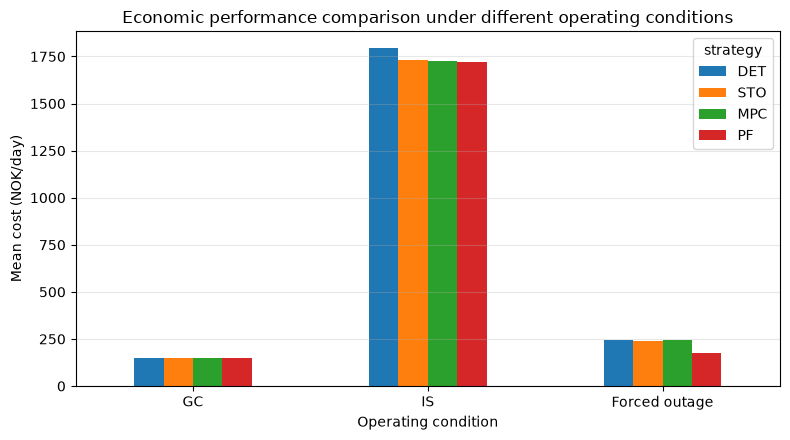

Saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\Fig1_Mean_Cost_Comparison.png


In [64]:
import matplotlib.pyplot as plt
import numpy as np


fig_df = master_results_clean.copy()


scenario_order = [
    "GC",
    "IS",
    "Forced outage"
]

strategy_order = [
    "DET",
    "STO",
    "MPC",
    "PF"
]


fig_df["scenario"] = pd.Categorical(
    fig_df["scenario"],
    categories=scenario_order,
    ordered=True
)

fig_df["strategy"] = pd.Categorical(
    fig_df["strategy"],
    categories=strategy_order,
    ordered=True
)


pivot = fig_df.pivot(
    index="scenario",
    columns="strategy",
    values="mean_cost_nok"
)


display(pivot)



ax = pivot.plot(
    kind="bar",
    figsize=(8,4.5)
)


ax.set_xlabel("Operating condition")
ax.set_ylabel("Mean cost (NOK/day)")

ax.set_title(
    "Economic performance comparison under different operating conditions"
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(rotation=0)

plt.tight_layout()


FIG1 = OUT_DIR / "Fig1_Mean_Cost_Comparison.png"

plt.savefig(
    FIG1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("Saved:", FIG1)

In [72]:
import matplotlib.pyplot as plt
import pandas as pd


fig_df = master_results_clean.copy()

scenario_order = [
    "GC",
    "IS",
    "Forced outage"
]

strategy_order = [
    "DET",
    "STO",
    "MPC",
    "PF"
]


fig_df["scenario"] = pd.Categorical(
    fig_df["scenario"],
    categories=scenario_order,
    ordered=True
)

fig_df["strategy"] = pd.Categorical(
    fig_df["strategy"],
    categories=strategy_order,
    ordered=True
)

fig_df = fig_df.sort_values(
    ["scenario","strategy"]
)



# IEEE single-column friendly size
fig, axes = plt.subplots(
    1,
    3,
    figsize=(7.2, 2.6)
)



titles = [
    "(a) GC",
    "(b) Islanded",
    "(c) Forced outage"
]


for ax, scenario, title in zip(
    axes,
    scenario_order,
    titles
):

    data = fig_df[
        fig_df["scenario"] == scenario
    ]

    ax.bar(
        data["strategy"],
        data["mean_cost_nok"]
    )

    ax.set_title(
        title,
        fontsize=9
    )

    ax.set_xlabel(
        "Strategy",
        fontsize=8
    )

    ax.set_ylabel(
        "NOK/day",
        fontsize=8
    )

    ax.tick_params(
        labelsize=8
    )

    ax.grid(
        axis="y",
        alpha=0.3
    )


plt.tight_layout()


# ============================
# Save as IEEE PDF
# ============================

FIG1_PDF = (
    OUT_DIR /
    "Fig1_Mean_Cost_Comparison_IEEE.pdf"
)


plt.savefig(
    FIG1_PDF,
    format="pdf",
    bbox_inches="tight"
)


plt.close()


print("Saved:", FIG1_PDF)

Saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\Fig1_Mean_Cost_Comparison_IEEE.pdf


In [78]:
for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        print(name, obj.shape)

dev (7296, 15)
oos (3048, 15)
combined_daily (1016, 61)
actual_smoke (24, 9)
forecast_smoke (24, 9)
det_h (24, 16)
sto_h (24, 16)
pf_h (24, 16)
mpc_h (24, 26)
smoke (4, 27)
dispatch_audit (32, 15)
forced_outage_daily (127, 104)
outage_with_baseline (127, 124)
outage_summary (4, 20)
df (24, 28)
x (8, 13)
representative_hourly_summary (32, 12)
stress_hourly_summary (32, 13)
operational_summary (4, 10)
master_results (12, 7)
master_results_clean (12, 7)
fig_df (12, 7)
pivot (3, 4)
sub (4, 7)
data (4, 7)


In [79]:
display(master_results_clean)

,scenario,strategy,mean_cost_nok,critical_eens_kwh,noncritical_eens_kwh,diesel_kwh,solve_time_s
0,GC,DET,150.42,0.0,0.000,0.000,0.102
1,GC,STO,150.24,0.0,0.000,0.000,2.972
2,GC,MPC,150.41,0.0,0.001,0.000,NaN
3,GC,PF,150.12,0.0,0.000,0.000,0.058
4,IS,DET,1793.88,0.0,10.012,389.784,0.118
5,IS,STO,1733.85,0.0,1.314,395.778,4.658
6,IS,MPC,1726.68,0.0,0.253,396.580,NaN
7,IS,PF,1719.50,0.0,0.000,395.706,0.071
8,Forced outage,DET,242.85,0.0,0.299,16.016,0.152
9,Forced outage,STO,241.36,0.0,0.259,15.788,3.089


In [2]:
import pandas as pd
import numpy as np

# make a safe copy
df = master_results_clean.copy()

# ensure numeric
for c in ["mean_cost_nok", "critical_eens_kwh", "noncritical_eens_kwh", "diesel_kwh", "solve_time_s"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

rows = []

for scenario in ["GC", "IS"]:
    sub = df[df["scenario"] == scenario].copy()

    det = float(sub[sub["strategy"] == "DET"]["mean_cost_nok"].iloc[0])
    sto = float(sub[sub["strategy"] == "STO"]["mean_cost_nok"].iloc[0])
    mpc = float(sub[sub["strategy"] == "MPC"]["mean_cost_nok"].iloc[0])
    pf  = float(sub[sub["strategy"] == "PF"]["mean_cost_nok"].iloc[0])

    cou = det - pf

    smr = np.nan
    rr = np.nan
    if cou > 1e-12:
        smr = (det - sto) / cou * 100
        rr  = (det - mpc) / cou * 100

    rows.append({
        "scenario": scenario,
        "DET": det,
        "STO": sto,
        "MPC": mpc,
        "PF": pf,
        "CoU_nok_day": cou,
        "SMR_percent": smr,
        "RR_percent": rr,
    })

cou_table = pd.DataFrame(rows)

display(cou_table.round(4))

NameError: name 'master_results_clean' is not defined

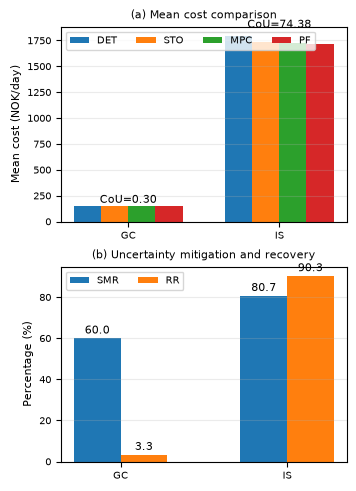

Saved PDF: Fig2_CoU_SMR_RR_GC_IS.pdf
Saved PNG: Fig2_CoU_SMR_RR_GC_IS.png


In [82]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ---------- input ----------
plot_df = cou_table.copy()

# output path
OUT_DIR = Path(".")
fig_path_pdf = OUT_DIR / "Fig2_CoU_SMR_RR_GC_IS.pdf"
fig_path_png = OUT_DIR / "Fig2_CoU_SMR_RR_GC_IS.png"

# ---------- style ----------
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})

# ---------- figure ----------
fig, axes = plt.subplots(
    2, 1,
    figsize=(3.45, 4.8),   # IEEE single-column width
    constrained_layout=True
)

# =========================
# (a) Mean cost comparison
# =========================
ax = axes[0]

scenarios = plot_df["scenario"].tolist()
x = np.arange(len(scenarios))
w = 0.18

det_vals = plot_df["DET"].values
sto_vals = plot_df["STO"].values
mpc_vals = plot_df["MPC"].values
pf_vals  = plot_df["PF"].values

ax.bar(x - 1.5*w, det_vals, width=w, label="DET")
ax.bar(x - 0.5*w, sto_vals, width=w, label="STO")
ax.bar(x + 0.5*w, mpc_vals, width=w, label="MPC")
ax.bar(x + 1.5*w, pf_vals,  width=w, label="PF")

ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel("Mean cost (NOK/day)")
ax.set_title("(a) Mean cost comparison")
ax.grid(axis="y", alpha=0.25)
ax.legend(ncol=4, loc="upper left", frameon=True)

# annotate CoU above GC and IS DET/PF gap
for i, row in plot_df.iterrows():
    cou = row["CoU_nok_day"]
    y_top = max(row["DET"], row["PF"])
    ax.text(i, y_top + 0.03*y_top, f"CoU={cou:.2f}",
            ha="center", va="bottom")

# =========================
# (b) SMR and RR
# =========================
ax = axes[1]

x = np.arange(len(scenarios))
w = 0.28

smr_vals = plot_df["SMR_percent"].values
rr_vals  = plot_df["RR_percent"].values

ax.bar(x - w/2, smr_vals, width=w, label="SMR")
ax.bar(x + w/2, rr_vals,  width=w, label="RR")

ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel("Percentage (%)")
ax.set_title("(b) Uncertainty mitigation and recovery")
ax.grid(axis="y", alpha=0.25)
ax.legend(ncol=2, loc="upper left", frameon=True)

# annotate values
for i, v in enumerate(smr_vals):
    ax.text(i - w/2, v + 1.0, f"{v:.1f}", ha="center", va="bottom")
for i, v in enumerate(rr_vals):
    ax.text(i + w/2, v + 1.0, f"{v:.1f}", ha="center", va="bottom")

# save
fig.savefig(fig_path_pdf, bbox_inches="tight")
fig.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved PDF:", fig_path_pdf)
print("Saved PNG:", fig_path_png)

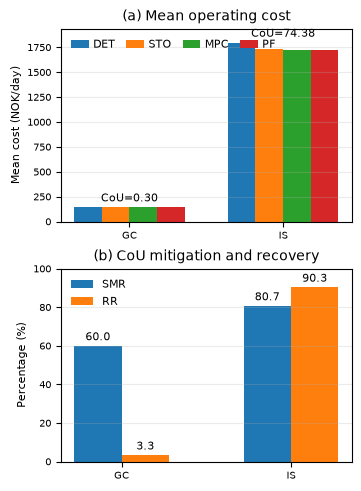

Saved PNG: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\Fig2_CoU_SMR_RR_GC_IS.png
Saved PDF: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\Fig2_CoU_SMR_RR_GC_IS.pdf


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Input data (GC and IS only)
# -----------------------------
data = pd.DataFrame({
    "scenario": ["GC", "IS"],
    "DET": [150.42, 1793.88],
    "STO": [150.24, 1733.85],
    "MPC": [150.41, 1726.68],
    "PF":  [150.12, 1719.50],
    "CoU_nok_day": [0.30, 74.38],
    "SMR_percent": [60.0, 80.7072],
    "RR_percent": [3.3333, 90.3469],
})

# -----------------------------
# Figure settings
# IEEE single-column friendly
# -----------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(3.5, 4.8),   # single-column friendly
    constrained_layout=True
)

# =========================================================
# (a) Mean operating cost
# =========================================================
ax = axes[0]

scenarios = data["scenario"].tolist()
x = np.arange(len(scenarios))
width = 0.18

strategies = ["DET", "STO", "MPC", "PF"]

for i, s in enumerate(strategies):
    ax.bar(
        x + (i - 1.5) * width,
        data[s],
        width=width,
        label=s
    )

ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel("Mean cost (NOK/day)")
ax.set_title("(a) Mean operating cost", fontsize=10)
ax.grid(axis="y", alpha=0.25)

# Compact legend
ax.legend(
    ncol=4,
    fontsize=8,
    frameon=False,
    loc="upper left",
    handlelength=1.6,
    columnspacing=1.0,
    handletextpad=0.4
)

# CoU labels placed clearly above each scenario group
for i, row in data.iterrows():
    group_max = max(row["DET"], row["STO"], row["MPC"], row["PF"])
    offset = 25 if row["scenario"] == "GC" else 35
    ax.text(
        x[i],
        group_max + offset,
        f"CoU={row['CoU_nok_day']:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# Add a little headroom so the IS label doesn't look cramped
ax.set_ylim(0, max(data[["DET", "STO", "MPC", "PF"]].max()) * 1.08)

# =========================================================
# (b) CoU mitigation and recovery
# =========================================================
ax2 = axes[1]

width2 = 0.28
ax2.bar(x - width2/2, data["SMR_percent"], width=width2, label="SMR")
ax2.bar(x + width2/2, data["RR_percent"],  width=width2, label="RR")

ax2.set_xticks(x)
ax2.set_xticklabels(scenarios)
ax2.set_ylabel("Percentage (%)")
ax2.set_title("(b) CoU mitigation and recovery", fontsize=10)
ax2.grid(axis="y", alpha=0.25)
ax2.legend(fontsize=8, frameon=False, loc="upper left")

# Value labels
for i, v in enumerate(data["SMR_percent"]):
    ax2.text(x[i] - width2/2, v + 1.5, f"{v:.1f}",
             ha="center", va="bottom", fontsize=8)

for i, v in enumerate(data["RR_percent"]):
    ax2.text(x[i] + width2/2, v + 1.5, f"{v:.1f}",
             ha="center", va="bottom", fontsize=8)

ax2.set_ylim(0, 100)

# -----------------------------
# Save figures
# -----------------------------
out_png = r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\Fig2_CoU_SMR_RR_GC_IS.png"
out_pdf = r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\Fig2_CoU_SMR_RR_GC_IS.pdf"

plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()

print("Saved PNG:", out_png)
print("Saved PDF:", out_pdf)

In [91]:
# =========================================================
# Fig.2 Polished Final:
# GC vs IS cost comparison + CoU mitigation/recovery
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# File paths
# ---------------------------------------------------------
summary_file = Path("Operational_Performance_Summary.csv")
daily_file = Path("final_oos_det_sto_mpc_pf_daily.csv")

# Output folder
outdir = Path("forced_outage_results_v3/Fig2")
outdir.mkdir(parents=True, exist_ok=True)

pdf_path = outdir / "Fig2_CoU_SMR_RR_GC_IS_Polished.pdf"
png_path = outdir / "Fig2_CoU_SMR_RR_GC_IS_Polished.png"
csv_path = outdir / "Fig2_CoU_SMR_RR_GC_IS_Summary.csv"

# ---------------------------------------------------------
# Load / build summary data
# ---------------------------------------------------------
if summary_file.exists():
    summary = pd.read_csv(summary_file)
    summary.columns = [c.strip() for c in summary.columns]

    # normalize possible alternative column names
    rename_map = {}
    if "scenario" in summary.columns and "mode" not in summary.columns:
        rename_map["scenario"] = "mode"
    summary = summary.rename(columns=rename_map)

    required_cols = {"mode", "DET", "STO", "MPC", "PF", "CoU", "SMR", "RR"}
    missing = required_cols - set(summary.columns)
    if missing:
        raise ValueError(
            f"Operational_Performance_Summary.csv is missing columns: {missing}"
        )

    summary = summary[["mode", "DET", "STO", "MPC", "PF", "CoU", "SMR", "RR"]].copy()

else:
    if not daily_file.exists():
        raise FileNotFoundError(
            "Neither Operational_Performance_Summary.csv nor "
            "final_oos_det_sto_mpc_pf_daily.csv was found."
        )

    df = pd.read_csv(daily_file)
    df.columns = [c.strip() for c in df.columns]
    df["mode"] = df["mode"].astype(str).str.upper().str.strip()

    summary = (
        df.groupby("mode", as_index=False)
        .agg(
            DET=("det_cost_nok", "mean"),
            STO=("sto_cost_nok", "mean"),
            MPC=("mpc_cost_nok", "mean"),
            PF=("pf_cost_nok", "mean"),
        )
        .copy()
    )

    summary["CoU"] = summary["DET"] - summary["PF"]
    gap = summary["DET"] - summary["PF"]

    summary["SMR"] = np.where(
        gap.abs() > 1e-12,
        100.0 * (summary["DET"] - summary["STO"]) / gap,
        np.nan
    )

    summary["RR"] = np.where(
        gap.abs() > 1e-12,
        100.0 * (summary["DET"] - summary["MPC"]) / gap,
        np.nan
    )

# ---------------------------------------------------------
# Keep only GC and IS, sort order
# ---------------------------------------------------------
summary["mode"] = summary["mode"].astype(str).str.upper().str.strip()
mode_order = ["GC", "IS"]
summary = summary[summary["mode"].isin(mode_order)].copy()
summary["mode"] = pd.Categorical(summary["mode"], categories=mode_order, ordered=True)
summary = summary.sort_values("mode").reset_index(drop=True)

if len(summary) != 2:
    raise ValueError("Expected exactly two modes: GC and IS.")

# Save summary used for plotting
summary.to_csv(csv_path, index=False)

print("Summary used for Fig.2:")
print(summary.round(3))
print("Saved summary CSV:", csv_path)

# ---------------------------------------------------------
# Helper: bar labels
# ---------------------------------------------------------
def add_bar_labels(ax, bars, fmt="{:.1f}", fontsize=7, offset_frac=0.012):
    y0, y1 = ax.get_ylim()
    span = y1 - y0
    offset = offset_frac * span

    for bar in bars:
        h = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2

        if np.isnan(h):
            continue

        if h >= 0:
            ax.text(
                x, h + offset, fmt.format(h),
                ha="center", va="bottom", fontsize=fontsize
            )
        else:
            ax.text(
                x, h - offset, fmt.format(h),
                ha="center", va="top", fontsize=fontsize
            )

# ---------------------------------------------------------
# Plot settings
# ---------------------------------------------------------
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "legend.fontsize": 7.5,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

colors = {
    "DET": "tab:blue",
    "STO": "tab:orange",
    "MPC": "tab:green",
    "PF":  "tab:red",
}

# IEEE single-column friendly
fig, axes = plt.subplots(
    2, 1,
    figsize=(3.45, 4.9),
    constrained_layout=True
)

# =========================================================
# (a) Mean operating cost
# =========================================================
ax = axes[0]

x = np.arange(len(summary))
width = 0.18
strategies = ["DET", "STO", "MPC", "PF"]

bar_groups = []
for i, s in enumerate(strategies):
    bars = ax.bar(
        x + (i - 1.5) * width,
        summary[s],
        width=width,
        label=s,
        color=colors[s],
        edgecolor="black",
        linewidth=0.4
    )
    bar_groups.append(bars)

ax.set_xticks(x)
ax.set_xticklabels(summary["mode"])
ax.set_ylabel("Mean cost (NOK/day)")
ax.set_title("(a) Mean operating cost")
ax.grid(axis="y", alpha=0.25, linewidth=0.6)

# Dynamic ylim
cost_max = summary[strategies].to_numpy().max()
ax.set_ylim(0, cost_max * 1.13)

# Legend
ax.legend(
    ncol=4,
    loc="upper left",
    frameon=False,
    handlelength=1.4,
    columnspacing=0.9,
    handletextpad=0.4
)

# Value labels for each bar
for bars in bar_groups:
    add_bar_labels(ax, bars, fmt="{:.1f}", fontsize=6.5, offset_frac=0.010)

# CoU annotation per mode
y0, y1 = ax.get_ylim()
span = y1 - y0
for i, row in summary.iterrows():
    group_max = max(row["DET"], row["STO"], row["MPC"], row["PF"])
    ax.text(
        x[i],
        group_max + 0.045 * span,
        f"CoU = {row['CoU']:.2f}",
        ha="center",
        va="bottom",
        fontsize=7.5
    )

# =========================================================
# (b) CoU mitigation and recovery
# =========================================================
ax2 = axes[1]

width2 = 0.28
bars_smr = ax2.bar(
    x - width2 / 2,
    summary["SMR"],
    width=width2,
    label="SMR",
    color="tab:blue",
    edgecolor="black",
    linewidth=0.4
)

bars_rr = ax2.bar(
    x + width2 / 2,
    summary["RR"],
    width=width2,
    label="RR",
    color="tab:orange",
    edgecolor="black",
    linewidth=0.4
)

ax2.set_xticks(x)
ax2.set_xticklabels(summary["mode"])
ax2.set_ylabel("Percentage (%)")
ax2.set_title("(b) CoU mitigation and recovery")
ax2.grid(axis="y", alpha=0.25, linewidth=0.6)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.legend(loc="upper left", frameon=False)

# Dynamic ylim to allow negative RR if present
metric_vals = np.concatenate([summary["SMR"].values, summary["RR"].values, [0]])
mmin = np.nanmin(metric_vals)
mmax = np.nanmax(metric_vals)
mspan = mmax - mmin if (mmax - mmin) > 1e-9 else 1.0

ax2.set_ylim(
    mmin - 0.15 * mspan,
    mmax + 0.15 * mspan
)

# Value labels
add_bar_labels(ax2, bars_smr, fmt="{:.1f}", fontsize=7, offset_frac=0.02)
add_bar_labels(ax2, bars_rr,  fmt="{:.1f}", fontsize=7, offset_frac=0.02)

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=600, bbox_inches="tight")

plt.show()

print("Saved PDF:", pdf_path)
print("Saved PNG:", png_path)

ValueError: Operational_Performance_Summary.csv is missing columns: {'DET', 'mode', 'CoU', 'PF', 'STO', 'MPC', 'RR', 'SMR'}

In [96]:
summary_file = Path("Operational_Performance_Summary.csv")

daily_file = Path("final_oos_det_sto_mpc_pf_daily.csv")

print(summary_file.exists())
print(daily_file.exists())

True
True


In [97]:
print(summary.round(3))

  Strategy  Mean cost (NOK/day)  Critical EENS (kWh/day)  \
0      DET              961.916                    0.001   
1      STO              941.897                    0.000   
2      MPC              937.904                    0.000   
3       PF              934.807                    0.000   

   Noncritical EENS (kWh/day)  Critical interruption probability  \
0                       3.514                              0.001   
1                       0.511                              0.000   
2                       0.101                              0.000   
3                       0.000                              0.000   

   Diesel energy (kWh/day)  Curtailment (kWh/day)  Grid import (kWh/day)  \
0                  195.959                 88.877                214.995   
1                  198.246                 87.741                214.513   
2                  198.213                 87.195                214.392   
3                  197.853                 86.960     

In [99]:
import pandas as pd

df = pd.read_csv("final_oos_det_sto_mpc_pf_daily.csv")

print(df.columns.tolist())

print(df["mode"].value_counts())

print(df.groupby("mode")[[
    "det_cost_nok",
    "sto_cost_nok",
    "mpc_cost_nok",
    "pf_cost_nok"
]].mean())

['date', 'mode', 'alpha', 'det_cost_nok', 'sto_cost_nok', 'cou_nok', 'sto_savings_vs_det_nok', 'sto_residual_gap_vs_pf_nok', 'det_critical_eens_kwh', 'sto_critical_eens_kwh', 'det_noncritical_eens_kwh', 'sto_noncritical_eens_kwh', 'det_critical_interrupted', 'sto_critical_interrupted', 'det_diesel_kwh', 'sto_diesel_kwh', 'det_curtailment_kwh', 'sto_curtailment_kwh', 'det_grid_import_kwh', 'sto_grid_import_kwh', 'det_grid_export_kwh', 'sto_grid_export_kwh', 'det_solve_time_s', 'sto_solve_time_s', 'sto_recourse_time_s', 'det_max_simultaneous_buy_sell_kw', 'sto_max_simultaneous_buy_sell_kw', 'pf_cost_nok', 'pf_critical_eens_kwh', 'pf_noncritical_eens_kwh', 'pf_critical_interrupted', 'pf_diesel_kwh', 'pf_curtailment_kwh', 'pf_grid_import_kwh', 'pf_grid_export_kwh', 'pf_solve_time_s', 'pf_max_simultaneous_buy_sell_kw', 'Hp', 'mpc_cost_nok', 'mpc_critical_eens_kwh', 'mpc_noncritical_eens_kwh', 'mpc_critical_interrupted', 'mpc_diesel_kwh', 'mpc_curtailment_kwh', 'mpc_grid_import_kwh', 'mpc_gr

Fig.2 summary:
  mode       DET       STO       MPC        PF     CoU     SMR      RR
0   GC   150.385   150.342   150.468   150.116   0.269  16.128 -30.888
1   IS  1773.447  1733.451  1725.340  1719.498  53.949  74.136  89.170


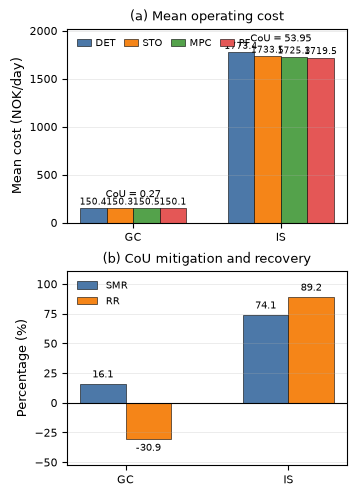

Saved summary CSV: forced_outage_results_v3\Fig2\Fig2_CoU_SMR_RR_GC_IS_summary.csv
Saved PDF: forced_outage_results_v3\Fig2\Fig2_CoU_SMR_RR_GC_IS_Polished.pdf
Saved PNG: forced_outage_results_v3\Fig2\Fig2_CoU_SMR_RR_GC_IS_Polished.png


In [100]:
# =========================================================
# Fig.2 Polished Final
# GC vs IS: Mean cost + CoU mitigation/recovery
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Load daily OOS results
# ---------------------------------------------------------
csv_file = Path("final_oos_det_sto_mpc_pf_daily.csv")
if not csv_file.exists():
    raise FileNotFoundError(f"Could not find: {csv_file.resolve()}")

df = pd.read_csv(csv_file)
df.columns = [c.strip() for c in df.columns]
df["mode"] = df["mode"].astype(str).str.upper().str.strip()

# ---------------------------------------------------------
# Build summary for GC and IS
# ---------------------------------------------------------
summary = (
    df.groupby("mode", as_index=False)
    .agg(
        DET=("det_cost_nok", "mean"),
        STO=("sto_cost_nok", "mean"),
        MPC=("mpc_cost_nok", "mean"),
        PF=("pf_cost_nok", "mean"),
    )
    .copy()
)

summary["CoU"] = summary["DET"] - summary["PF"]
gap = summary["DET"] - summary["PF"]

summary["SMR"] = np.where(
    gap.abs() > 1e-12,
    100.0 * (summary["DET"] - summary["STO"]) / gap,
    np.nan
)

summary["RR"] = np.where(
    gap.abs() > 1e-12,
    100.0 * (summary["DET"] - summary["MPC"]) / gap,
    np.nan
)

mode_order = ["GC", "IS"]
summary = summary[summary["mode"].isin(mode_order)].copy()
summary["mode"] = pd.Categorical(summary["mode"], categories=mode_order, ordered=True)
summary = summary.sort_values("mode").reset_index(drop=True)

print("Fig.2 summary:")
print(summary.round(3))

# Save summary table used in the figure
outdir = Path("forced_outage_results_v3/Fig2")
outdir.mkdir(parents=True, exist_ok=True)

summary_csv = outdir / "Fig2_CoU_SMR_RR_GC_IS_summary.csv"
summary.to_csv(summary_csv, index=False)

# ---------------------------------------------------------
# Helper for bar labels
# ---------------------------------------------------------
def add_bar_labels(ax, bars, fmt="{:.1f}", fontsize=7, dy_frac=0.012):
    y0, y1 = ax.get_ylim()
    dy = (y1 - y0) * dy_frac
    for bar in bars:
        h = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        if np.isnan(h):
            continue
        if h >= 0:
            ax.text(x, h + dy, fmt.format(h), ha="center", va="bottom", fontsize=fontsize)
        else:
            ax.text(x, h - dy, fmt.format(h), ha="center", va="top", fontsize=fontsize)

# ---------------------------------------------------------
# Plot settings
# ---------------------------------------------------------
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 7.5,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

colors = {
    "DET": "#4C78A8",
    "STO": "#F58518",
    "MPC": "#54A24B",
    "PF":  "#E45756",
    "SMR": "#4C78A8",
    "RR":  "#F58518",
}

# IEEE single-column friendly
fig, axes = plt.subplots(
    2, 1,
    figsize=(3.45, 4.85),
    constrained_layout=True
)

# =========================================================
# (a) Mean operating cost
# =========================================================
ax = axes[0]

x = np.arange(len(summary))
width = 0.18
strategies = ["DET", "STO", "MPC", "PF"]

bar_groups = []
for i, s in enumerate(strategies):
    bars = ax.bar(
        x + (i - 1.5) * width,
        summary[s],
        width=width,
        label=s,
        color=colors[s],
        edgecolor="black",
        linewidth=0.4
    )
    bar_groups.append(bars)

ax.set_xticks(x)
ax.set_xticklabels(summary["mode"])
ax.set_ylabel("Mean cost (NOK/day)")
ax.set_title("(a) Mean operating cost")
ax.grid(axis="y", alpha=0.28, linewidth=0.6)

cost_max = summary[strategies].to_numpy().max()
ax.set_ylim(0, cost_max * 1.14)

ax.legend(
    ncol=4,
    loc="upper left",
    frameon=False,
    handlelength=1.4,
    columnspacing=0.8,
    handletextpad=0.4
)

for bars in bar_groups:
    add_bar_labels(ax, bars, fmt="{:.1f}", fontsize=6.2, dy_frac=0.008)

# CoU annotations
y0, y1 = ax.get_ylim()
span = y1 - y0
for i, row in summary.iterrows():
    group_max = max(row["DET"], row["STO"], row["MPC"], row["PF"])
    ax.text(
        x[i],
        group_max + 0.045 * span,
        f"CoU = {row['CoU']:.2f}",
        ha="center",
        va="bottom",
        fontsize=7.2
    )

# =========================================================
# (b) CoU mitigation and recovery
# =========================================================
ax2 = axes[1]

width2 = 0.28
bars_smr = ax2.bar(
    x - width2 / 2,
    summary["SMR"],
    width=width2,
    label="SMR",
    color=colors["SMR"],
    edgecolor="black",
    linewidth=0.4
)

bars_rr = ax2.bar(
    x + width2 / 2,
    summary["RR"],
    width=width2,
    label="RR",
    color=colors["RR"],
    edgecolor="black",
    linewidth=0.4
)

ax2.set_xticks(x)
ax2.set_xticklabels(summary["mode"])
ax2.set_ylabel("Percentage (%)")
ax2.set_title("(b) CoU mitigation and recovery")
ax2.grid(axis="y", alpha=0.28, linewidth=0.6)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.legend(loc="upper left", frameon=False)

metric_vals = np.concatenate([summary["SMR"].values, summary["RR"].values, [0]])
mmin = np.nanmin(metric_vals)
mmax = np.nanmax(metric_vals)
mspan = max(mmax - mmin, 1.0)

ax2.set_ylim(mmin - 0.18 * mspan, mmax + 0.18 * mspan)

add_bar_labels(ax2, bars_smr, fmt="{:.1f}", fontsize=7, dy_frac=0.02)
add_bar_labels(ax2, bars_rr,  fmt="{:.1f}", fontsize=7, dy_frac=0.02)

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------
pdf_path = outdir / "Fig2_CoU_SMR_RR_GC_IS_Polished.pdf"
png_path = outdir / "Fig2_CoU_SMR_RR_GC_IS_Polished.png"

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=600, bbox_inches="tight")

plt.show()

print("Saved summary CSV:", summary_csv)
print("Saved PDF:", pdf_path)
print("Saved PNG:", png_path)

  mode       DET       STO       MPC        PF     CoU     SMR      RR
0   GC   150.385   150.342   150.468   150.116   0.269  16.128 -30.888
1   IS  1773.447  1733.451  1725.340  1719.498  53.949  74.136  89.170


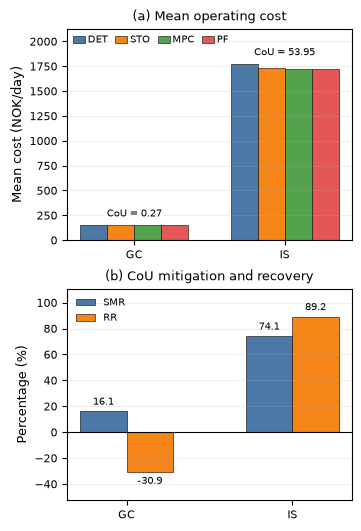

Saved summary CSV: forced_outage_results_v3\Fig2\Fig2_CoU_SMR_RR_GC_IS_Clean_IEEE_summary.csv
Saved PDF: forced_outage_results_v3\Fig2\Fig2_CoU_SMR_RR_GC_IS_Clean_IEEE.pdf
Saved PNG: forced_outage_results_v3\Fig2\Fig2_CoU_SMR_RR_GC_IS_Clean_IEEE.png


In [101]:
# =========================================================
# Fig.2 Clean IEEE Final
# GC vs IS: mean cost + CoU mitigation/recovery
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Load daily OOS results
# ---------------------------------------------------------
csv_file = Path("final_oos_det_sto_mpc_pf_daily.csv")
if not csv_file.exists():
    raise FileNotFoundError(f"Could not find: {csv_file.resolve()}")

df = pd.read_csv(csv_file)
df.columns = [c.strip() for c in df.columns]
df["mode"] = df["mode"].astype(str).str.upper().str.strip()

# ---------------------------------------------------------
# Build summary
# ---------------------------------------------------------
summary = (
    df.groupby("mode", as_index=False)
    .agg(
        DET=("det_cost_nok", "mean"),
        STO=("sto_cost_nok", "mean"),
        MPC=("mpc_cost_nok", "mean"),
        PF=("pf_cost_nok", "mean"),
    )
    .copy()
)

summary["CoU"] = summary["DET"] - summary["PF"]
gap = summary["DET"] - summary["PF"]

summary["SMR"] = np.where(
    gap.abs() > 1e-12,
    100.0 * (summary["DET"] - summary["STO"]) / gap,
    np.nan
)

summary["RR"] = np.where(
    gap.abs() > 1e-12,
    100.0 * (summary["DET"] - summary["MPC"]) / gap,
    np.nan
)

mode_order = ["GC", "IS"]
summary = summary[summary["mode"].isin(mode_order)].copy()
summary["mode"] = pd.Categorical(summary["mode"], categories=mode_order, ordered=True)
summary = summary.sort_values("mode").reset_index(drop=True)

print(summary.round(3))

# ---------------------------------------------------------
# Output folder
# ---------------------------------------------------------
outdir = Path("forced_outage_results_v3/Fig2")
outdir.mkdir(parents=True, exist_ok=True)

pdf_path = outdir / "Fig2_CoU_SMR_RR_GC_IS_Clean_IEEE.pdf"
png_path = outdir / "Fig2_CoU_SMR_RR_GC_IS_Clean_IEEE.png"
csv_path = outdir / "Fig2_CoU_SMR_RR_GC_IS_Clean_IEEE_summary.csv"

summary.to_csv(csv_path, index=False)

# ---------------------------------------------------------
# Helper for bar labels
# ---------------------------------------------------------
def add_bar_labels(ax, bars, fmt="{:.1f}", fontsize=7, offset_frac=0.015):
    y0, y1 = ax.get_ylim()
    dy = (y1 - y0) * offset_frac
    for bar in bars:
        h = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        if np.isnan(h):
            continue
        if h >= 0:
            ax.text(x, h + dy, fmt.format(h), ha="center", va="bottom", fontsize=fontsize)
        else:
            ax.text(x, h - dy, fmt.format(h), ha="center", va="top", fontsize=fontsize)

# ---------------------------------------------------------
# Plot settings
# ---------------------------------------------------------
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

colors = {
    "DET": "#4C78A8",
    "STO": "#F58518",
    "MPC": "#54A24B",
    "PF":  "#E45756",
    "SMR": "#4C78A8",
    "RR":  "#F58518",
}

# IEEE single-column size
fig, axes = plt.subplots(
    2, 1,
    figsize=(3.5, 5.2),
    constrained_layout=True
)

# =========================================================
# (a) Mean operating cost
# =========================================================
ax = axes[0]

x = np.arange(len(summary))
width = 0.18
strategies = ["DET", "STO", "MPC", "PF"]

for i, s in enumerate(strategies):
    ax.bar(
        x + (i - 1.5) * width,
        summary[s],
        width=width,
        label=s,
        color=colors[s],
        edgecolor="black",
        linewidth=0.4
    )

ax.set_xticks(x)
ax.set_xticklabels(summary["mode"])
ax.set_ylabel("Mean cost (NOK/day)")
ax.set_title("(a) Mean operating cost")
ax.grid(axis="y", alpha=0.25, linewidth=0.6)

cost_max = summary[strategies].to_numpy().max()
ax.set_ylim(0, cost_max * 1.20)

# Compact legend
ax.legend(
    ncol=4,
    loc="upper left",
    frameon=False,
    handlelength=1.2,
    columnspacing=0.8,
    handletextpad=0.3,
    borderaxespad=0.2
)

# Only CoU annotations (no bar value labels to avoid clutter)
y0, y1 = ax.get_ylim()
span = y1 - y0
for i, row in summary.iterrows():
    group_max = max(row["DET"], row["STO"], row["MPC"], row["PF"])
    ax.text(
        x[i],
        group_max + 0.03 * span,
        f"CoU = {row['CoU']:.2f}",
        ha="center",
        va="bottom",
        fontsize=7.2,
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8)
    )

# =========================================================
# (b) CoU mitigation and recovery
# =========================================================
ax2 = axes[1]

width2 = 0.28
bars_smr = ax2.bar(
    x - width2 / 2,
    summary["SMR"],
    width=width2,
    label="SMR",
    color=colors["SMR"],
    edgecolor="black",
    linewidth=0.4
)

bars_rr = ax2.bar(
    x + width2 / 2,
    summary["RR"],
    width=width2,
    label="RR",
    color=colors["RR"],
    edgecolor="black",
    linewidth=0.4
)

ax2.set_xticks(x)
ax2.set_xticklabels(summary["mode"])
ax2.set_ylabel("Percentage (%)")
ax2.set_title("(b) CoU mitigation and recovery")
ax2.grid(axis="y", alpha=0.25, linewidth=0.6)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.legend(loc="upper left", frameon=False)

vals = np.concatenate([summary["SMR"].values, summary["RR"].values, [0]])
vmin = np.nanmin(vals)
vmax = np.nanmax(vals)
vspan = max(vmax - vmin, 1.0)
ax2.set_ylim(vmin - 0.18 * vspan, vmax + 0.18 * vspan)

add_bar_labels(ax2, bars_smr, fmt="{:.1f}", fontsize=7, offset_frac=0.02)
add_bar_labels(ax2, bars_rr,  fmt="{:.1f}", fontsize=7, offset_frac=0.02)

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=600, bbox_inches="tight")

plt.show()

print("Saved summary CSV:", csv_path)
print("Saved PDF:", pdf_path)
print("Saved PNG:", png_path)

  mode       DET       STO       MPC        PF     CoU     SMR      RR
0   GC   150.385   150.342   150.468   150.116   0.269  16.128 -30.888
1   IS  1773.447  1733.451  1725.340  1719.498  53.949  74.136  89.170


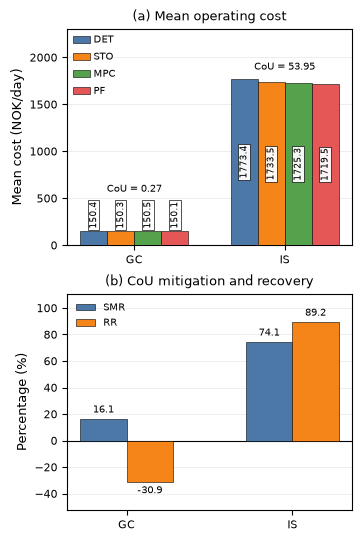

Saved summary CSV: forced_outage_results_v3\Fig2\Fig2_CoU_SMR_RR_GC_IS_Final_summary.csv
Saved PDF: forced_outage_results_v3\Fig2\Fig2_CoU_SMR_RR_GC_IS_Final.pdf
Saved PNG: forced_outage_results_v3\Fig2\Fig2_CoU_SMR_RR_GC_IS_Final.png


In [136]:
# =========================================================
# Fig.2 Clean IEEE Final (GC CoU unchanged, IS CoU moved up,
# value labels centered inside bars with white boxed border)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Load daily OOS results
# ---------------------------------------------------------

csv_file = Path("final_oos_det_sto_mpc_pf_daily.csv")
if not csv_file.exists():
    raise FileNotFoundError(f"Could not find: {csv_file.resolve()}")

df = pd.read_csv(csv_file)
df.columns = [c.strip() for c in df.columns]
df["mode"] = df["mode"].astype(str).str.upper().str.strip()

# ---------------------------------------------------------
# Build summary
# ---------------------------------------------------------

summary = (
    df.groupby("mode", as_index=False)
    .agg(
        DET=("det_cost_nok", "mean"),
        STO=("sto_cost_nok", "mean"),
        MPC=("mpc_cost_nok", "mean"),
        PF=("pf_cost_nok", "mean"),
    )
    .copy()
)

summary["CoU"] = summary["DET"] - summary["PF"]
gap = summary["DET"] - summary["PF"]

summary["SMR"] = np.where(
    gap.abs() > 1e-12,
    100.0 * (summary["DET"] - summary["STO"]) / gap,
    np.nan
)

summary["RR"] = np.where(
    gap.abs() > 1e-12,
    100.0 * (summary["DET"] - summary["MPC"]) / gap,
    np.nan
)

mode_order = ["GC", "IS"]
summary = summary[summary["mode"].isin(mode_order)].copy()
summary["mode"] = pd.Categorical(summary["mode"], categories=mode_order, ordered=True)
summary = summary.sort_values("mode").reset_index(drop=True)

print(summary.round(3))

# ---------------------------------------------------------
# Output folder
# ---------------------------------------------------------

outdir = Path("forced_outage_results_v3/Fig2")
outdir.mkdir(parents=True, exist_ok=True)

pdf_path = outdir / "Fig2_CoU_SMR_RR_GC_IS_Final.pdf"
png_path = outdir / "Fig2_CoU_SMR_RR_GC_IS_Final.png"
csv_path = outdir / "Fig2_CoU_SMR_RR_GC_IS_Final_summary.csv"

summary.to_csv(csv_path, index=False)

# ---------------------------------------------------------
# Helper for panel (b)
# ---------------------------------------------------------

def add_bar_labels(ax, bars, fmt="{:.1f}", fontsize=7, offset_frac=0.015):
    y0, y1 = ax.get_ylim()
    dy = (y1 - y0) * offset_frac
    for bar in bars:
        h = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        if np.isnan(h):
            continue
        if h >= 0:
            ax.text(
                x, h + dy, fmt.format(h),
                ha="center", va="bottom", fontsize=fontsize
            )
        else:
            ax.text(
                x, h - dy, fmt.format(h),
                ha="center", va="top", fontsize=fontsize
            )

# ---------------------------------------------------------
# Plot settings
# ---------------------------------------------------------

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

colors = {
    "DET": "#4C78A8",
    "STO": "#F58518",
    "MPC": "#54A24B",
    "PF":  "#E45756",
    "SMR": "#4C78A8",
    "RR":  "#F58518",
}

# IEEE single-column size
fig, axes = plt.subplots(
    2, 1,
    figsize=(3.5, 5.3),
    constrained_layout=True
)

# =========================================================
# (a) Mean operating cost
# =========================================================

ax = axes[0]

x = np.arange(len(summary))
width = 0.18
strategies = ["DET", "STO", "MPC", "PF"]

bar_groups = []
for i, s in enumerate(strategies):
    bars = ax.bar(
        x + (i - 1.5) * width,
        summary[s],
        width=width,
        label=s,
        color=colors[s],
        edgecolor="black",
        linewidth=0.4,
        zorder=3
    )
    bar_groups.append(bars)

ax.set_xticks(x)
ax.set_xticklabels(summary["mode"])
ax.set_ylabel("Mean cost (NOK/day)")
ax.set_title("(a) Mean operating cost")

# grid behind bars
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.25, linewidth=0.6, zorder=0)

cost_max = summary[strategies].to_numpy().max()
ax.set_ylim(0, cost_max * 1.30)

ax.legend(
    loc="upper left",
    ncol=1,
    frameon=False,
    fontsize=7,
    handlelength=1.7,
    handletextpad=0.4,
    labelspacing=0.7,
    borderaxespad=0.2
)

# ---------------------------------------------------------
# Value labels:
# GC = above bars
# IS = centered inside bars with white boxed border
# ---------------------------------------------------------
for bars in bar_groups:
    for j, bar in enumerate(bars):
        h = bar.get_height()
        x_text = bar.get_x() + bar.get_width() / 2

        mode_idx = j  # 0 = GC, 1 = IS

        if mode_idx == 0:  # GC -> labels above bars
            ax.text(
                x_text,
                h + 0.015 * cost_max,
                f"{h:.1f}",
                ha="center",
                va="bottom",
                rotation=90,
                fontsize=6.5,
                color="black",
                bbox=dict(
                    boxstyle="square,pad=0.12",
                    facecolor="white",
                    edgecolor="black",
                    linewidth=0.5,
                    alpha=0.95
                ),
                zorder=5
            )
        else:  # IS -> labels inside bars
            y_text = h / 2.0
            ax.text(
                x_text,
                y_text,
                f"{h:.1f}",
                ha="center",
                va="center",
                rotation=90,
                fontsize=6.5,
                color="black",
                bbox=dict(
                    boxstyle="square,pad=0.15",
                    facecolor="white",
                    edgecolor="black",
                    linewidth=0.5,
                    alpha=0.95
                ),
                zorder=5
            )
# ---------------------------------------------------------
# CoU annotations (independent GC and IS positioning)
# ---------------------------------------------------------

y0, y1 = ax.get_ylim()
span = y1 - y0

# Custom vertical offsets
GC_COU_OFFSET = 0.17   # GC er jonno
IS_COU_OFFSET = 0.03   # IS er jonno (aro niche/upore adjust kora jabe)

for i, row in summary.iterrows():

    group_max = max(
        row["DET"],
        row["STO"],
        row["MPC"],
        row["PF"]
    )

    if row["mode"] == "GC":

        y_text = group_max + GC_COU_OFFSET * span

    elif row["mode"] == "IS":

        y_text = group_max + IS_COU_OFFSET * span


    ax.text(
        x[i],
        y_text,
        f"CoU = {row['CoU']:.2f}",
        ha="center",
        va="bottom",
        fontsize=7.5,
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="none",
            alpha=0.85
        ),
        zorder=6
    )
# =========================================================
# (b) CoU mitigation and recovery
# =========================================================

ax2 = axes[1]

width2 = 0.28
bars_smr = ax2.bar(
    x - width2 / 2,
    summary["SMR"],
    width=width2,
    label="SMR",
    color=colors["SMR"],
    edgecolor="black",
    linewidth=0.4,
    zorder=3
)

bars_rr = ax2.bar(
    x + width2 / 2,
    summary["RR"],
    width=width2,
    label="RR",
    color=colors["RR"],
    edgecolor="black",
    linewidth=0.4,
    zorder=3
)

ax2.set_xticks(x)
ax2.set_xticklabels(summary["mode"])
ax2.set_ylabel("Percentage (%)")
ax2.set_title("(b) CoU mitigation and recovery")

ax2.set_axisbelow(True)
ax2.grid(axis="y", alpha=0.25, linewidth=0.6, zorder=0)
ax2.axhline(0, color="black", linewidth=0.8, zorder=2)
ax2.legend(loc="upper left", frameon=False)

vals = np.concatenate([summary["SMR"].values, summary["RR"].values, [0]])
vmin = np.nanmin(vals)
vmax = np.nanmax(vals)
vspan = max(vmax - vmin, 1.0)
ax2.set_ylim(vmin - 0.18 * vspan, vmax + 0.18 * vspan)

add_bar_labels(ax2, bars_smr, fmt="{:.1f}", fontsize=7, offset_frac=0.02)
add_bar_labels(ax2, bars_rr,  fmt="{:.1f}", fontsize=7, offset_frac=0.02)

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=600, bbox_inches="tight")

plt.show()

print("Saved summary CSV:", csv_path)
print("Saved PDF:", pdf_path)
print("Saved PNG:", png_path)

In [84]:
print(combined_daily.shape)

print(combined_daily.columns.tolist())

(1016, 61)
['date', 'mode', 'alpha', 'det_cost_nok', 'sto_cost_nok', 'cou_nok', 'sto_savings_vs_det_nok', 'sto_residual_gap_vs_pf_nok', 'det_critical_eens_kwh', 'sto_critical_eens_kwh', 'det_noncritical_eens_kwh', 'sto_noncritical_eens_kwh', 'det_critical_interrupted', 'sto_critical_interrupted', 'det_diesel_kwh', 'sto_diesel_kwh', 'det_curtailment_kwh', 'sto_curtailment_kwh', 'det_grid_import_kwh', 'sto_grid_import_kwh', 'det_grid_export_kwh', 'sto_grid_export_kwh', 'det_solve_time_s', 'sto_solve_time_s', 'sto_recourse_time_s', 'det_max_simultaneous_buy_sell_kw', 'sto_max_simultaneous_buy_sell_kw', 'pf_cost_nok', 'pf_critical_eens_kwh', 'pf_noncritical_eens_kwh', 'pf_critical_interrupted', 'pf_diesel_kwh', 'pf_curtailment_kwh', 'pf_grid_import_kwh', 'pf_grid_export_kwh', 'pf_solve_time_s', 'pf_max_simultaneous_buy_sell_kw', 'Hp', 'mpc_cost_nok', 'mpc_critical_eens_kwh', 'mpc_noncritical_eens_kwh', 'mpc_critical_interrupted', 'mpc_diesel_kwh', 'mpc_curtailment_kwh', 'mpc_grid_import_kw

(32, 40)


,source,mode,alpha,det_mean_cost_nok,sto_mean_cost_nok,mpc_mean_cost_nok,pf_mean_cost_nok,cou_nok,cou_ci95_low,cou_ci95_high,...,mpc_mean_noncritical_eens_kwh,det_critical_interruption_probability,sto_critical_interruption_probability,mpc_critical_interruption_probability,mean_det_solve_time_s,mean_sto_solve_time_s,mean_mpc_total_solve_time_s,mean_mpc_final_soc_abs_deviation,max_mpc_final_soc_abs_deviation,max_mpc_final_energy_abs_deviation_kwh
0,Combined,GC,0.05,150.124615,150.117072,150.185610,150.116163,8.451387e-03,-1.669402e-03,1.857218e-02,...,0.001801,0.0,0.0,0.0,0.160037,2.240020,1.494697,0.0,0.0,0.0
1,Load-only,GC,0.05,150.120495,150.116351,150.170446,150.116163,4.332226e-03,-6.830566e-04,9.347509e-03,...,0.002205,0.0,0.0,0.0,0.100666,1.964405,1.541473,0.0,0.0,0.0
2,PV-only,GC,0.05,150.116163,150.116163,150.118517,150.116163,7.458601e-15,-1.438150e-16,1.506102e-14,...,0.000000,0.0,0.0,0.0,0.103347,1.894200,1.556502,0.0,0.0,0.0
3,Wind-only,GC,0.05,150.117398,150.117393,150.157233,150.116163,1.234697e-03,-3.351794e-04,2.804573e-03,...,0.000000,0.0,0.0,0.0,0.098889,1.992922,1.524850,0.0,0.0,0.0
4,Combined,GC,0.10,150.223906,150.136899,150.258391,150.116163,1.077431e-01,3.720179e-02,1.782844e-01,...,0.000000,0.0,0.0,0.0,0.101486,2.423647,1.548427,0.0,0.0,0.0


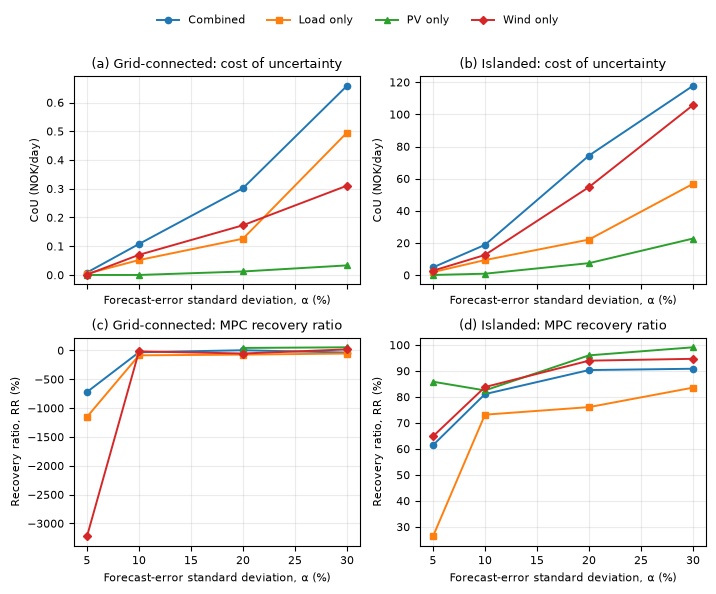

Saved PNG: figures_source_sensitivity\Fig_Source_Sensitivity_Full.png
Saved PDF: figures_source_sensitivity\Fig_Source_Sensitivity_Full.pdf


In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# Load summary file
# =========================================================
SRC_FILE = Path("source_sensitivity_det_sto_mpc_pf_summary.csv")
src_summary = pd.read_csv(SRC_FILE)

print(src_summary.shape)
display(src_summary.head())

# =========================================================
# Basic settings
# =========================================================
SOURCE_ORDER = ["Combined", "Load-only", "PV-only", "Wind-only"]
MODE_ORDER = ["GC", "IS"]

# optional prettier labels
SOURCE_LABELS = {
    "Combined": "Combined",
    "Load-only": "Load only",
    "PV-only": "PV only",
    "Wind-only": "Wind only",
}

# marker map
MARKERS = {
    "Combined": "o",
    "Load-only": "s",
    "PV-only": "^",
    "Wind-only": "D",
}

# =========================================================
# Clean / sort
# =========================================================
src_summary = src_summary.copy()
src_summary["alpha_percent"] = src_summary["alpha"] * 100

# =========================================================
# Create BIG figure
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.8), sharex=True)

panel_map = [
    ("GC", "cou_nok", "(a) Grid-connected: cost of uncertainty", axes[0, 0], "CoU (NOK/day)"),
    ("IS", "cou_nok", "(b) Islanded: cost of uncertainty", axes[0, 1], "CoU (NOK/day)"),
    ("GC", "rr_percent", "(c) Grid-connected: MPC recovery ratio", axes[1, 0], "Recovery ratio, RR (%)"),
    ("IS", "rr_percent", "(d) Islanded: MPC recovery ratio", axes[1, 1], "Recovery ratio, RR (%)"),
]

for mode, metric, title, ax, ylabel in panel_map:
    g = src_summary[src_summary["mode"] == mode].copy()

    for source in SOURCE_ORDER:
        x = g[g["source"] == source].sort_values("alpha")
        if len(x) == 0:
            continue

        ax.plot(
            x["alpha_percent"],
            x[metric],
            marker=MARKERS[source],
            linewidth=1.4,
            markersize=4.5,
            label=SOURCE_LABELS[source],
        )

    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Forecast-error standard deviation, α (%)", fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.grid(alpha=0.25)
    ax.tick_params(axis="both", labelsize=8)

# one shared legend at top
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    fontsize=8,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# =========================================================
# Save
# =========================================================
OUT_DIR = Path("figures_source_sensitivity")
OUT_DIR.mkdir(exist_ok=True)

png_file = OUT_DIR / "Fig_Source_Sensitivity_Full.png"
pdf_file = OUT_DIR / "Fig_Source_Sensitivity_Full.pdf"

fig.savefig(png_file, dpi=600, bbox_inches="tight")
fig.savefig(pdf_file, bbox_inches="tight")
plt.show()

print("Saved PNG:", png_file)
print("Saved PDF:", pdf_file)

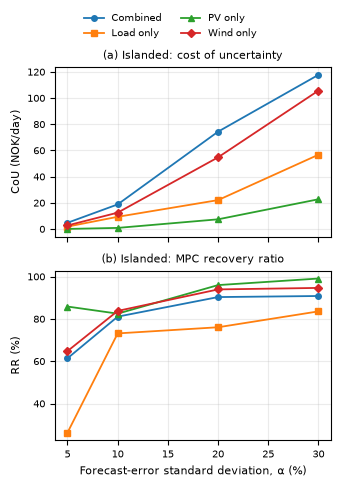

Saved PNG: figures_source_sensitivity\Fig_Source_Sensitivity_Compact_IS.png
Saved PDF: figures_source_sensitivity\Fig_Source_Sensitivity_Compact_IS.pdf


In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# Load summary file
# =========================================================
SRC_FILE = Path("source_sensitivity_det_sto_mpc_pf_summary.csv")
src_summary = pd.read_csv(SRC_FILE)

# =========================================================
# Basic settings
# =========================================================
SOURCE_ORDER = ["Combined", "Load-only", "PV-only", "Wind-only"]

SOURCE_LABELS = {
    "Combined": "Combined",
    "Load-only": "Load only",
    "PV-only": "PV only",
    "Wind-only": "Wind only",
}

MARKERS = {
    "Combined": "o",
    "Load-only": "s",
    "PV-only": "^",
    "Wind-only": "D",
}

src_summary = src_summary.copy()
src_summary["alpha_percent"] = src_summary["alpha"] * 100

is_data = src_summary[src_summary["mode"] == "IS"].copy()

# =========================================================
# Compact figure: single-column friendly
# =========================================================
fig, axes = plt.subplots(2, 1, figsize=(3.45, 4.8), sharex=True)

# -------------------------
# (a) CoU
# -------------------------
ax = axes[0]
for source in SOURCE_ORDER:
    x = is_data[is_data["source"] == source].sort_values("alpha")
    if len(x) == 0:
        continue

    ax.plot(
        x["alpha_percent"],
        x["cou_nok"],
        marker=MARKERS[source],
        linewidth=1.3,
        markersize=4.0,
        label=SOURCE_LABELS[source],
    )

ax.set_title("(a) Islanded: cost of uncertainty", fontsize=8)
ax.set_ylabel("CoU (NOK/day)", fontsize=8)
ax.grid(alpha=0.25)
ax.tick_params(axis="both", labelsize=7)

# -------------------------
# (b) RR
# -------------------------
ax = axes[1]
for source in SOURCE_ORDER:
    x = is_data[is_data["source"] == source].sort_values("alpha")
    if len(x) == 0:
        continue

    ax.plot(
        x["alpha_percent"],
        x["rr_percent"],
        marker=MARKERS[source],
        linewidth=1.3,
        markersize=4.0,
        label=SOURCE_LABELS[source],
    )

ax.set_title("(b) Islanded: MPC recovery ratio", fontsize=8)
ax.set_xlabel("Forecast-error standard deviation, α (%)", fontsize=8)
ax.set_ylabel("RR (%)", fontsize=8)
ax.grid(alpha=0.25)
ax.tick_params(axis="both", labelsize=7)

# compact legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=7,
    bbox_to_anchor=(0.5, 1.01)
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

# =========================================================
# Save
# =========================================================
OUT_DIR = Path("figures_source_sensitivity")
OUT_DIR.mkdir(exist_ok=True)

png_file = OUT_DIR / "Fig_Source_Sensitivity_Compact_IS.png"
pdf_file = OUT_DIR / "Fig_Source_Sensitivity_Compact_IS.pdf"

fig.savefig(png_file, dpi=600, bbox_inches="tight")
fig.savefig(pdf_file, bbox_inches="tight")
plt.show()

print("Saved PNG:", png_file)
print("Saved PDF:", pdf_file)

In [27]:
print(combined_daily.shape)
print(combined_daily.columns.tolist())

(1016, 61)
['date', 'mode', 'alpha', 'det_cost_nok', 'sto_cost_nok', 'cou_nok', 'sto_savings_vs_det_nok', 'sto_residual_gap_vs_pf_nok', 'det_critical_eens_kwh', 'sto_critical_eens_kwh', 'det_noncritical_eens_kwh', 'sto_noncritical_eens_kwh', 'det_critical_interrupted', 'sto_critical_interrupted', 'det_diesel_kwh', 'sto_diesel_kwh', 'det_curtailment_kwh', 'sto_curtailment_kwh', 'det_grid_import_kwh', 'sto_grid_import_kwh', 'det_grid_export_kwh', 'sto_grid_export_kwh', 'det_solve_time_s', 'sto_solve_time_s', 'sto_recourse_time_s', 'det_max_simultaneous_buy_sell_kw', 'sto_max_simultaneous_buy_sell_kw', 'pf_cost_nok', 'pf_critical_eens_kwh', 'pf_noncritical_eens_kwh', 'pf_critical_interrupted', 'pf_diesel_kwh', 'pf_curtailment_kwh', 'pf_grid_import_kwh', 'pf_grid_export_kwh', 'pf_solve_time_s', 'pf_max_simultaneous_buy_sell_kw', 'Hp', 'mpc_cost_nok', 'mpc_critical_eens_kwh', 'mpc_noncritical_eens_kwh', 'mpc_critical_interrupted', 'mpc_diesel_kwh', 'mpc_curtailment_kwh', 'mpc_grid_import_kw

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ======================================
# Source sensitivity dataframe
# ======================================

src_df = combined_daily.copy()


# Cost of uncertainty
src_df["CoU_nok"] = (
    src_df["det_cost_nok"]
    -
    src_df["pf_cost_nok"]
)


# Recovery ratio
den = (
    src_df["det_cost_nok"]
    -
    src_df["pf_cost_nok"]
)

src_df["RR_percent"] = np.where(
    den > 1e-6,
    (
        (src_df["det_cost_nok"]
         -
         src_df["mpc_cost_nok"])
        /
        den
    )*100,
    np.nan
)


print(src_df.shape)

display(
    src_df.head()
)

(1016, 63)


,date,mode,alpha,det_cost_nok,sto_cost_nok,cou_nok,sto_savings_vs_det_nok,sto_residual_gap_vs_pf_nok,det_critical_eens_kwh,sto_critical_eens_kwh,...,mpc_final_soc_abs_deviation,mpc_final_energy_deviation_kwh,mpc_final_energy_abs_deviation_kwh,mpc_max_anchor_terminal_soc_abs_deviation,mpc_max_anchor_terminal_energy_abs_deviation_kwh,mpc_max_balance_residual_kw,mpc_savings_vs_det_nok,mpc_residual_gap_vs_pf_nok,CoU_nok,RR_percent
0,2020-11-01,GC,0.05,-27.918323,-27.918323,1.207923e-13,0.0,1.207923e-13,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.278977e-13,-7.105427e-15,1.207923e-13,NaN
1,2020-11-01,IS,0.05,221.200920,221.200920,0.000000e+00,0.0,0.000000e+00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-2.842171e-14,2.842171e-14,0.000000e+00,NaN
2,2020-11-01,GC,0.10,-27.918323,-27.918323,1.207923e-13,0.0,1.207923e-13,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.278977e-13,-7.105427e-15,1.207923e-13,NaN
3,2020-11-01,IS,0.10,221.200920,221.200920,0.000000e+00,0.0,0.000000e+00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-2.842171e-14,2.842171e-14,0.000000e+00,NaN
4,2020-11-01,GC,0.20,-27.918323,-27.918323,1.207923e-13,0.0,1.207923e-13,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.278977e-13,-7.105427e-15,1.207923e-13,NaN


In [31]:
src_df.columns.tolist()

['date',
 'mode',
 'alpha',
 'det_cost_nok',
 'sto_cost_nok',
 'cou_nok',
 'sto_savings_vs_det_nok',
 'sto_residual_gap_vs_pf_nok',
 'det_critical_eens_kwh',
 'sto_critical_eens_kwh',
 'det_noncritical_eens_kwh',
 'sto_noncritical_eens_kwh',
 'det_critical_interrupted',
 'sto_critical_interrupted',
 'det_diesel_kwh',
 'sto_diesel_kwh',
 'det_curtailment_kwh',
 'sto_curtailment_kwh',
 'det_grid_import_kwh',
 'sto_grid_import_kwh',
 'det_grid_export_kwh',
 'sto_grid_export_kwh',
 'det_solve_time_s',
 'sto_solve_time_s',
 'sto_recourse_time_s',
 'det_max_simultaneous_buy_sell_kw',
 'sto_max_simultaneous_buy_sell_kw',
 'pf_cost_nok',
 'pf_critical_eens_kwh',
 'pf_noncritical_eens_kwh',
 'pf_critical_interrupted',
 'pf_diesel_kwh',
 'pf_curtailment_kwh',
 'pf_grid_import_kwh',
 'pf_grid_export_kwh',
 'pf_solve_time_s',
 'pf_max_simultaneous_buy_sell_kw',
 'Hp',
 'mpc_cost_nok',
 'mpc_critical_eens_kwh',
 'mpc_noncritical_eens_kwh',
 'mpc_critical_interrupted',
 'mpc_diesel_kwh',
 'mpc_curta

In [35]:
from pathlib import Path

ROOT = Path(
    r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation"
)

for f in ROOT.rglob("*.csv"):
    name = f.name.lower()
    if any(x in name for x in [
        "source",
        "sensitivity",
        "uncertainty",
        "pv",
        "wind",
        "load"
    ]):
        print(f)

E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\source_sensitivity_det_sto_mpc_pf_daily.csv
E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\source_sensitivity_det_sto_mpc_pf_summary.csv
E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_MPC_OOS\mpc_horizon_sensitivity_checkpoint.csv
E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_MPC_OOS\mpc_horizon_sensitivity_SOFT_TERMINAL_checkpoint.csv
E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_MPC_OOS\mpc_horizon_sensitivity_SOFT_TERMINAL_development.csv
E:\AIUB Ref. Book & Class Materi

In [37]:
from pathlib import Path
import pandas as pd

SOURCE_FILE = Path(
r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\source_sensitivity_det_sto_mpc_pf_daily.csv"
)

source_daily = pd.read_csv(SOURCE_FILE)

print(source_daily.shape)
print(source_daily.columns.tolist())

display(source_daily.head())

(3048, 54)
['date', 'source', 'mode', 'alpha', 'det_cost_nok', 'sto_cost_nok', 'pf_cost_nok', 'det_critical_eens_kwh', 'sto_critical_eens_kwh', 'pf_critical_eens_kwh', 'det_noncritical_eens_kwh', 'sto_noncritical_eens_kwh', 'pf_noncritical_eens_kwh', 'det_critical_interrupted', 'sto_critical_interrupted', 'pf_critical_interrupted', 'det_diesel_kwh', 'sto_diesel_kwh', 'det_curtailment_kwh', 'sto_curtailment_kwh', 'det_grid_import_kwh', 'sto_grid_import_kwh', 'det_grid_export_kwh', 'sto_grid_export_kwh', 'det_solve_time_s', 'sto_solve_time_s', 'sto_recourse_time_s', 'det_max_simultaneous_buy_sell_kw', 'sto_max_simultaneous_buy_sell_kw', 'Hp', 'mpc_cost_nok', 'mpc_critical_eens_kwh', 'mpc_noncritical_eens_kwh', 'mpc_critical_interrupted', 'mpc_diesel_kwh', 'mpc_curtailment_kwh', 'mpc_grid_import_kwh', 'mpc_grid_export_kwh', 'mpc_total_solve_time_s', 'mpc_total_local_solve_time_s', 'mpc_total_anchor_solve_time_s', 'mpc_final_soc', 'mpc_final_soc_deviation', 'mpc_final_soc_abs_deviation', '

,date,source,mode,alpha,det_cost_nok,sto_cost_nok,pf_cost_nok,det_critical_eens_kwh,sto_critical_eens_kwh,pf_critical_eens_kwh,...,mpc_final_energy_deviation_kwh,mpc_final_energy_abs_deviation_kwh,mpc_max_anchor_terminal_soc_abs_deviation,mpc_max_anchor_terminal_energy_abs_deviation_kwh,mpc_max_balance_residual_kw,cou_nok,sto_savings_vs_det_nok,mpc_savings_vs_det_nok,sto_residual_gap_vs_pf_nok,mpc_residual_gap_vs_pf_nok
0,2020-11-01,Load-only,GC,0.05,-27.918323,-27.918323,-27.918323,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.207923e-13,0.0,1.278977e-13,1.207923e-13,-7.105427e-15
1,2020-11-01,Load-only,IS,0.05,221.200920,221.200920,221.200920,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,-2.842171e-14,0.000000e+00,2.842171e-14
2,2020-11-01,Load-only,GC,0.10,-27.918323,-27.918323,-27.918323,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.207923e-13,0.0,1.278977e-13,1.207923e-13,-7.105427e-15
3,2020-11-01,Load-only,IS,0.10,221.200920,221.200920,221.200920,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,-2.842171e-14,0.000000e+00,2.842171e-14
4,2020-11-01,Load-only,GC,0.20,-27.918323,-27.918323,-27.918323,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.207923e-13,0.0,1.278977e-13,1.207923e-13,-7.105427e-15


,source,mode,alpha,det_mean_cost_nok,sto_mean_cost_nok,mpc_mean_cost_nok,pf_mean_cost_nok,det_mean_noncritical_eens_kwh,sto_mean_noncritical_eens_kwh,mpc_mean_noncritical_eens_kwh,cou_nok,smr_percent,rr_percent
0,Load-only,GC,0.05,150.120495,150.116351,150.170446,150.116163,0.000000,0.000000,0.002205,4.332226e-03,95.656764,-1153.000691
1,Load-only,GC,0.10,150.168053,150.118154,150.212363,150.116163,0.000000,0.000000,0.000000,5.189033e-02,96.163351,-85.390591
2,Load-only,GC,0.20,150.242388,150.184090,150.334536,150.116163,0.000000,0.000000,0.000000,1.262253e-01,46.185982,-73.002739
3,Load-only,GC,0.30,150.611576,150.724660,150.879156,150.116163,0.000000,0.000000,0.003651,4.954131e-01,-22.826097,-54.011502
4,PV-only,GC,0.05,150.116163,150.116163,150.118517,150.116163,0.000000,0.000000,0.000000,2.842171e-14,NaN,NaN
5,PV-only,GC,0.10,150.116163,150.116247,150.118213,150.116163,0.000000,0.000000,0.000000,2.842171e-14,NaN,NaN
6,PV-only,GC,0.20,150.128282,150.129126,150.123065,150.116163,0.000000,0.000000,0.000000,1.211882e-02,-6.961210,43.048429
7,PV-only,GC,0.30,150.149487,150.137974,150.131535,150.116163,0.000000,0.000000,0.000000,3.332393e-02,34.548509,53.871140
8,Wind-only,GC,0.05,150.117398,150.117393,150.157233,150.116163,0.000000,0.000000,0.000000,1.234697e-03,0.426947,-3226.312380
9,Wind-only,GC,0.10,150.186160,150.136219,150.198142,150.116163,0.000000,0.000000,0.000000,6.999722e-02,71.347593,-17.117697


Saved summary: forced_outage_results_v3\Fig5\Fig5_source_sensitivity_summary.csv


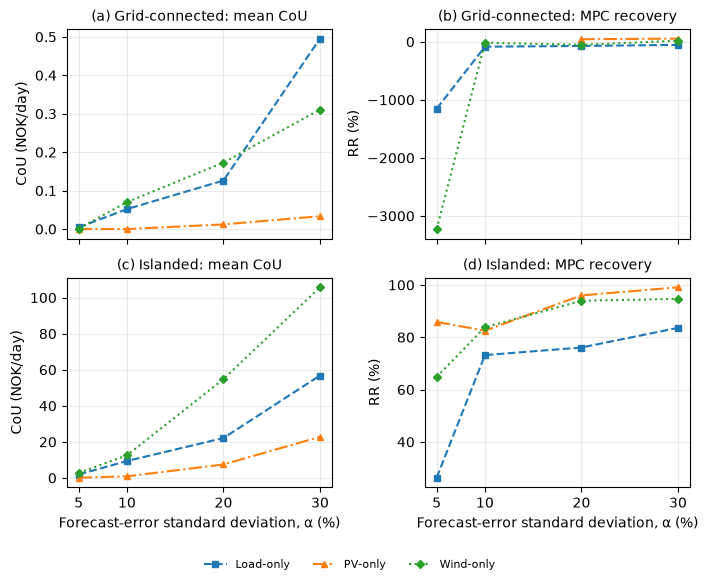

Saved PDF: forced_outage_results_v3\Fig5\Fig5_Source_Sensitivity_Big.pdf
Saved PNG: forced_outage_results_v3\Fig5\Fig5_Source_Sensitivity_Big.png


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# INPUT
# =========================
# source_daily already loaded from:
# source_sensitivity_det_sto_mpc_pf_daily.csv

df = source_daily.copy()

# output folder
FIG_DIR = Path("forced_outage_results_v3/Fig5")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# preferred order
SOURCE_ORDER = ["Combined", "Load-only", "PV-only", "Wind-only"]
MODE_ORDER = ["GC", "IS"]
ALPHA_ORDER = [0.05, 0.10, 0.20, 0.30]

# =========================
# BUILD SUMMARY
# =========================
summary = (
    df.groupby(["source", "mode", "alpha"], as_index=False)
      .agg(
          det_mean_cost_nok=("det_cost_nok", "mean"),
          sto_mean_cost_nok=("sto_cost_nok", "mean"),
          mpc_mean_cost_nok=("mpc_cost_nok", "mean"),
          pf_mean_cost_nok=("pf_cost_nok", "mean"),
          det_mean_noncritical_eens_kwh=("det_noncritical_eens_kwh", "mean"),
          sto_mean_noncritical_eens_kwh=("sto_noncritical_eens_kwh", "mean"),
          mpc_mean_noncritical_eens_kwh=("mpc_noncritical_eens_kwh", "mean"),
      )
)

summary["cou_nok"] = summary["det_mean_cost_nok"] - summary["pf_mean_cost_nok"]

den = summary["cou_nok"].copy()

summary["smr_percent"] = np.where(
    den > 1e-9,
    100 * (summary["det_mean_cost_nok"] - summary["sto_mean_cost_nok"]) / den,
    np.nan
)

summary["rr_percent"] = np.where(
    den > 1e-9,
    100 * (summary["det_mean_cost_nok"] - summary["mpc_mean_cost_nok"]) / den,
    np.nan
)

summary["source"] = pd.Categorical(summary["source"], categories=SOURCE_ORDER, ordered=True)
summary["mode"] = pd.Categorical(summary["mode"], categories=MODE_ORDER, ordered=True)
summary = summary.sort_values(["mode", "source", "alpha"]).reset_index(drop=True)

display(summary)

summary_csv = FIG_DIR / "Fig5_source_sensitivity_summary.csv"
summary.to_csv(summary_csv, index=False)
print("Saved summary:", summary_csv)

# =========================
# PLOT SETTINGS
# =========================
source_styles = {
    "Combined":   {"marker": "o", "linestyle": "-"},
    "Load-only":  {"marker": "s", "linestyle": "--"},
    "PV-only":    {"marker": "^", "linestyle": "-."},
    "Wind-only":  {"marker": "D", "linestyle": ":"},
}

alpha_percent = np.array(ALPHA_ORDER) * 100

fig, axes = plt.subplots(2, 2, figsize=(7.1, 5.8), sharex=True)

# ---------- (a) GC CoU ----------
ax = axes[0, 0]
for src in SOURCE_ORDER:
    sub = summary[(summary["mode"] == "GC") & (summary["source"] == src)].sort_values("alpha")
    if len(sub) == 0:
        continue
    style = source_styles[src]
    ax.plot(
        sub["alpha"] * 100,
        sub["cou_nok"],
        label=src,
        marker=style["marker"],
        linestyle=style["linestyle"],
        linewidth=1.5,
        markersize=4.5,
    )
ax.set_title("(a) Grid-connected: mean CoU", fontsize=10)
ax.set_ylabel("CoU (NOK/day)")
ax.grid(True, alpha=0.25)

# ---------- (b) GC RR ----------
ax = axes[0, 1]
for src in SOURCE_ORDER:
    sub = summary[(summary["mode"] == "GC") & (summary["source"] == src)].sort_values("alpha")
    if len(sub) == 0:
        continue
    style = source_styles[src]
    ax.plot(
        sub["alpha"] * 100,
        sub["rr_percent"],
        label=src,
        marker=style["marker"],
        linestyle=style["linestyle"],
        linewidth=1.5,
        markersize=4.5,
    )
ax.set_title("(b) Grid-connected: MPC recovery", fontsize=10)
ax.set_ylabel("RR (%)")
ax.grid(True, alpha=0.25)

# ---------- (c) IS CoU ----------
ax = axes[1, 0]
for src in SOURCE_ORDER:
    sub = summary[(summary["mode"] == "IS") & (summary["source"] == src)].sort_values("alpha")
    if len(sub) == 0:
        continue
    style = source_styles[src]
    ax.plot(
        sub["alpha"] * 100,
        sub["cou_nok"],
        label=src,
        marker=style["marker"],
        linestyle=style["linestyle"],
        linewidth=1.5,
        markersize=4.5,
    )
ax.set_title("(c) Islanded: mean CoU", fontsize=10)
ax.set_xlabel("Forecast-error standard deviation, α (%)")
ax.set_ylabel("CoU (NOK/day)")
ax.grid(True, alpha=0.25)

# ---------- (d) IS RR ----------
ax = axes[1, 1]
for src in SOURCE_ORDER:
    sub = summary[(summary["mode"] == "IS") & (summary["source"] == src)].sort_values("alpha")
    if len(sub) == 0:
        continue
    style = source_styles[src]
    ax.plot(
        sub["alpha"] * 100,
        sub["rr_percent"],
        label=src,
        marker=style["marker"],
        linestyle=style["linestyle"],
        linewidth=1.5,
        markersize=4.5,
    )
ax.set_title("(d) Islanded: MPC recovery", fontsize=10)
ax.set_xlabel("Forecast-error standard deviation, α (%)")
ax.set_ylabel("RR (%)")
ax.grid(True, alpha=0.25)

# x ticks for all panels
for ax in axes.flat:
    ax.set_xticks(alpha_percent)

# one shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=8,
    bbox_to_anchor=(0.5, -0.01)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

pdf_path = FIG_DIR / "Fig5_Source_Sensitivity_Big.pdf"
png_path = FIG_DIR / "Fig5_Source_Sensitivity_Big.png"

plt.savefig(pdf_path, dpi=300, bbox_inches="tight")
plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved PDF:", pdf_path)
print("Saved PNG:", png_path)

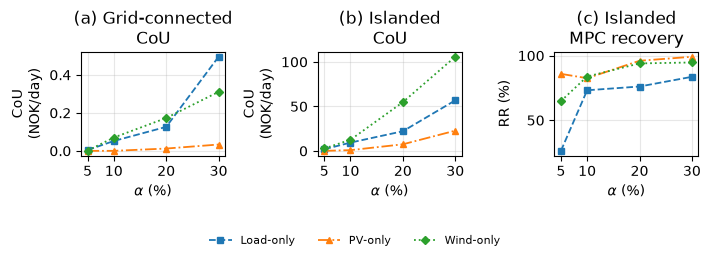

Saved: forced_outage_results_v3\Fig5\Fig5_Source_Sensitivity_IEEE.pdf
Saved: forced_outage_results_v3\Fig5\Fig5_Source_Sensitivity_IEEE.png


In [41]:
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("forced_outage_results_v3/Fig5")
FIG_DIR.mkdir(parents=True, exist_ok=True)

sources = ["Load-only", "PV-only", "Wind-only"]

styles = {
    "Load-only": {"marker":"s", "linestyle":"--"},
    "PV-only": {"marker":"^", "linestyle":"-."},
    "Wind-only": {"marker":"D", "linestyle":":"}
}


fig, axes = plt.subplots(
    1, 3,
    figsize=(7.2, 2.5),
    sharex=True
)


# =====================
# (a) GC CoU
# =====================
ax = axes[0]

for src in sources:
    sub = summary[
        (summary["source"] == src) &
        (summary["mode"] == "GC")
    ].sort_values("alpha")

    ax.plot(
        sub["alpha"]*100,
        sub["cou_nok"],
        label=src,
        marker=styles[src]["marker"],
        linestyle=styles[src]["linestyle"],
        linewidth=1.3,
        markersize=4
    )

ax.set_title("(a) Grid-connected\nCoU")
ax.set_ylabel("CoU\n(NOK/day)")
ax.grid(True, alpha=0.3)



# =====================
# (b) IS CoU
# =====================
ax = axes[1]

for src in sources:
    sub = summary[
        (summary["source"] == src) &
        (summary["mode"] == "IS")
    ].sort_values("alpha")

    ax.plot(
        sub["alpha"]*100,
        sub["cou_nok"],
        marker=styles[src]["marker"],
        linestyle=styles[src]["linestyle"],
        linewidth=1.3,
        markersize=4
    )

ax.set_title("(b) Islanded\nCoU")
ax.set_ylabel("CoU\n(NOK/day)")
ax.grid(True, alpha=0.3)



# =====================
# (c) IS RR
# =====================
ax = axes[2]

for src in sources:
    sub = summary[
        (summary["source"] == src) &
        (summary["mode"] == "IS")
    ].sort_values("alpha")

    ax.plot(
        sub["alpha"]*100,
        sub["rr_percent"],
        marker=styles[src]["marker"],
        linestyle=styles[src]["linestyle"],
        linewidth=1.3,
        markersize=4
    )

ax.set_title("(c) Islanded\nMPC recovery")
ax.set_ylabel("RR (%)")
ax.grid(True, alpha=0.3)



for ax in axes:
    ax.set_xlabel(r"$\alpha$ (%)")
    ax.set_xticks([5,10,20,30])


handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=8,
    bbox_to_anchor=(0.5,-0.05)
)


plt.tight_layout(rect=[0,0.12,1,1])


pdf = FIG_DIR / "Fig5_Source_Sensitivity_IEEE.pdf"
png = FIG_DIR / "Fig5_Source_Sensitivity_IEEE.png"

plt.savefig(pdf, dpi=300, bbox_inches="tight")
plt.savefig(png, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", pdf)
print("Saved:", png)

,mode,alpha,det_mean_cost_nok,mpc_mean_cost_nok,pf_mean_cost_nok,CoU_nok,RR_percent
0,GC,0.05,150.124615,150.185610,150.116163,0.008451,-721.717595
1,GC,0.10,150.223906,150.258391,150.116163,0.107743,-32.006509
2,GC,0.20,150.418153,150.409431,150.116163,0.301990,2.888344
3,GC,0.30,150.774321,151.020028,150.116163,0.658158,-37.332441
4,IS,0.05,1724.309920,1721.354490,1719.497658,4.812263,61.414573
5,IS,0.10,1738.334236,1723.058251,1719.497658,18.836578,81.097454
6,IS,0.20,1793.875464,1726.677692,1719.497658,74.377807,90.346537
7,IS,0.30,1837.266813,1730.271247,1719.497658,117.769155,90.851943


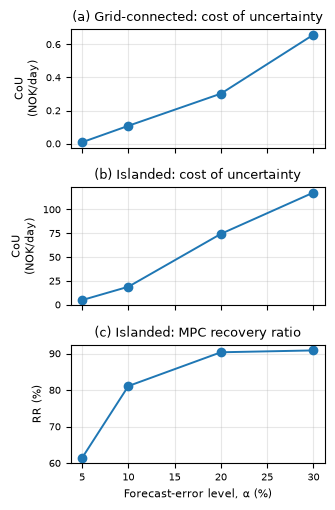

Saved PDF: forced_outage_results_v3\Fig4\Fig4_CoU_RR.pdf
Saved PNG: forced_outage_results_v3\Fig4\Fig4_CoU_RR.png


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==========================================
# 1) Aggregate correctly from combined_daily
# ==========================================

fig_data = (
    combined_daily
    .groupby(["mode", "alpha"], as_index=False)
    .agg(
        det_mean_cost_nok=("det_cost_nok", "mean"),
        sto_mean_cost_nok=("sto_cost_nok", "mean"),
        mpc_mean_cost_nok=("mpc_cost_nok", "mean"),
        pf_mean_cost_nok=("pf_cost_nok", "mean"),
    )
)

# CoU from mean costs
fig_data["CoU_nok"] = (
    fig_data["det_mean_cost_nok"]
    - fig_data["pf_mean_cost_nok"]
)

# RR from mean costs (NOT mean of daily RR)
fig_data["RR_percent"] = np.where(
    fig_data["CoU_nok"] > 1e-6,
    100
    * (
        fig_data["det_mean_cost_nok"]
        - fig_data["mpc_mean_cost_nok"]
    )
    / fig_data["CoU_nok"],
    np.nan
)

display(
    fig_data[
        [
            "mode",
            "alpha",
            "det_mean_cost_nok",
            "mpc_mean_cost_nok",
            "pf_mean_cost_nok",
            "CoU_nok",
            "RR_percent",
        ]
    ]
)

# ==========================================
# 2) Split data
# ==========================================

gc = fig_data[fig_data["mode"] == "GC"].sort_values("alpha")
is_data = fig_data[fig_data["mode"] == "IS"].sort_values("alpha")

# ==========================================
# 3) Plot IEEE single-column style
# ==========================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(3.45, 5.2),
    sharex=True
)

# (a) GC CoU
axes[0].plot(
    gc["alpha"] * 100,
    gc["CoU_nok"],
    marker="o",
    linewidth=1.4
)
axes[0].set_title("(a) Grid-connected: cost of uncertainty", fontsize=9)
axes[0].set_ylabel("CoU\n(NOK/day)", fontsize=8)
axes[0].grid(alpha=0.3)

# (b) IS CoU
axes[1].plot(
    is_data["alpha"] * 100,
    is_data["CoU_nok"],
    marker="o",
    linewidth=1.4
)
axes[1].set_title("(b) Islanded: cost of uncertainty", fontsize=9)
axes[1].set_ylabel("CoU\n(NOK/day)", fontsize=8)
axes[1].grid(alpha=0.3)

# (c) IS RR
axes[2].plot(
    is_data["alpha"] * 100,
    is_data["RR_percent"],
    marker="o",
    linewidth=1.4
)
axes[2].set_title("(c) Islanded: MPC recovery ratio", fontsize=9)
axes[2].set_ylabel("RR (%)", fontsize=8)
axes[2].set_xlabel("Forecast-error level, α (%)", fontsize=8)
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.tick_params(labelsize=7)

plt.tight_layout()

# ==========================================
# 4) Save
# ==========================================

OUT_DIR = Path("forced_outage_results_v3/Fig4")
OUT_DIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUT_DIR / "Fig4_CoU_RR.pdf"
png_path = OUT_DIR / "Fig4_CoU_RR.png"

plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, dpi=600, bbox_inches="tight")
plt.show()

print("Saved PDF:", pdf_path)
print("Saved PNG:", png_path)

In [42]:
forced_outage_daily.shape

(127, 104)

In [43]:
stress_hourly_summary.head()

NameError: name 'stress_hourly_summary' is not defined

In [44]:
[x for x in globals().keys() if "hour" in x.lower() or "stress" in x.lower()]

['OUTAGE_HOURS',
 'extract_segment_hourly',
 'extract_single_hourly',
 'hourly_metrics',
 'realized_first_hour_cost']

In [45]:
forced_outage_daily.columns.tolist()

['date',
 'alpha',
 'outage_start_h',
 'outage_end_h',
 'det_cost_nok',
 'det_critical_eens_kwh',
 'det_noncritical_eens_kwh',
 'det_outage_critical_eens_kwh',
 'det_outage_noncritical_eens_kwh',
 'det_critical_interrupted',
 'det_outage_critical_interrupted',
 'det_diesel_energy_kwh',
 'det_battery_throughput_kwh',
 'det_curtailment_kwh',
 'det_grid_import_kwh',
 'det_grid_export_kwh',
 'det_min_soc',
 'det_soc_at_outage',
 'det_terminal_soc',
 'det_final_soc_abs_deviation',
 'det_final_energy_abs_deviation_kwh',
 'det_max_outage_grid_exchange_kw',
 'det_max_simultaneous_buy_sell_kw',
 'det_max_balance_residual_kw',
 'det_preoutage_soc_anchor',
 'det_emergency_dg_commitment_changes',
 'det_emergency_battery_mode_changes',
 'det_emergency_plan_solve_time_s',
 'sto_cost_nok',
 'sto_critical_eens_kwh',
 'sto_noncritical_eens_kwh',
 'sto_outage_critical_eens_kwh',
 'sto_outage_noncritical_eens_kwh',
 'sto_critical_interrupted',
 'sto_outage_critical_interrupted',
 'sto_diesel_energy_kwh',

In [46]:
print(representative_hourly_summary.shape)
print(representative_hourly_summary.columns.tolist())

NameError: name 'representative_hourly_summary' is not defined

In [47]:
print(dispatch_audit.shape)
print(dispatch_audit.columns.tolist())

(32, 15)
['strategy', 'hour', 'grid_available', 'pv', 'wind', 'dg', 'charge', 'discharge', 'buy', 'sell', 'shed_crit', 'shed_ncrit', 'soc_start', 'soc_end', 'balance_residual_kw']


In [48]:
import pandas as pd
from pathlib import Path

# folder where the hourly csv files were saved
OUT_DIR = Path(r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3")

REP_DATE = "2020-11-19"
STRESS_DATE = "2021-02-02"

def build_hourly_summary(date_string, label, out_dir=OUT_DIR):
    data = {}
    for s in ["det", "sto", "mpc", "pf"]:
        f = out_dir / f"forced_outage_{label}_{date_string}_{s}_hourly.csv"
        data[s.upper()] = pd.read_csv(f)

    rows = []

    for strategy, df in data.items():
        cols = [
            "hour",
            "grid_available",
            "soc_start",
            "soc_end",
            "dg",
            "charge",
            "discharge",
            "buy",
            "sell",
            "shed_crit",
            "shed_ncrit",
        ]

        # phase column optional
        if "phase" in df.columns:
            cols.insert(1, "phase")

        x = df[df["hour"].between(16, 23)][cols].copy()
        x["strategy"] = strategy
        rows.append(x)

    summary = pd.concat(rows, ignore_index=True)

    # reorder
    ordered = ["strategy", "hour"]
    if "phase" in summary.columns:
        ordered.append("phase")

    ordered += [
        "grid_available",
        "soc_start",
        "soc_end",
        "dg",
        "charge",
        "discharge",
        "buy",
        "sell",
        "shed_crit",
        "shed_ncrit",
    ]

    summary = summary[ordered]

    out_file = out_dir / f"Table_{label.capitalize()}_Outage_Hourly.csv"
    summary.to_csv(out_file, index=False)

    print(f"{label.capitalize()} summary saved:", out_file)
    return summary

representative_hourly_summary = build_hourly_summary(REP_DATE, "representative")
stress_hourly_summary = build_hourly_summary(STRESS_DATE, "stress")

display(representative_hourly_summary)
display(stress_hourly_summary)

Representative summary saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\Table_Representative_Outage_Hourly.csv
Stress summary saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\Table_Stress_Outage_Hourly.csv


,strategy,hour,phase,grid_available,soc_start,soc_end,dg,charge,discharge,buy,sell,shed_crit,shed_ncrit
0,DET,16,pre_outage,1,0.500000,0.500000,0.000000e+00,0.000000,0.000000e+00,23.430378,0.0,0.0,0.0
1,DET,17,pre_outage,1,0.500000,0.500000,0.000000e+00,0.000000,0.000000e+00,24.251340,0.0,0.0,0.0
2,DET,18,post_outage_emergency,0,0.500000,0.441030,0.000000e+00,0.000000,2.948517e+01,0.000000,0.0,0.0,0.0
3,DET,19,post_outage_emergency,0,0.441030,0.378200,0.000000e+00,0.000000,3.141475e+01,0.000000,0.0,0.0,0.0
4,DET,20,post_outage_emergency,0,0.378200,0.319249,0.000000e+00,0.000000,2.947574e+01,0.000000,0.0,0.0,0.0
5,DET,21,post_outage_emergency,0,0.319249,0.266938,0.000000e+00,0.000000,2.615532e+01,0.000000,0.0,0.0,0.0
6,DET,22,post_outage_emergency,1,0.266938,0.328404,0.000000e+00,36.156289,0.000000e+00,59.411895,0.0,0.0,0.0
7,DET,23,post_outage_emergency,1,0.328404,0.500000,0.000000e+00,100.938984,0.000000e+00,120.000000,0.0,0.0,0.0
8,STO,16,pre_outage,1,0.500000,0.500000,0.000000e+00,0.000000,0.000000e+00,23.430378,0.0,0.0,0.0
9,STO,17,pre_outage,1,0.500000,0.500000,0.000000e+00,0.000000,0.000000e+00,24.251340,0.0,0.0,0.0


,strategy,hour,phase,grid_available,soc_start,soc_end,dg,charge,discharge,buy,sell,shed_crit,shed_ncrit
0,DET,16,pre_outage,1,0.311098,0.220000,0.000000e+00,0.000000,4.554884e+01,0.000000,0.0,0.0,0.000000
1,DET,17,pre_outage,1,0.220000,0.220000,0.000000e+00,0.000000,0.000000e+00,22.261137,0.0,0.0,0.000000
2,DET,18,post_outage_emergency,0,0.220000,0.225803,5.000000e+01,3.413280,0.000000e+00,0.000000,0.0,0.0,0.000000
3,DET,19,post_outage_emergency,0,0.225803,0.220000,5.000000e+01,0.000000,2.901288e+00,0.000000,0.0,0.0,13.418899
4,DET,20,post_outage_emergency,0,0.220000,0.220000,3.452913e+01,0.000000,0.000000e+00,0.000000,0.0,0.0,0.000000
5,DET,21,post_outage_emergency,0,0.220000,0.220000,3.751187e+01,0.000000,0.000000e+00,0.000000,0.0,0.0,0.000000
6,DET,22,post_outage_emergency,1,0.220000,0.335845,0.000000e+00,68.143899,0.000000e+00,97.374702,0.0,0.0,0.000000
7,DET,23,post_outage_emergency,1,0.335845,0.500000,0.000000e+00,96.561983,0.000000e+00,120.000000,0.0,0.0,0.000000
8,STO,16,pre_outage,1,0.317260,0.226162,0.000000e+00,0.000000,4.554884e+01,0.000000,0.0,0.0,0.000000
9,STO,17,pre_outage,1,0.226162,0.226162,0.000000e+00,0.000000,0.000000e+00,22.261137,0.0,0.0,0.000000


In [49]:
print(representative_hourly_summary.shape)
print(stress_hourly_summary.shape)

(32, 13)
(32, 13)


In [54]:
# ============================
# Prepare Fig6 data
# ============================

rep = representative_hourly_summary.copy()
stress = stress_hourly_summary.copy()


hours = np.array([16,17,18,19,20,21,22,23])


# Representative SOC

rep_soc = {}

for s in ["DET","STO","MPC","PF"]:
    temp = rep[rep["strategy"] == s]
    temp = temp.sort_values("hour")
    
    rep_soc[s] = (
        temp["soc_end"].values * 100
    )


# Stress SOC

stress_soc = {}

for s in ["DET","STO","MPC","PF"]:
    temp = stress[stress["strategy"] == s]
    temp = temp.sort_values("hour")
    
    stress_soc[s] = (
        temp["soc_end"].values * 100
    )


# MPC emergency response

mpc_temp = rep[
    rep["strategy"]=="MPC"
].sort_values("hour")


mpc_discharge = (
    mpc_temp["discharge"].values
)

mpc_diesel = (
    mpc_temp["dg"].values
)


# Stress load shedding

stress_temp = stress[
    stress["strategy"]=="MPC"
].sort_values("hour")


stress_noncritical_shed = (
    stress_temp["shed_ncrit"].values
)

stress_critical_shed = (
    stress_temp["shed_crit"].values
)


print("Fig6 data prepared")

Fig6 data prepared


In [56]:
from pathlib import Path

OUT_DIR = Path("forced_outage_results_v3/Fig6")

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Folder ready:", OUT_DIR)

Folder ready: forced_outage_results_v3\Fig6


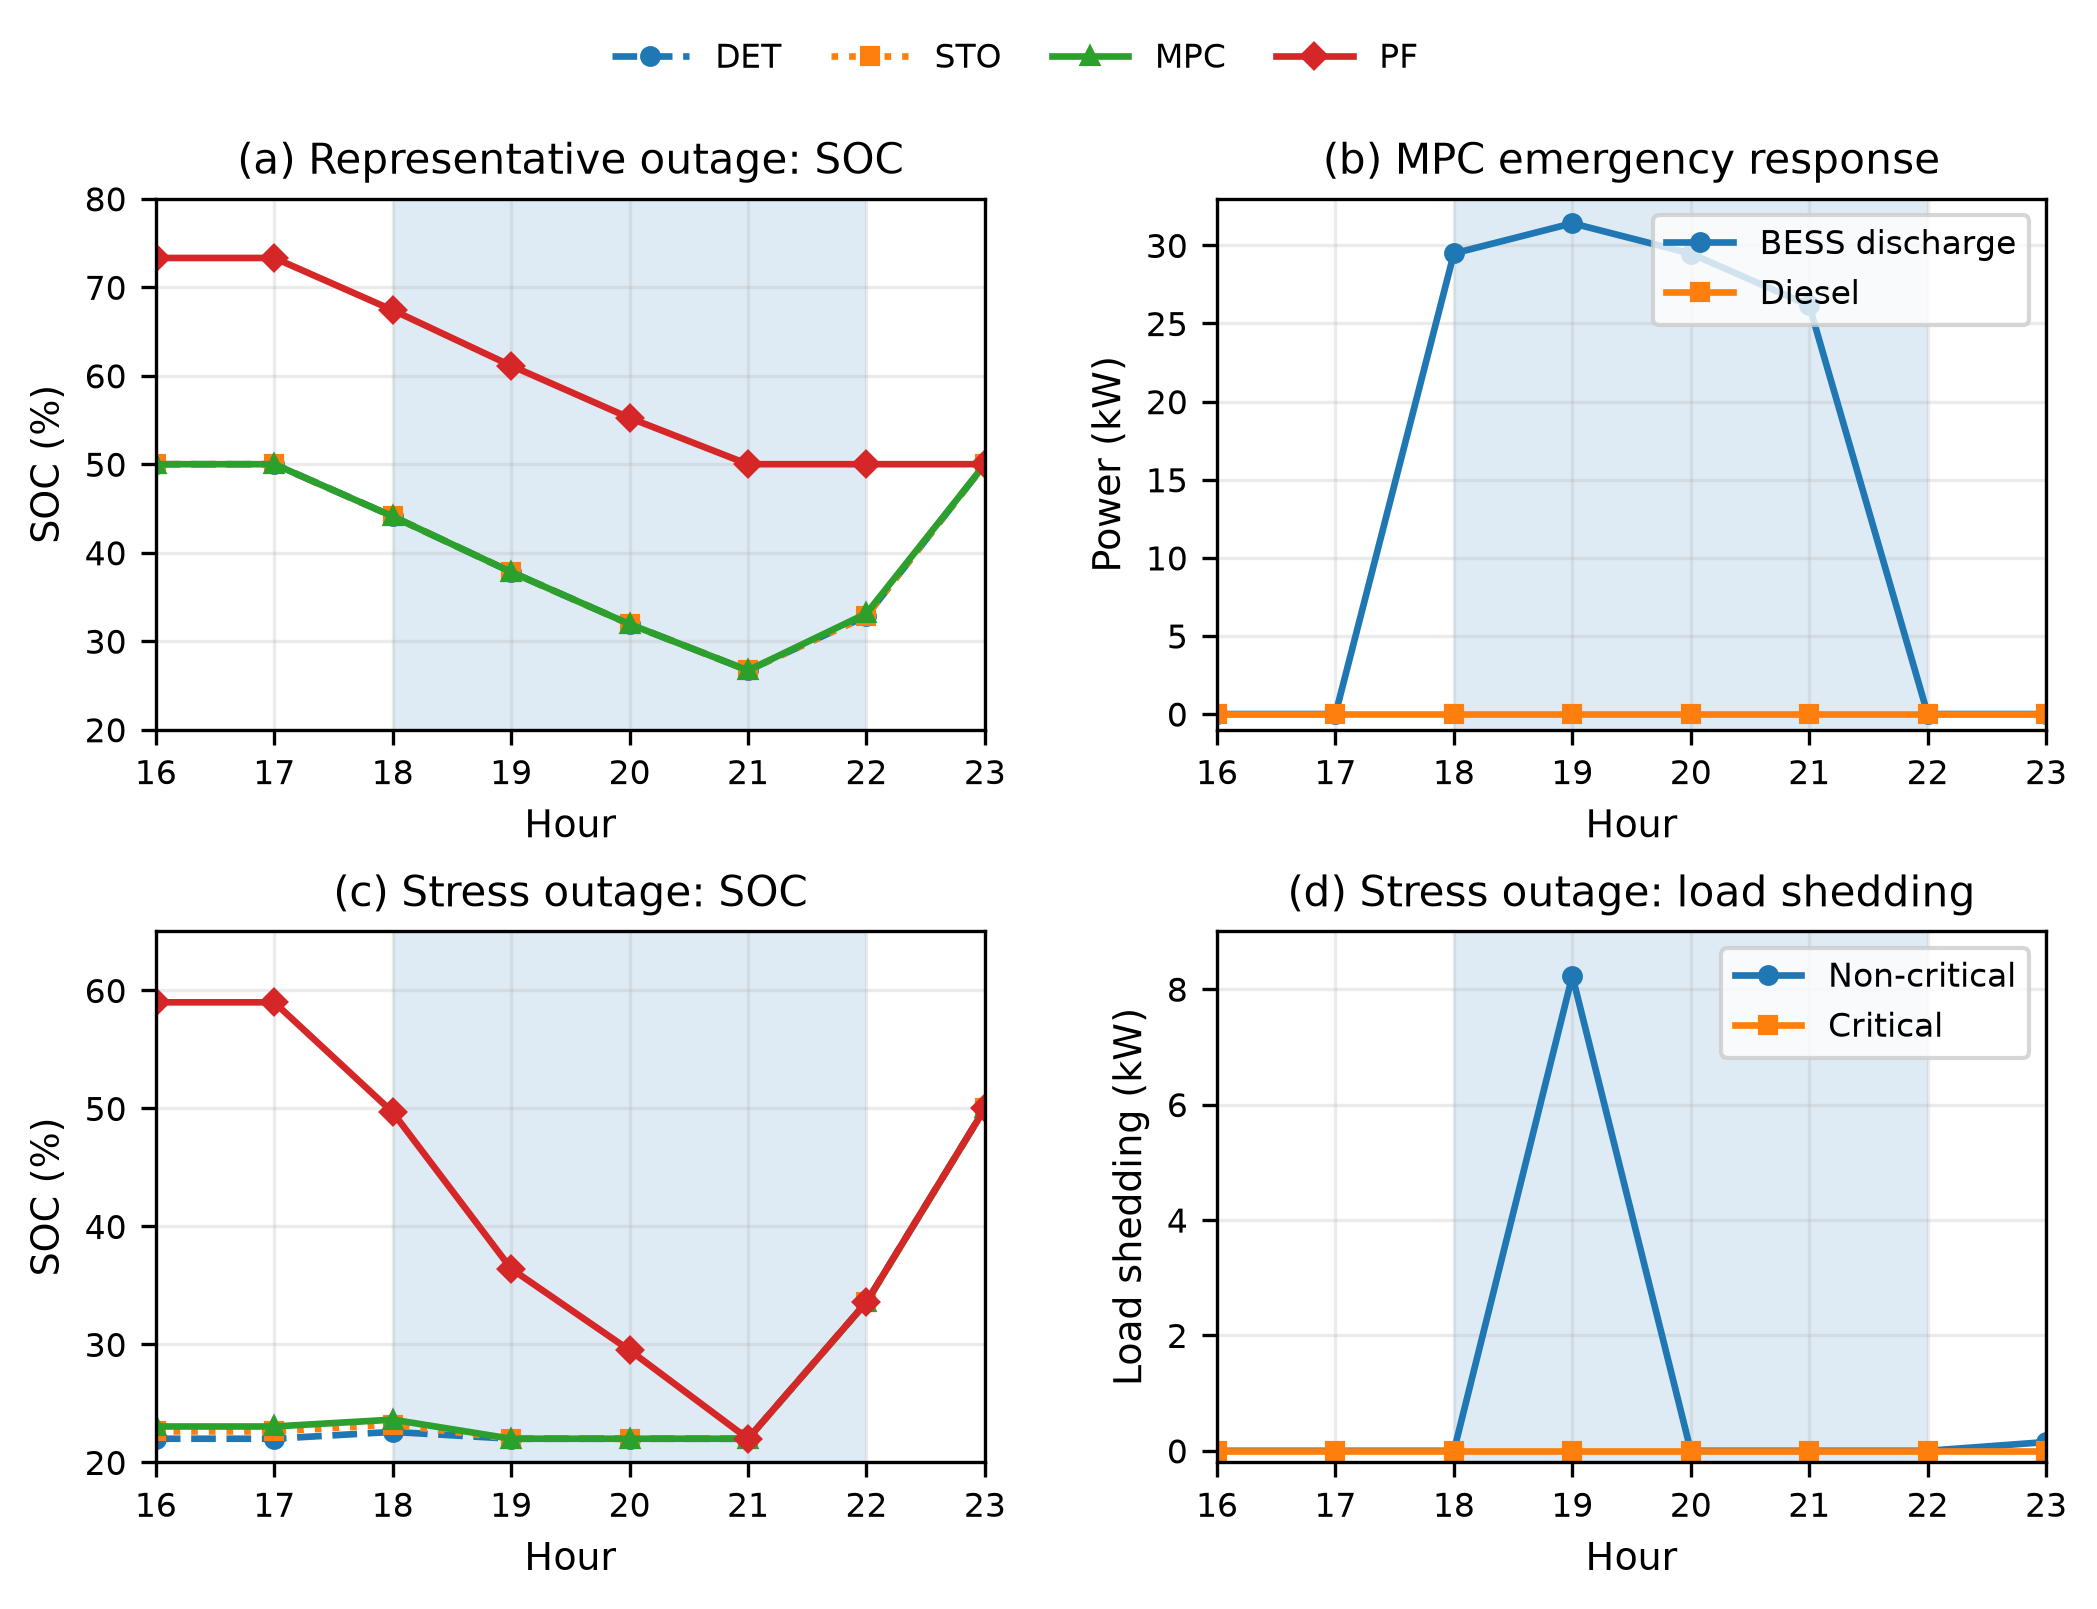

Saved PDF: forced_outage_results_v3\Fig6\Fig6_Forced_Outage_Dynamic_Response_Final.pdf
Saved PNG: forced_outage_results_v3\Fig6\Fig6_Forced_Outage_Dynamic_Response_Final.png


In [60]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# FIG. 6 — FINAL POLISHED IEEE VERSION
# =========================================================

rep = representative_hourly_summary.copy()
stress = stress_hourly_summary.copy()

strategies = ["DET", "STO", "MPC", "PF"]

# line styles so overlapping trajectories are still distinguishable
styles = {
    "DET": {"linestyle": "--", "marker": "o"},
    "STO": {"linestyle": ":",  "marker": "s"},
    "MPC": {"linestyle": "-",  "marker": "^"},
    "PF":  {"linestyle": "-",  "marker": "D"},
}

def get_strategy(df, strategy):
    return (
        df[df["strategy"] == strategy]
        .sort_values("hour")
        .copy()
    )

# ---------------------------------------------------------
# Prepare representative MPC variables
# ---------------------------------------------------------
rep_mpc = get_strategy(rep, "MPC")

rep_hours = rep_mpc["hour"].to_numpy()
mpc_discharge = rep_mpc["discharge"].to_numpy()
mpc_diesel = rep_mpc["dg"].to_numpy()

# ---------------------------------------------------------
# Prepare stress MPC shedding
# ---------------------------------------------------------
stress_mpc = get_strategy(stress, "MPC")

stress_hours = stress_mpc["hour"].to_numpy()
stress_noncritical_shed = stress_mpc["shed_ncrit"].to_numpy()
stress_critical_shed = stress_mpc["shed_crit"].to_numpy()

# =========================================================
# Figure setup
# =========================================================
plt.rcParams.update({
    "font.size": 8.5,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

fig, axes = plt.subplots(
    2, 2,
    figsize=(7.16, 5.4),   # IEEE two-column width friendly
    dpi=300
)

# outage interval: hours 18–21, grid returns at hour 22
OUTAGE_START = 18
OUTAGE_END = 22

# =========================================================
# (a) Representative outage: SOC
# =========================================================
ax = axes[0, 0]

for strategy in strategies:
    x = get_strategy(rep, strategy)

    ax.plot(
        x["hour"],
        100.0 * x["soc_end"],
        linewidth=1.6,
        markersize=4,
        label=strategy,
        **styles[strategy]
    )

ax.axvspan(
    OUTAGE_START,
    OUTAGE_END,
    alpha=0.14
)

ax.set_title("(a) Representative outage: SOC")
ax.set_xlabel("Hour")
ax.set_ylabel("SOC (%)")
ax.set_xlim(16, 23)
ax.set_ylim(20, 80)
ax.set_xticks(np.arange(16, 24, 1))
ax.grid(True, alpha=0.25)

# =========================================================
# (b) Representative outage: MPC emergency response
# =========================================================
ax = axes[0, 1]

ax.plot(
    rep_hours,
    mpc_discharge,
    marker="o",
    linewidth=1.6,
    markersize=4,
    label="BESS discharge"
)

ax.plot(
    rep_hours,
    mpc_diesel,
    marker="s",
    linewidth=1.6,
    markersize=4,
    label="Diesel"
)

ax.axvspan(
    OUTAGE_START,
    OUTAGE_END,
    alpha=0.14
)

ax.set_title("(b) MPC emergency response")
ax.set_xlabel("Hour")
ax.set_ylabel("Power (kW)")
ax.set_xlim(16, 23)
ax.set_xticks(np.arange(16, 24, 1))
ax.set_ylim(bottom=-1)
ax.grid(True, alpha=0.25)

ax.legend(
    loc="upper right",
    frameon=True
)

# =========================================================
# (c) Stress outage: SOC
# =========================================================
ax = axes[1, 0]

for strategy in strategies:
    x = get_strategy(stress, strategy)

    ax.plot(
        x["hour"],
        100.0 * x["soc_end"],
        linewidth=1.6,
        markersize=4,
        label=strategy,
        **styles[strategy]
    )

ax.axvspan(
    OUTAGE_START,
    OUTAGE_END,
    alpha=0.14
)

ax.set_title("(c) Stress outage: SOC")
ax.set_xlabel("Hour")
ax.set_ylabel("SOC (%)")
ax.set_xlim(16, 23)
ax.set_ylim(20, 65)
ax.set_xticks(np.arange(16, 24, 1))
ax.grid(True, alpha=0.25)

# =========================================================
# (d) Stress outage: MPC load shedding
# =========================================================
ax = axes[1, 1]

ax.plot(
    stress_hours,
    stress_noncritical_shed,
    marker="o",
    linewidth=1.6,
    markersize=4,
    label="Non-critical"
)

ax.plot(
    stress_hours,
    stress_critical_shed,
    marker="s",
    linewidth=1.6,
    markersize=4,
    label="Critical"
)

ax.axvspan(
    OUTAGE_START,
    OUTAGE_END,
    alpha=0.14
)

ax.set_title("(d) Stress outage: load shedding")
ax.set_xlabel("Hour")
ax.set_ylabel("Load shedding (kW)")
ax.set_xlim(16, 23)
ax.set_ylim(-0.2, 9.0)
ax.set_xticks(np.arange(16, 24, 1))
ax.grid(True, alpha=0.25)

ax.legend(
    loc="upper right",
    frameon=True
)

# =========================================================
# Global strategy legend
# =========================================================
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.995),
    columnspacing=1.5,
    handlelength=2.3
)

# =========================================================
# Layout
# =========================================================
fig.subplots_adjust(
    top=0.88,
    bottom=0.10,
    left=0.10,
    right=0.98,
    hspace=0.38,
    wspace=0.28
)

# =========================================================
# Save
# =========================================================
FIG6_DIR = Path("forced_outage_results_v3") / "Fig6"
FIG6_DIR.mkdir(parents=True, exist_ok=True)

pdf_path = FIG6_DIR / "Fig6_Forced_Outage_Dynamic_Response_Final.pdf"
png_path = FIG6_DIR / "Fig6_Forced_Outage_Dynamic_Response_Final.png"

fig.savefig(
    pdf_path,
    bbox_inches="tight"
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved PDF:", pdf_path)
print("Saved PNG:", png_path)

In [61]:
# check important dataframes

for name in [
    "forced_outage_daily",
    "oos_daily",
    "combined_daily",
    "source_daily",
    "final_daily"
]:
    if name in globals():
        print(name, "FOUND", globals()[name].shape)

forced_outage_daily FOUND (127, 104)
combined_daily FOUND (1016, 61)
source_daily FOUND (3048, 54)


In [62]:
df = forced_outage_daily.copy()

print(df.shape)
print(df.columns.tolist())

(127, 104)
['date', 'alpha', 'outage_start_h', 'outage_end_h', 'det_cost_nok', 'det_critical_eens_kwh', 'det_noncritical_eens_kwh', 'det_outage_critical_eens_kwh', 'det_outage_noncritical_eens_kwh', 'det_critical_interrupted', 'det_outage_critical_interrupted', 'det_diesel_energy_kwh', 'det_battery_throughput_kwh', 'det_curtailment_kwh', 'det_grid_import_kwh', 'det_grid_export_kwh', 'det_min_soc', 'det_soc_at_outage', 'det_terminal_soc', 'det_final_soc_abs_deviation', 'det_final_energy_abs_deviation_kwh', 'det_max_outage_grid_exchange_kw', 'det_max_simultaneous_buy_sell_kw', 'det_max_balance_residual_kw', 'det_preoutage_soc_anchor', 'det_emergency_dg_commitment_changes', 'det_emergency_battery_mode_changes', 'det_emergency_plan_solve_time_s', 'sto_cost_nok', 'sto_critical_eens_kwh', 'sto_noncritical_eens_kwh', 'sto_outage_critical_eens_kwh', 'sto_outage_noncritical_eens_kwh', 'sto_critical_interrupted', 'sto_outage_critical_interrupted', 'sto_diesel_energy_kwh', 'sto_battery_throughput

forced_outage_daily shape: (127, 104)
  strategy   mean_cost  mean_noncritical_eens  mean_critical_eens  \
0      DET  242.850399               0.298651                 0.0   
1      STO  241.362140               0.259231                 0.0   
2      MPC  245.150736               0.292356                 0.0   
3       PF  175.426043               0.000000                 0.0   

   mean_diesel_energy  solve_time  critical_interrupt_prob  
0        1.601587e+01    0.151633                      0.0  
1        1.578761e+01    3.089368                      0.0  
2        1.689068e+01    1.604799                      0.0  
3        6.637430e-15    0.068936                      0.0  
Summary CSV saved: forced_outage_results_v3\Fig7\Fig7_Forced_Outage_Summary.csv


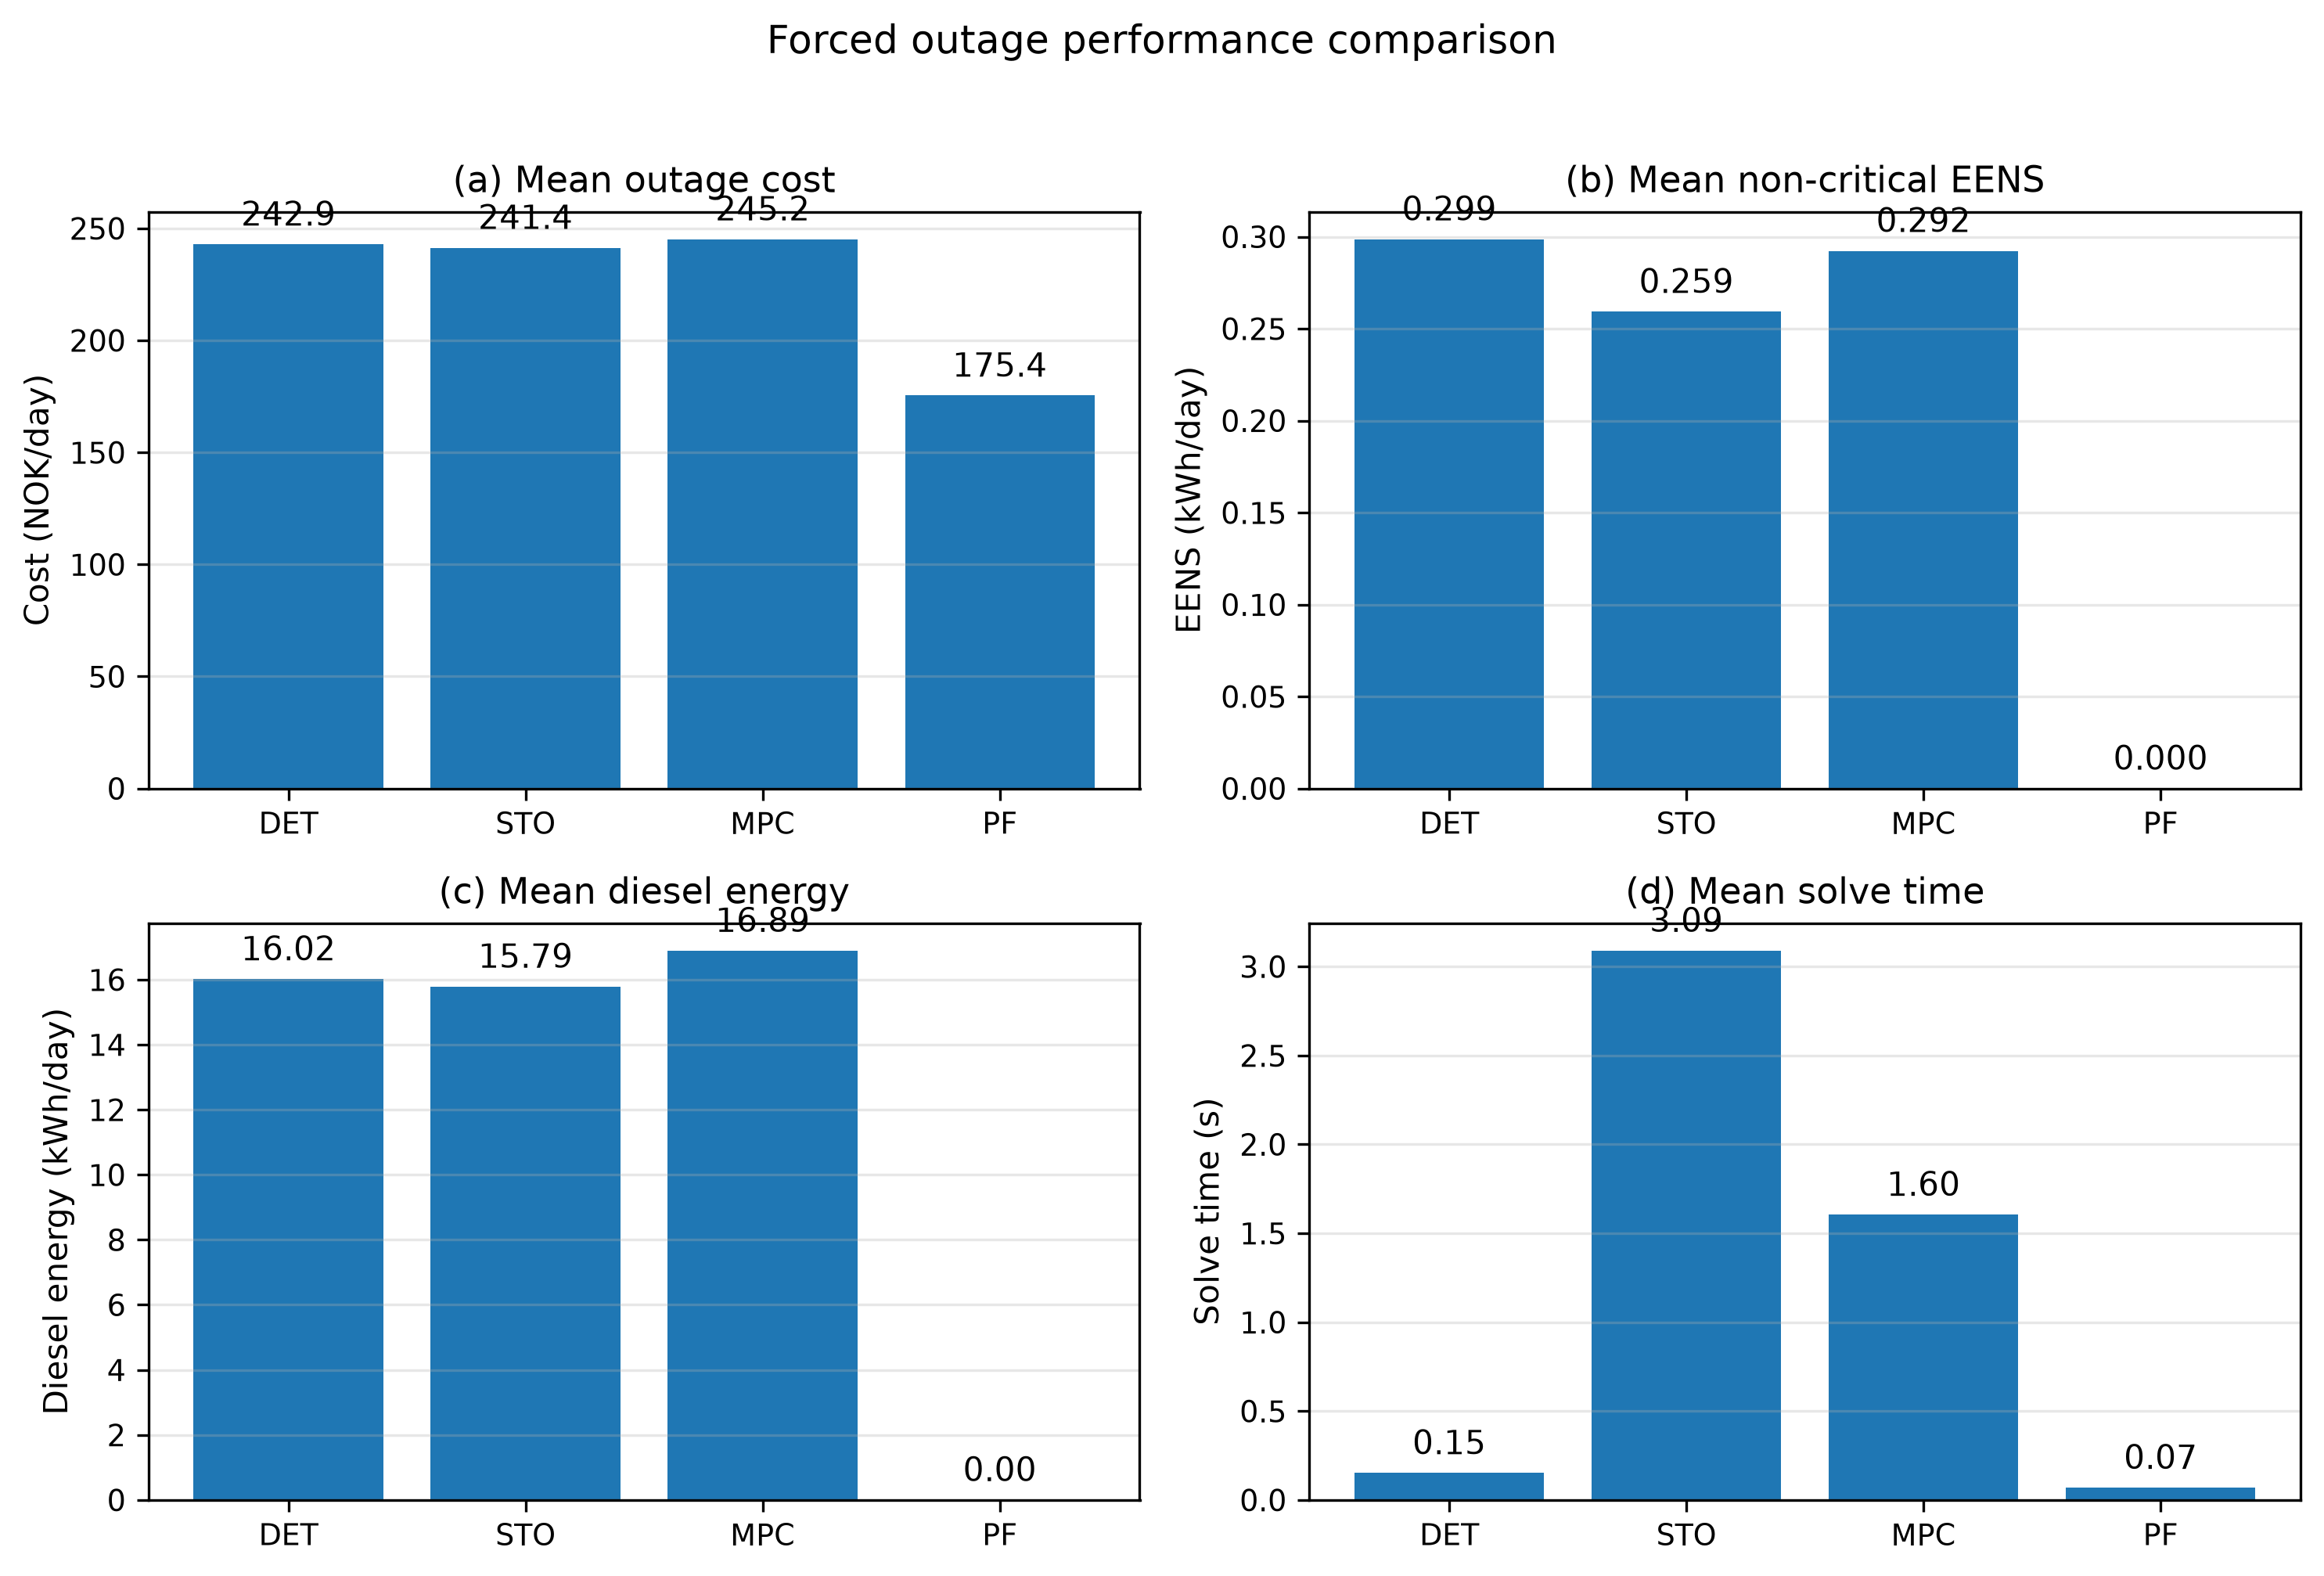

Saved PDF: forced_outage_results_v3\Fig7\Fig7_Forced_Outage_Performance_Revised.pdf
Saved PNG: forced_outage_results_v3\Fig7\Fig7_Forced_Outage_Performance_Revised.png


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# FIG.7 REVISED
# Forced outage performance summary
# =========================================================

# ---------------------------------------------------------
# 0) Make sure forced_outage_daily exists
# ---------------------------------------------------------
try:
    forced_outage_daily
except NameError:
    raise NameError(
        "forced_outage_daily is not defined. "
        "Please load/build forced_outage_daily first in this notebook."
    )

print("forced_outage_daily shape:", forced_outage_daily.shape)

# ---------------------------------------------------------
# 1) Build summary table
# ---------------------------------------------------------
strategy_order = ["DET", "STO", "MPC", "PF"]

summary_rows = []
for s in strategy_order:
    row = {
        "strategy": s,
        "mean_cost": forced_outage_daily[f"{s.lower()}_cost_nok"].mean(),
        "mean_noncritical_eens": forced_outage_daily[f"{s.lower()}_noncritical_eens_kwh"].mean(),
        "mean_critical_eens": forced_outage_daily[f"{s.lower()}_critical_eens_kwh"].mean(),
        "mean_diesel_energy": forced_outage_daily[f"{s.lower()}_diesel_energy_kwh"].mean(),
        "solve_time": (
            forced_outage_daily["mpc_total_solve_time_s"].mean()
            if s == "MPC"
            else forced_outage_daily[f"{s.lower()}_total_solve_time_s"].mean()
        ),
        "critical_interrupt_prob": forced_outage_daily[f"{s.lower()}_critical_interrupted"].mean(),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df["strategy"] = pd.Categorical(
    summary_df["strategy"],
    categories=strategy_order,
    ordered=True
)
summary_df = summary_df.sort_values("strategy").reset_index(drop=True)

print(summary_df)

# ---------------------------------------------------------
# 2) Save summary CSV
# ---------------------------------------------------------
out_dir = Path("forced_outage_results_v3/Fig7")
out_dir.mkdir(parents=True, exist_ok=True)

summary_csv = out_dir / "Fig7_Forced_Outage_Summary.csv"
summary_df.to_csv(summary_csv, index=False)
print("Summary CSV saved:", summary_csv)

# ---------------------------------------------------------
# 3) Plot settings
# ---------------------------------------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

x = np.arange(len(summary_df))
labels = summary_df["strategy"].astype(str).tolist()

fig, axes = plt.subplots(2, 2, figsize=(10, 6.8), dpi=300)
axes = axes.flatten()

# ---------------------------------------------------------
# Helper for bar labels
# ---------------------------------------------------------
def add_bar_labels(ax, bars, fmt="{:.2f}", ypad_frac=0.02):
    vals = [b.get_height() for b in bars]
    ymax = max(vals) if len(vals) > 0 else 0.0
    offset = ypad_frac * ymax if ymax > 0 else 0.02
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2,
            h + offset,
            fmt.format(h),
            ha="center",
            va="bottom"
        )

# ---------------------------------------------------------
# (a) Mean outage cost
# ---------------------------------------------------------
bars = axes[0].bar(x, summary_df["mean_cost"])
axes[0].set_title("(a) Mean outage cost")
axes[0].set_ylabel("Cost (NOK/day)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].grid(True, axis="y", alpha=0.3)
add_bar_labels(axes[0], bars, fmt="{:.1f}")

# ---------------------------------------------------------
# (b) Mean non-critical EENS
# ---------------------------------------------------------
bars = axes[1].bar(x, summary_df["mean_noncritical_eens"])
axes[1].set_title("(b) Mean non-critical EENS")
axes[1].set_ylabel("EENS (kWh/day)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].grid(True, axis="y", alpha=0.3)
add_bar_labels(axes[1], bars, fmt="{:.3f}")

# ---------------------------------------------------------
# (c) Mean diesel energy
# ---------------------------------------------------------
bars = axes[2].bar(x, summary_df["mean_diesel_energy"])
axes[2].set_title("(c) Mean diesel energy")
axes[2].set_ylabel("Diesel energy (kWh/day)")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].grid(True, axis="y", alpha=0.3)
add_bar_labels(axes[2], bars, fmt="{:.2f}")

# ---------------------------------------------------------
# (d) Mean solve time
# ---------------------------------------------------------
bars = axes[3].bar(x, summary_df["solve_time"])
axes[3].set_title("(d) Mean solve time")
axes[3].set_ylabel("Solve time (s)")
axes[3].set_xticks(x)
axes[3].set_xticklabels(labels)
axes[3].grid(True, axis="y", alpha=0.3)
add_bar_labels(axes[3], bars, fmt="{:.2f}")

# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------
fig.suptitle("Forced outage performance comparison", y=0.98, fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])

# ---------------------------------------------------------
# 4) Save figure
# ---------------------------------------------------------
pdf_path = out_dir / "Fig7_Forced_Outage_Performance_Revised.pdf"
png_path = out_dir / "Fig7_Forced_Outage_Performance_Revised.png"

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved PDF:", pdf_path)
print("Saved PNG:", png_path)

In [69]:
import os
print(os.listdir())

['.ipynb_checkpoints', '09_Forced_Grid_Outage_Islanding_FULL.ipynb', 'config', 'data', 'Fig2_CoU_SMR_RR_GC_IS.pdf', 'Fig2_CoU_SMR_RR_GC_IS.png', 'Fig6_Forced_Outage_Response_Final.pdf', 'Fig6_Forced_Outage_Response_Final.png', 'Fig6_Forced_Outage_Trajectory.pdf', 'Fig6_Forced_Outage_Trajectory.png', 'figures_source_sensitivity', 'final_oos_det_sto_mpc_pf_daily.csv', 'forced_outage_results_v3', 'Operational_Performance_Summary.csv', 'README_FORCED_GRID_OUTAGE_FULL.txt', 'source_sensitivity_det_sto_mpc_pf_daily.csv', 'source_sensitivity_det_sto_mpc_pf_summary.csv']


In [70]:
print(os.listdir())

['.ipynb_checkpoints', '09_Forced_Grid_Outage_Islanding_FULL.ipynb', 'config', 'data', 'Fig2_CoU_SMR_RR_GC_IS.pdf', 'Fig2_CoU_SMR_RR_GC_IS.png', 'Fig6_Forced_Outage_Response_Final.pdf', 'Fig6_Forced_Outage_Response_Final.png', 'Fig6_Forced_Outage_Trajectory.pdf', 'Fig6_Forced_Outage_Trajectory.png', 'figures_source_sensitivity', 'final_oos_det_sto_mpc_pf_daily.csv', 'forced_outage_results_v3', 'Operational_Performance_Summary.csv', 'README_FORCED_GRID_OUTAGE_FULL.txt', 'source_sensitivity_det_sto_mpc_pf_daily.csv', 'source_sensitivity_det_sto_mpc_pf_summary.csv']


In [71]:
%whos

Variable                           Type            Data/Info
------------------------------------------------------------
ALPHA_ORDER                        list            n=4
BASE_SEED                          int             42
BESS_E                             float           500.0
BRA_PROBS                          ndarray         50: 50 elems, type `float64`, 400 bytes
CFG                                dict            n=14
COMBINED_FILE                      WindowsPath     E:\AIUB Ref. Book & Class<...>_det_sto_mpc_pf_daily.csv
CONFIDENCE                         float           0.95
CRIT_SHARE                         float           0.33
C_BATT                             float           0.13
C_CURT                             float           0.1
C_DG                               float           4.26
C_SHED_C                           float           100.0
C_SHED_N                           float           10.0
DEV_FILE                           WindowsPath     E:\AIUB Ref. Bo

In [72]:
import os
import pandas as pd

# search possible convergence files
for root, dirs, files in os.walk("."):
    for f in files:
        if "converg" in f.lower() or "scenario" in f.lower() or "bra" in f.lower():
            print(os.path.join(root,f))

In [73]:
import os
import pandas as pd

# search possible convergence files
for root, dirs, files in os.walk("."):
    for f in files:
        if "converg" in f.lower() or "scenario" in f.lower() or "bra" in f.lower():
            print(os.path.join(root,f))

In [74]:
print("Available variables:")
for name in [
    "N0",
    "K_FINAL",
    "BRA_PROBS",
    "source_daily",
    "combined_daily",
    "dev",
    "oos"
]:
    print(name, name in globals())

Available variables:
N0 True
K_FINAL True
BRA_PROBS True
source_daily True
combined_daily True
dev True
oos True


In [75]:
import time
import numpy as np
import pandas as pd

scenario_targets = [5, 10, 20, 30, 50]

scenario_convergence = []


for k in scenario_targets:

    print(f"Running BRA scenario size = {k}")

    start = time.time()

    # build reduced scenario template
    probs = load_or_build_bra50_template(
        target=k
    )

    solve_time = time.time() - start


    # store convergence information
    scenario_convergence.append({
        "scenario_number": k,
        "computation_time_s": solve_time,
        "probability_sum": np.sum(probs)
    })


scenario_convergence_df = pd.DataFrame(
    scenario_convergence
)

scenario_convergence_df

Running BRA scenario size = 5


TypeError: load_or_build_bra50_template() got an unexpected keyword argument 'target'

In [77]:
import inspect

print(inspect.signature(load_or_build_bra50_template))

()


In [78]:
bra_result = load_or_build_bra50_template()

print(type(bra_result))

try:
    print(bra_result.shape)
except:
    print(len(bra_result))

print(bra_result[:5])

Loaded BRA template: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Pyomo_DET_PF_Step1\bra_outputs\bra_alpha20_N5000_K50.npz
<class 'tuple'>
2
(array([[-1.30202591, -1.37303323,  2.24363491, ...,  1.54624864,
        -0.29252276,  0.16386129],
       [ 0.8362978 ,  0.96569546,  0.67742109, ..., -0.83939537,
        -1.03633597, -1.13648929],
       [ 0.89505956, -0.39022528,  1.37055859, ..., -0.15325864,
         1.53589711, -0.52850246],
       ...,
       [ 0.36127392,  0.61692577, -1.68547943, ...,  0.8437673 ,
         0.47307111, -0.1452978 ],
       [ 1.04781747,  0.40565722, -0.32677315, ...,  1.08070806,
        -0.7921873 , -0.33221591],
       [-1.24111377, -0.40453944, -0.49926963, ...,  0.1866872 ,
         1.01657555, -0.15227876]], shape=(50, 72)), array([0.0128, 0.0092, 0.0124, 0.0148, 0.0302, 0.0428, 0.0426, 0.0224,
       0.0172, 0.021 , 0.019 , 0.0112, 0.011 , 0.0124, 0.0168, 0.0158,

In [79]:
Z_TEMPLATE, BRA_PROBS = load_or_build_bra50_template()

print("Z_TEMPLATE shape:", Z_TEMPLATE.shape)
print("BRA_PROBS shape:", BRA_PROBS.shape)
print("Probability sum:", BRA_PROBS.sum())
print("Min prob:", BRA_PROBS.min())
print("Max prob:", BRA_PROBS.max())

Loaded BRA template: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Pyomo_DET_PF_Step1\bra_outputs\bra_alpha20_N5000_K50.npz
Z_TEMPLATE shape: (50, 72)
BRA_PROBS shape: (50,)
Probability sum: 1.0000000000000002
Min prob: 0.008800000000000004
Max prob: 0.05820000000000001


In [82]:
import os

for root, dirs, files in os.walk("."):
    for f in files:
        if (
            "k_" in f.lower()
            or "scenario" in f.lower()
            or "convergence" in f.lower()
            or "bra" in f.lower()
        ):
            print(os.path.join(root,f))

In [83]:
import inspect

print(inspect.signature(backward_reduction_to_target))
print(inspect.getsource(backward_reduction_to_target)[:1000])

(errors, probabilities, target_count)
def backward_reduction_to_target(errors, probabilities, target_count):
    errors = np.asarray(errors, dtype=np.float32)
    probs = np.asarray(probabilities, dtype=np.float64).copy()
    n = len(probs)

    D = cdist(errors, errors, metric='euclidean').astype(np.float32)
    np.fill_diagonal(D, np.inf)
    active = np.ones(n, dtype=bool)
    version = np.zeros(n, dtype=np.int64)

    def nearest_active(i):
        work = D[i].copy()
        work[~active] = np.inf
        work[i] = np.inf
        j = int(np.argmin(work))
        return j, float(work[j])

    heap = []
    for i in range(n):
        _, d = nearest_active(i)
        heapq.heappush(heap, (probs[i] * d, i, version[i]))

    remaining = n
    while remaining > target_count:
        while True:
            old_cost, i, ver = heapq.heappop(heap)
            if not active[i] or ver != version[i]:
                continue
            j, d = nearest_active(i)
            true_cost = probs[i]

In [84]:
K_LIST = [5, 10, 20, 30, 50]

for k in K_LIST:
    Zk, pk = backward_reduction_to_target(Z_TEMPLATE, BRA_PROBS, k)
    print(
        f"K={k} | Z shape={Zk.shape} | p shape={pk.shape} | "
        f"sum(p)={pk.sum():.6f} | min(p)={pk.min():.6f} | max(p)={pk.max():.6f}"
    )

K=5 | Z shape=(5,) | p shape=(5,) | sum(p)=1.000000 | min(p)=0.132200 | max(p)=0.269600
K=10 | Z shape=(10,) | p shape=(10,) | sum(p)=1.000000 | min(p)=0.058600 | max(p)=0.175600
K=20 | Z shape=(20,) | p shape=(20,) | sum(p)=1.000000 | min(p)=0.031400 | max(p)=0.079600
K=30 | Z shape=(30,) | p shape=(30,) | sum(p)=1.000000 | min(p)=0.015800 | max(p)=0.058200
K=50 | Z shape=(50,) | p shape=(50,) | sum(p)=1.000000 | min(p)=0.008800 | max(p)=0.058200


In [85]:
import pandas as pd
import os

print(os.listdir())

# search related csv
for f in os.listdir():
    if "oos" in f.lower() or "summary" in f.lower():
        print(f)

['.ipynb_checkpoints', '09_Forced_Grid_Outage_Islanding_FULL.ipynb', 'config', 'data', 'Fig2_CoU_SMR_RR_GC_IS.pdf', 'Fig2_CoU_SMR_RR_GC_IS.png', 'Fig6_Forced_Outage_Response_Final.pdf', 'Fig6_Forced_Outage_Response_Final.png', 'Fig6_Forced_Outage_Trajectory.pdf', 'Fig6_Forced_Outage_Trajectory.png', 'figures_source_sensitivity', 'final_oos_det_sto_mpc_pf_daily.csv', 'forced_outage_results_v3', 'Operational_Performance_Summary.csv', 'README_FORCED_GRID_OUTAGE_FULL.txt', 'source_sensitivity_det_sto_mpc_pf_daily.csv', 'source_sensitivity_det_sto_mpc_pf_summary.csv']
final_oos_det_sto_mpc_pf_daily.csv
Operational_Performance_Summary.csv
source_sensitivity_det_sto_mpc_pf_summary.csv


In [86]:
df = pd.read_csv("final_oos_det_sto_mpc_pf_daily.csv")

print(df.shape)
print(df.columns.tolist())

(1016, 61)
['date', 'mode', 'alpha', 'det_cost_nok', 'sto_cost_nok', 'cou_nok', 'sto_savings_vs_det_nok', 'sto_residual_gap_vs_pf_nok', 'det_critical_eens_kwh', 'sto_critical_eens_kwh', 'det_noncritical_eens_kwh', 'sto_noncritical_eens_kwh', 'det_critical_interrupted', 'sto_critical_interrupted', 'det_diesel_kwh', 'sto_diesel_kwh', 'det_curtailment_kwh', 'sto_curtailment_kwh', 'det_grid_import_kwh', 'sto_grid_import_kwh', 'det_grid_export_kwh', 'sto_grid_export_kwh', 'det_solve_time_s', 'sto_solve_time_s', 'sto_recourse_time_s', 'det_max_simultaneous_buy_sell_kw', 'sto_max_simultaneous_buy_sell_kw', 'pf_cost_nok', 'pf_critical_eens_kwh', 'pf_noncritical_eens_kwh', 'pf_critical_interrupted', 'pf_diesel_kwh', 'pf_curtailment_kwh', 'pf_grid_import_kwh', 'pf_grid_export_kwh', 'pf_solve_time_s', 'pf_max_simultaneous_buy_sell_kw', 'Hp', 'mpc_cost_nok', 'mpc_critical_eens_kwh', 'mpc_noncritical_eens_kwh', 'mpc_critical_interrupted', 'mpc_diesel_kwh', 'mpc_curtailment_kwh', 'mpc_grid_import_kw

In [87]:
import pandas as pd

df = pd.read_csv(
    "final_oos_det_sto_mpc_pf_daily.csv"
)


summary = (
    df.groupby("mode")
    .agg(
        DET=("det_cost_nok","mean"),
        STO=("sto_cost_nok","mean"),
        MPC=("mpc_cost_nok","mean"),
        PF=("pf_cost_nok","mean")
    )
    .reset_index()
)


summary["CoU"] = (
    summary["DET"] -
    summary["PF"]
)


summary["SMR"] = (
    (summary["DET"]-summary["STO"])
    /
    summary["CoU"]
    *100
)


summary["RR"] = (
    (summary["DET"]-summary["MPC"])
    /
    summary["CoU"]
    *100
)


print(summary.round(3))

  mode       DET       STO       MPC        PF     CoU     SMR      RR
0   GC   150.385   150.342   150.468   150.116   0.269  16.128 -30.888
1   IS  1773.447  1733.451  1725.340  1719.498  53.949  74.136  89.170


Input shape: (1016, 61)

Fig.2 summary:
  mode       DET       STO       MPC        PF     CoU     SMR      RR
0   GC   150.385   150.342   150.468   150.116   0.269  16.128 -30.888
1   IS  1773.447  1733.451  1725.340  1719.498  53.949  74.136  89.170


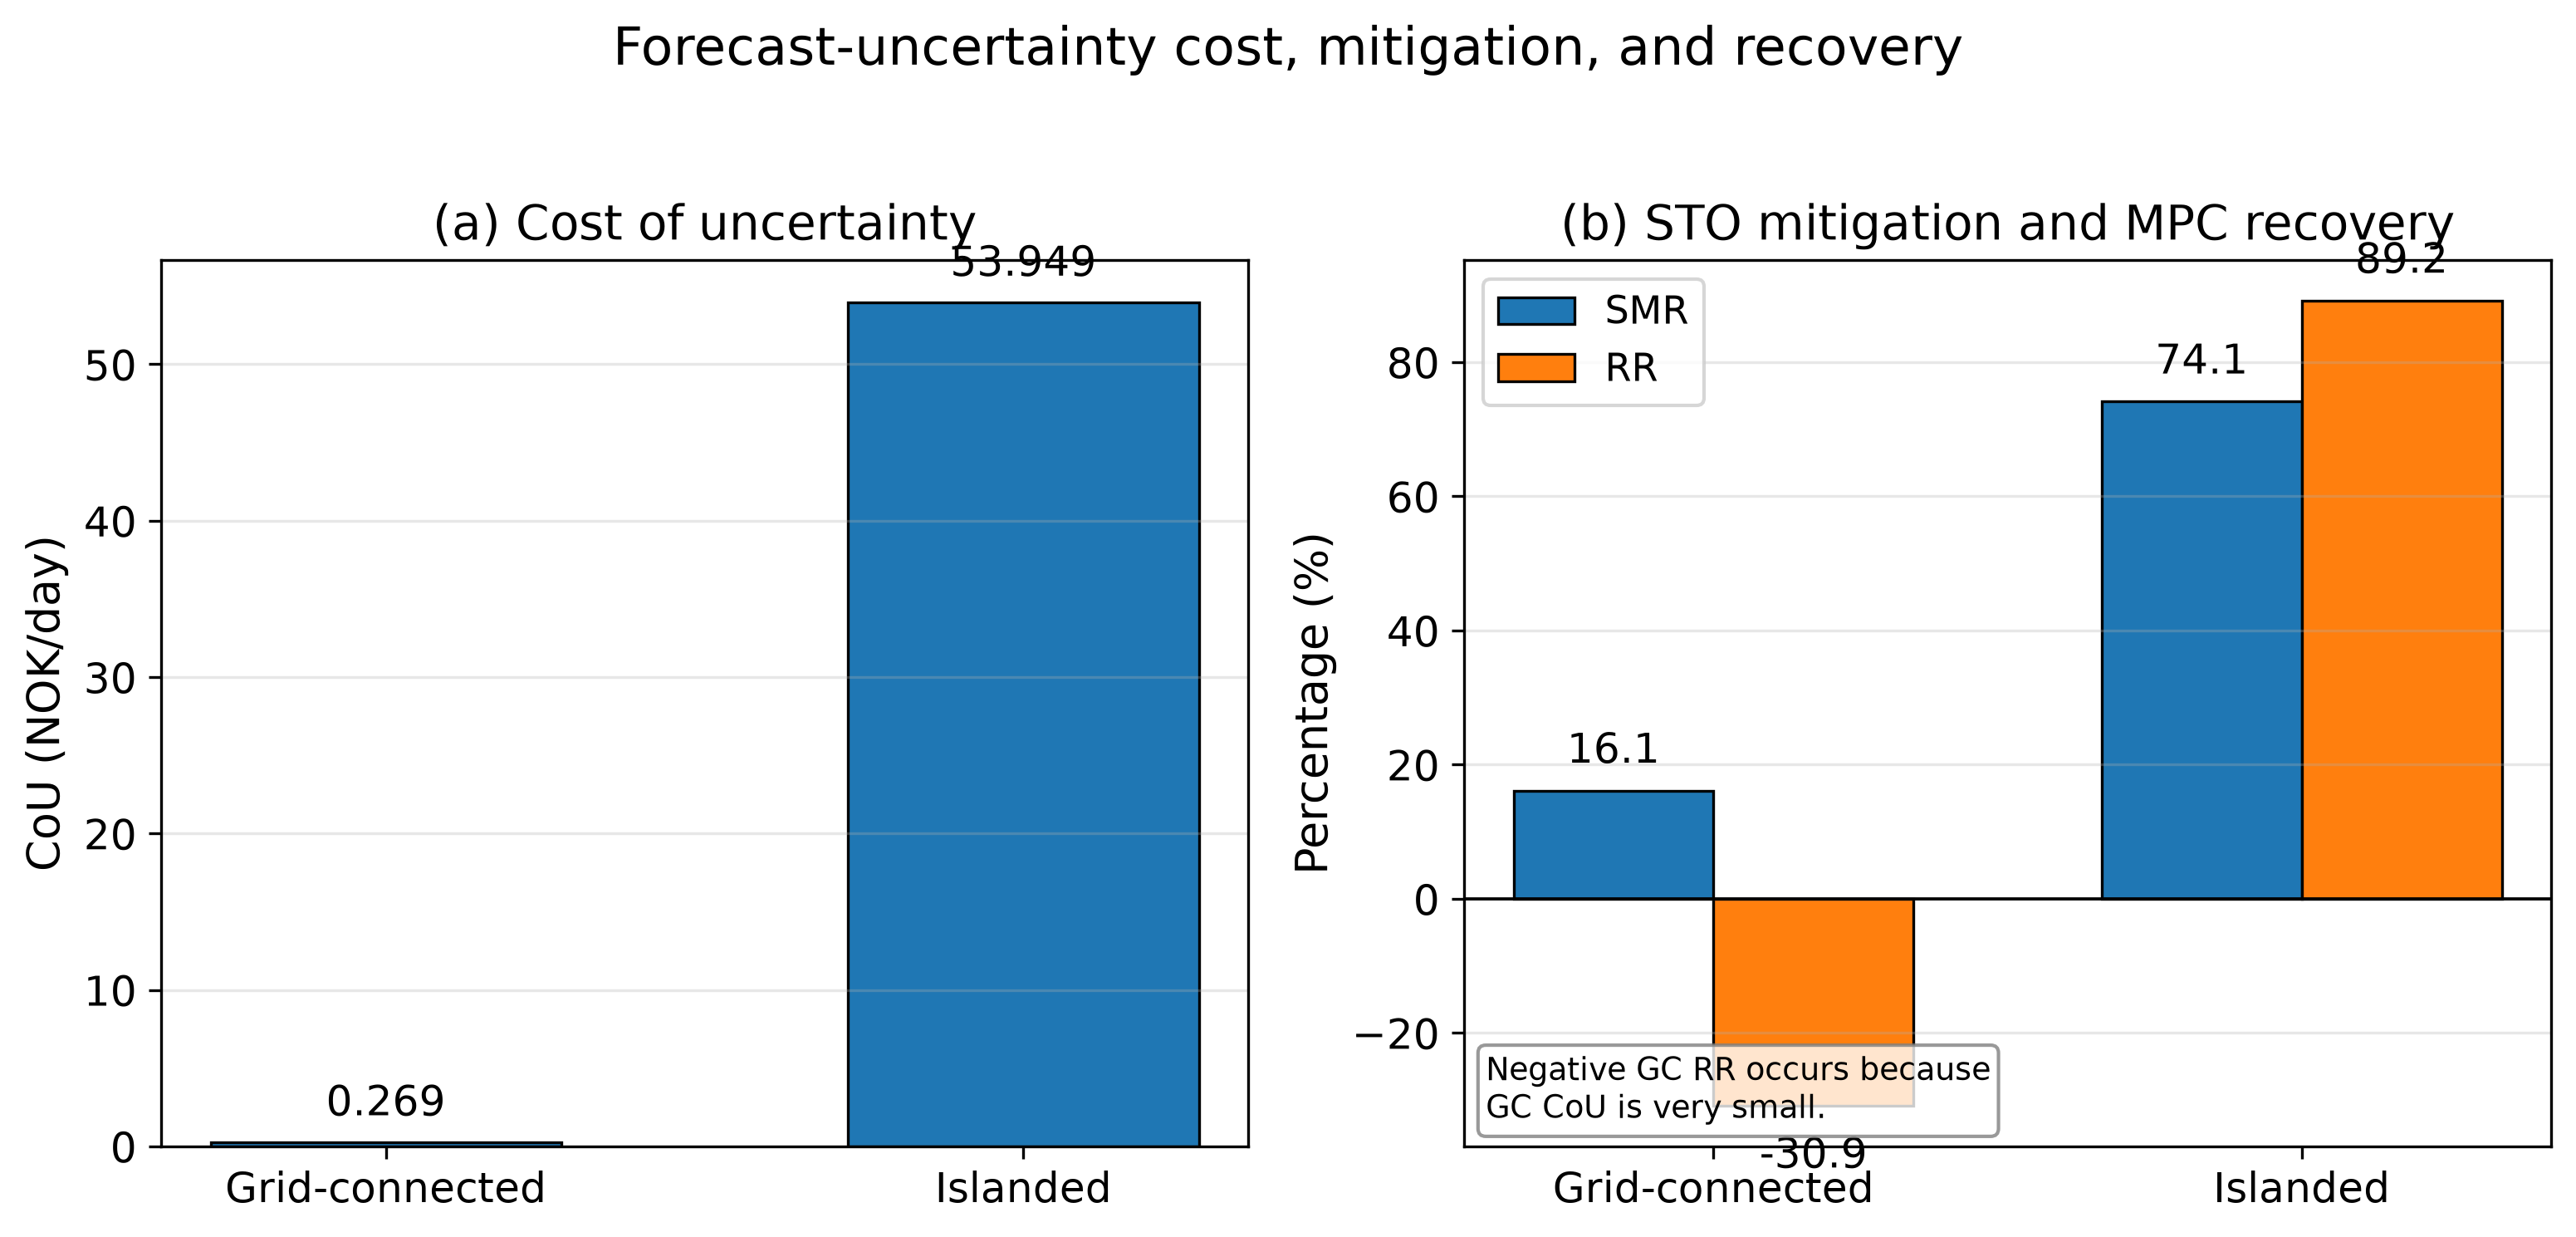


Saved summary CSV: forced_outage_results_v3\Fig2\Fig2_CoU_SMR_RR_summary.csv
Saved PDF: forced_outage_results_v3\Fig2\Fig2_CoU_SMR_RR_Final.pdf
Saved PNG: forced_outage_results_v3\Fig2\Fig2_CoU_SMR_RR_Final.png


In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# Fig.2: CoU, SMR, RR (GC vs IS)
# Final polished version
# =========================================================

# ---------- Load data ----------
csv_path = Path("final_oos_det_sto_mpc_pf_daily.csv")
df = pd.read_csv(csv_path)

print("Input shape:", df.shape)

# ---------- Clean mode labels ----------
df["mode"] = df["mode"].astype(str).str.strip().str.upper()

mode_map = {
    "GC": "Grid-connected",
    "IS": "Islanded"
}

mode_order = ["GC", "IS"]

# ---------- Aggregate ----------
summary = (
    df.groupby("mode")
    .agg(
        DET=("det_cost_nok", "mean"),
        STO=("sto_cost_nok", "mean"),
        MPC=("mpc_cost_nok", "mean"),
        PF=("pf_cost_nok", "mean"),
    )
    .reset_index()
)

summary = summary[summary["mode"].isin(mode_order)].copy()
summary["mode"] = pd.Categorical(summary["mode"], categories=mode_order, ordered=True)
summary = summary.sort_values("mode").reset_index(drop=True)

# ---------- Metrics ----------
summary["CoU"] = summary["DET"] - summary["PF"]
summary["SMR"] = np.where(
    summary["CoU"].abs() > 1e-12,
    (summary["DET"] - summary["STO"]) / summary["CoU"] * 100,
    np.nan
)
summary["RR"] = np.where(
    summary["CoU"].abs() > 1e-12,
    (summary["DET"] - summary["MPC"]) / summary["CoU"] * 100,
    np.nan
)

summary["mode_label"] = summary["mode"].map(mode_map)

print("\nFig.2 summary:")
print(summary[["mode", "DET", "STO", "MPC", "PF", "CoU", "SMR", "RR"]].round(3))

# ---------- Save summary CSV ----------
out_dir = Path("forced_outage_results_v3/Fig2")
out_dir.mkdir(parents=True, exist_ok=True)

summary_csv = out_dir / "Fig2_CoU_SMR_RR_summary.csv"
summary.to_csv(summary_csv, index=False)

# ---------- Plot style ----------
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8), dpi=300)

# =========================================================
# (a) Cost of Uncertainty
# =========================================================
ax = axes[0]

x = np.arange(len(summary))
cou_vals = summary["CoU"].to_numpy()

bars = ax.bar(
    x,
    cou_vals,
    width=0.55,
    edgecolor="black",
    linewidth=0.8
)

ax.set_xticks(x)
ax.set_xticklabels(summary["mode_label"])
ax.set_ylabel("CoU (NOK/day)")
ax.set_title("(a) Cost of uncertainty")
ax.grid(axis="y", alpha=0.3)

# value labels
for b, v in zip(bars, cou_vals):
    offset = 0.02 * max(cou_vals.max(), 1)
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + offset,
        f"{v:.3f}",
        ha="center",
        va="bottom"
    )

# =========================================================
# (b) Uncertainty mitigation and recovery
# =========================================================
ax = axes[1]

smr_vals = summary["SMR"].to_numpy()
rr_vals = summary["RR"].to_numpy()

w = 0.34
bars1 = ax.bar(
    x - w/2,
    smr_vals,
    width=w,
    label="SMR",
    edgecolor="black",
    linewidth=0.8
)
bars2 = ax.bar(
    x + w/2,
    rr_vals,
    width=w,
    label="RR",
    edgecolor="black",
    linewidth=0.8
)

ax.axhline(0, color="black", linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels(summary["mode_label"])
ax.set_ylabel("Percentage (%)")
ax.set_title("(b) STO mitigation and MPC recovery")
ax.legend(frameon=True)
ax.grid(axis="y", alpha=0.3)

# value labels
all_vals = np.concatenate([smr_vals[~np.isnan(smr_vals)], rr_vals[~np.isnan(rr_vals)]])
yr = max(abs(all_vals).max(), 1.0)

for b, v in zip(bars1, smr_vals):
    if np.isnan(v):
        continue
    y = v + 0.03 * yr if v >= 0 else v - 0.05 * yr
    ax.text(
        b.get_x() + b.get_width()/2,
        y,
        f"{v:.1f}",
        ha="center",
        va="bottom" if v >= 0 else "top"
    )

for b, v in zip(bars2, rr_vals):
    if np.isnan(v):
        continue
    y = v + 0.03 * yr if v >= 0 else v - 0.05 * yr
    ax.text(
        b.get_x() + b.get_width()/2,
        y,
        f"{v:.1f}",
        ha="center",
        va="bottom" if v >= 0 else "top"
    )

# Optional note about negative RR in GC
gc_rr = summary.loc[summary["mode"] == "GC", "RR"]
if len(gc_rr) > 0 and gc_rr.iloc[0] < 0:
    ax.text(
        0.02, 0.02,
        "Negative GC RR occurs because\nGC CoU is very small.",
        transform=ax.transAxes,
        fontsize=9,
        va="bottom",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="gray")
    )

# ---------- Overall title ----------
fig.suptitle("Forecast-uncertainty cost, mitigation, and recovery", fontsize=15, y=1.03)

plt.tight_layout()

# ---------- Save ----------
pdf_path = out_dir / "Fig2_CoU_SMR_RR_Final.pdf"
png_path = out_dir / "Fig2_CoU_SMR_RR_Final.png"

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight", dpi=300)
plt.show()

print("\nSaved summary CSV:", summary_csv)
print("Saved PDF:", pdf_path)
print("Saved PNG:", png_path)

In [137]:
df = pd.read_csv("source_sensitivity_det_sto_mpc_pf_summary.csv")
print(df.shape)
print(df.columns)
print(df.head())

(32, 40)
Index(['source', 'mode', 'alpha', 'det_mean_cost_nok', 'sto_mean_cost_nok',
       'mpc_mean_cost_nok', 'pf_mean_cost_nok', 'cou_nok', 'cou_ci95_low',
       'cou_ci95_high', 'cou_percent', 'sto_savings_vs_det_nok',
       'sto_savings_ci95_low', 'sto_savings_ci95_high', 'smr_percent',
       'mpc_savings_vs_det_nok', 'mpc_savings_ci95_low',
       'mpc_savings_ci95_high', 'rr_percent', 'sto_minus_mpc_nok',
       'sto_minus_mpc_ci95_low', 'sto_minus_mpc_ci95_high',
       'mpc_residual_gap_vs_pf_nok', 'mpc_residual_ci95_low',
       'mpc_residual_ci95_high', 'det_mean_critical_eens_kwh',
       'sto_mean_critical_eens_kwh', 'mpc_mean_critical_eens_kwh',
       'det_mean_noncritical_eens_kwh', 'sto_mean_noncritical_eens_kwh',
       'mpc_mean_noncritical_eens_kwh',
       'det_critical_interruption_probability',
       'sto_critical_interruption_probability',
       'mpc_critical_interruption_probability', 'mean_det_solve_time_s',
       'mean_sto_solve_time_s', 'mean_mpc_tota

In [138]:
print(
df.groupby(["mode","source"])["alpha"]
.unique()
)

mode  source   
GC    Combined     [0.05, 0.1, 0.2, 0.3]
      Load-only    [0.05, 0.1, 0.2, 0.3]
      PV-only      [0.05, 0.1, 0.2, 0.3]
      Wind-only    [0.05, 0.1, 0.2, 0.3]
IS    Combined     [0.05, 0.1, 0.2, 0.3]
      Load-only    [0.05, 0.1, 0.2, 0.3]
      PV-only      [0.05, 0.1, 0.2, 0.3]
      Wind-only    [0.05, 0.1, 0.2, 0.3]
Name: alpha, dtype: object



===== Fig.3 Dataset Verification =====

mode    source alpha      cou_nok  cou_ci95_low  cou_ci95_high
  GC   PV-only  0.05 7.458601e-15 -1.438150e-16   1.506102e-14
  GC Wind-only  0.05 1.234697e-03 -3.351794e-04   2.804573e-03
  GC Load-only  0.05 4.332226e-03 -6.830566e-04   9.347509e-03
  GC  Combined  0.05 8.451387e-03 -1.669402e-03   1.857218e-02
  GC   PV-only  0.10 7.514549e-15 -8.208881e-17   1.511119e-14
  GC Wind-only  0.10 6.999722e-02  9.269336e-03   1.307251e-01
  GC Load-only  0.10 5.189033e-02  7.617886e-03   9.616278e-02
  GC  Combined  0.10 1.077431e-01  3.720179e-02   1.782844e-01
  GC   PV-only  0.20 1.211882e-02 -3.771012e-04   2.461473e-02
  GC Wind-only  0.20 1.729092e-01  4.781865e-02   2.979997e-01
  GC Load-only  0.20 1.262253e-01  4.310461e-02   2.093460e-01
  GC  Combined  0.20 3.019902e-01  1.234171e-01   4.805633e-01
  GC   PV-only  0.30 3.332393e-02 -7.116029e-03   7.376389e-02
  GC Wind-only  0.30 3.106381e-01  1.089490e-01   5.123271e-01
  GC Load-only

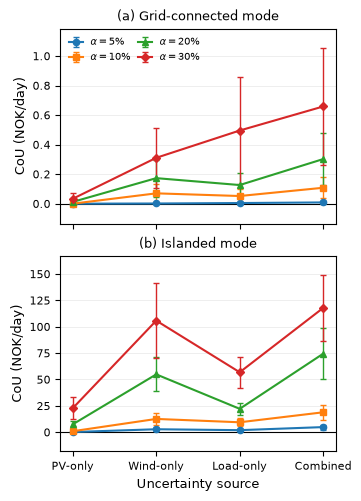


Saved PDF: forced_outage_results_v3\Fig3\Fig3_Source_Sensitivity_CoU_Final.pdf
Saved PNG: forced_outage_results_v3\Fig3\Fig3_Source_Sensitivity_CoU_Final.png
Saved CSV: forced_outage_results_v3\Fig3\Fig3_Source_Sensitivity_CoU_Final_summary.csv


In [147]:
# =========================================================
# Fig.3 IEEE Final
# Uncertainty-source sensitivity of CoU with 95% CI
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# =========================================================
# Load data
# =========================================================

csv_file = Path(
    "source_sensitivity_det_sto_mpc_pf_summary.csv"
)

if not csv_file.exists():
    raise FileNotFoundError(
        f"File not found: {csv_file.resolve()}"
    )


df = pd.read_csv(csv_file)

df.columns = [
    c.strip()
    for c in df.columns
]


# =========================================================
# Data cleaning
# =========================================================

df["mode"] = (
    df["mode"]
    .astype(str)
    .str.upper()
    .str.strip()
)

df["source"] = (
    df["source"]
    .astype(str)
    .str.strip()
)


mode_order = [
    "GC",
    "IS"
]


source_order = [
    "PV-only",
    "Wind-only",
    "Load-only",
    "Combined"
]


alpha_order = [
    0.05,
    0.10,
    0.20,
    0.30
]


df = df[
    df["mode"].isin(mode_order)
]


df = df[
    df["source"].isin(source_order)
]


df = df[
    df["alpha"].isin(alpha_order)
]


df["mode"] = pd.Categorical(
    df["mode"],
    categories=mode_order,
    ordered=True
)


df["source"] = pd.Categorical(
    df["source"],
    categories=source_order,
    ordered=True
)


df["alpha"] = pd.Categorical(
    df["alpha"],
    categories=alpha_order,
    ordered=True
)


df = (
    df
    .sort_values(
        [
            "mode",
            "alpha",
            "source"
        ]
    )
    .reset_index(drop=True)
)



# =========================================================
# Full verification print
# =========================================================

print("\n===== Fig.3 Dataset Verification =====\n")

print(
    df[
        [
            "mode",
            "source",
            "alpha",
            "cou_nok",
            "cou_ci95_low",
            "cou_ci95_high"
        ]
    ]
    .to_string(index=False)
)


print("\nRows by mode and alpha:")
print(
    df.groupby(
        [
            "mode",
            "alpha"
        ],
        observed=False
    )
    .size()
)



# =========================================================
# Output folder
# =========================================================

outdir = Path(
    "forced_outage_results_v3/Fig3"
)

outdir.mkdir(
    parents=True,
    exist_ok=True
)


pdf_path = (
    outdir /
    "Fig3_Source_Sensitivity_CoU_Final.pdf"
)


png_path = (
    outdir /
    "Fig3_Source_Sensitivity_CoU_Final.png"
)


csv_path = (
    outdir /
    "Fig3_Source_Sensitivity_CoU_Final_summary.csv"
)


df.to_csv(
    csv_path,
    index=False
)



# =========================================================
# Plot style
# =========================================================

plt.rcParams.update({

    "font.size": 8,

    "axes.labelsize": 9,

    "axes.titlesize": 9,

    "legend.fontsize": 7,

    "xtick.labelsize": 8,

    "ytick.labelsize": 8

})


alpha_style = {

    0.05:
    {
        "color":"#1f77b4",
        "marker":"o",
        "label":r"$\alpha=5\%$"
    },


    0.10:
    {
        "color":"#ff7f0e",
        "marker":"s",
        "label":r"$\alpha=10\%$"
    },


    0.20:
    {
        "color":"#2ca02c",
        "marker":"^",
        "label":r"$\alpha=20\%$"
    },


    0.30:
    {
        "color":"#d62728",
        "marker":"D",
        "label":r"$\alpha=30\%$"
    }

}



# =========================================================
# Figure
# =========================================================

fig, axes = plt.subplots(

    2,
    1,

    figsize=(3.5,4.9),

    sharex=True,

    constrained_layout=True

)


x = np.arange(
    len(source_order)
)



# =========================================================
# Plot GC and IS
# =========================================================


for ax, mode in zip(
    axes,
    mode_order
):


    subset = df[
        df["mode"] == mode
    ]


    for alpha in alpha_order:


        temp = subset[
            subset["alpha"] == alpha
        ].sort_values(
            "source"
        )


        y = temp["cou_nok"].astype(float).values


        lower = (
            y -
            temp["cou_ci95_low"]
            .astype(float)
            .values
        )


        upper = (
            temp["cou_ci95_high"]
            .astype(float)
            .values
            -
            y
        )


        yerr = np.vstack(
            [
                lower,
                upper
            ]
        )


        style = alpha_style[alpha]


        ax.errorbar(

            x,

            y,

            yerr=yerr,

            color=style["color"],

            marker=style["marker"],

            markersize=4.5,

            linewidth=1.5,

            elinewidth=1,

            capsize=2.5,

            label=style["label"],

            zorder=3

        )



    # Titles

    if mode == "GC":

        ax.set_title(
            "(a) Grid-connected mode"
        )

    else:

        ax.set_title(
            "(b) Islanded mode"
        )


    ax.set_ylabel(
        "CoU (NOK/day)"
    )


    ax.grid(
        axis="y",
        alpha=0.25,
        linewidth=0.6
    )


    ax.set_axisbelow(
        True
    )


    ax.axhline(
        0,
        color="black",
        linewidth=0.8
    )



    # Independent y-axis

    ymin = min(
        subset["cou_ci95_low"].min(),
        0
    )


    ymax = (
        subset["cou_ci95_high"]
        .max()
    )


    margin = (
        ymax-ymin
    )*0.12


    ax.set_ylim(
        ymin-margin,
        ymax+margin
    )



# =========================================================
# Axis and legend
# =========================================================


axes[0].legend(

    loc="upper left",

    ncol=2,

    frameon=False,

    columnspacing=0.8,

    handlelength=1.4

)



axes[1].set_xticks(
    x
)


axes[1].set_xticklabels(
    source_order
)


axes[1].set_xlabel(
    "Uncertainty source"
)



# =========================================================
# Save
# =========================================================


fig.savefig(
    pdf_path,
    bbox_inches="tight"
)


fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)


plt.show()



print("\nSaved PDF:", pdf_path)
print("Saved PNG:", png_path)
print("Saved CSV:", csv_path)

Loaded file: source_sensitivity_det_sto_mpc_pf_summary.csv
       source mode  alpha       cou_nok  cou_ci95_low  cou_ci95_high
0    Combined   GC   0.05  8.451387e-03 -1.669402e-03   1.857218e-02
1   Load-only   GC   0.05  4.332226e-03 -6.830566e-04   9.347509e-03
2     PV-only   GC   0.05  7.458601e-15 -1.438150e-16   1.506102e-14
3   Wind-only   GC   0.05  1.234697e-03 -3.351794e-04   2.804573e-03
4    Combined   GC   0.10  1.077431e-01  3.720179e-02   1.782844e-01
5   Load-only   GC   0.10  5.189033e-02  7.617886e-03   9.616278e-02
6     PV-only   GC   0.10  7.514549e-15 -8.208881e-17   1.511119e-14
7   Wind-only   GC   0.10  6.999722e-02  9.269336e-03   1.307251e-01
8    Combined   GC   0.20  3.019902e-01  1.234171e-01   4.805633e-01
9   Load-only   GC   0.20  1.262253e-01  4.310461e-02   2.093460e-01
10    PV-only   GC   0.20  1.211882e-02 -3.771012e-04   2.461473e-02
11  Wind-only   GC   0.20  1.729092e-01  4.781865e-02   2.979997e-01


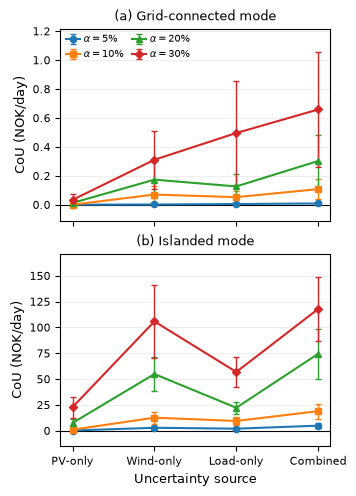

Saved summary CSV: forced_outage_results_v3\Fig3\Fig3_Source_Sensitivity_CoU_IEEE_summary.csv
Saved PDF: forced_outage_results_v3\Fig3\Fig3_Source_Sensitivity_CoU_IEEE.pdf
Saved PNG: forced_outage_results_v3\Fig3\Fig3_Source_Sensitivity_CoU_IEEE.png


In [155]:
# =========================================================
# Fig.3 Polished Final
# Uncertainty-source sensitivity of CoU with 95% CI
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Input file
# ---------------------------------------------------------
csv_file = Path("source_sensitivity_det_sto_mpc_pf_summary.csv")

if not csv_file.exists():
    raise FileNotFoundError(f"Could not find: {csv_file.resolve()}")

df = pd.read_csv(csv_file)
df.columns = [c.strip() for c in df.columns]

print("Loaded file:", csv_file)
print(df[["source", "mode", "alpha", "cou_nok", "cou_ci95_low", "cou_ci95_high"]].head(12))

# ---------------------------------------------------------
# Required columns check
# ---------------------------------------------------------
required_cols = {
    "source", "mode", "alpha",
    "cou_nok", "cou_ci95_low", "cou_ci95_high"
}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ---------------------------------------------------------
# Standardize text
# ---------------------------------------------------------
df["mode"] = df["mode"].astype(str).str.upper().str.strip()
df["source"] = df["source"].astype(str).str.strip()

# ---------------------------------------------------------
# Keep only needed modes/sources/alphas in fixed order
# ---------------------------------------------------------
mode_order = ["GC", "IS"]
source_order = ["PV-only", "Wind-only", "Load-only", "Combined"]
alpha_order = [0.05, 0.10, 0.20, 0.30]

df = df[df["mode"].isin(mode_order)].copy()
df = df[df["source"].isin(source_order)].copy()
df = df[df["alpha"].isin(alpha_order)].copy()

# Category ordering
df["mode"] = pd.Categorical(df["mode"], categories=mode_order, ordered=True)
df["source"] = pd.Categorical(df["source"], categories=source_order, ordered=True)
df["alpha"] = pd.Categorical(df["alpha"], categories=alpha_order, ordered=True)

df = df.sort_values(["mode", "alpha", "source"]).reset_index(drop=True)

# ---------------------------------------------------------
# Check completeness
# ---------------------------------------------------------
expected_rows = len(mode_order) * len(source_order) * len(alpha_order)
if len(df) != expected_rows:
    print(f"Warning: expected {expected_rows} rows, found {len(df)} rows.")
    print(df.groupby(["mode", "source"])["alpha"].apply(list))

# ---------------------------------------------------------
# Save cleaned summary used in the figure
# ---------------------------------------------------------
outdir = Path("forced_outage_results_v3/Fig3")
outdir.mkdir(parents=True, exist_ok=True)

csv_out = outdir / "Fig3_Source_Sensitivity_CoU_IEEE_summary.csv"
pdf_out = outdir / "Fig3_Source_Sensitivity_CoU_IEEE.pdf"
png_out = outdir / "Fig3_Source_Sensitivity_CoU_IEEE.png"

df.to_csv(csv_out, index=False)

# ---------------------------------------------------------
# Plot settings
# ---------------------------------------------------------
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

alpha_styles = {
    0.05: {"color": "#1f77b4", "marker": "o", "label": r"$\alpha = 5\%$"},
    0.10: {"color": "#ff7f0e", "marker": "s", "label": r"$\alpha = 10\%$"},
    0.20: {"color": "#2ca02c", "marker": "^", "label": r"$\alpha = 20\%$"},
    0.30: {"color": "#d62728", "marker": "D", "label": r"$\alpha = 30\%$"},
}

x = np.arange(len(source_order))

# IEEE single-column friendly
fig, axes = plt.subplots(
    2, 1,
    figsize=(3.45, 4.85),
    sharex=True,
    constrained_layout=True
)

# ---------------------------------------------------------
# Plot each mode separately with independent y-scale
# ---------------------------------------------------------
for ax, mode in zip(axes, mode_order):
    sub = df[df["mode"] == mode].copy()

    for alpha in alpha_order:
        tmp = sub[sub["alpha"] == alpha].sort_values("source")

        y = tmp["cou_nok"].to_numpy(dtype=float)
        yerr_lower = y - tmp["cou_ci95_low"].to_numpy(dtype=float)
        yerr_upper = tmp["cou_ci95_high"].to_numpy(dtype=float) - y
        yerr = np.vstack([yerr_lower, yerr_upper])

        style = alpha_styles[alpha]

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            marker=style["marker"],
            markersize=4.5,
            linewidth=1.5,
            elinewidth=1.0,
            capsize=2.5,
            color=style["color"],
            label=style["label"],
            zorder=3
        )

    ax.set_title("(a) Grid-connected mode" if mode == "GC" else "(b) Islanded mode")
    ax.set_ylabel("CoU (NOK/day)")
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6, zorder=0)
    ax.axhline(0, color="black", linewidth=0.8, zorder=1)

    # Independent y-axis limits for each panel
    low = sub["cou_ci95_low"].min()
    high = sub["cou_ci95_high"].max()

    ymin = min(0, low)
    ymax = high

    span = ymax - ymin
    if span <= 1e-12:
        span = 1.0

    ax.set_ylim(
        ymin - 0.10 * span,
        ymax + 0.15 * span
    )

# Legend only in the top panel
axes[0].legend(
    loc="upper left",
    ncol=2,
    frameon=False,
    handlelength=1.4,
    columnspacing=0.9,
    handletextpad=0.4,
    borderaxespad=0.2
)

# X-axis only on bottom panel
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(source_order)
axes[-1].set_xlabel("Uncertainty source")

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------
fig.savefig(pdf_out, bbox_inches="tight")
fig.savefig(png_out, dpi=600, bbox_inches="tight")

plt.show()

print("Saved summary CSV:", csv_out)
print("Saved PDF:", pdf_out)
print("Saved PNG:", png_out)


Loaded DET: forced_outage_representative_2020-11-19_det_hourly.csv
   hour_raw  grid_available  grid_import  grid_export   dg  soc  shed_crit  \
0       0.0             1.0          0.0     6.170178  0.0  0.5        0.0   
1       1.0             1.0          0.0     8.403302  0.0  0.5        0.0   
2       2.0             1.0          0.0    25.607784  0.0  0.5        0.0   
3       3.0             1.0          0.0    51.664013  0.0  0.5        0.0   
4       4.0             1.0          0.0    13.210907  0.0  0.5        0.0   

   shed_ncrit  hour   net_grid  shed_total  soc_plot  
0         0.0     1  -6.170178         0.0      50.0  
1         0.0     2  -8.403302         0.0      50.0  
2         0.0     3 -25.607784         0.0      50.0  
3         0.0     4 -51.664013         0.0      50.0  
4         0.0     5 -13.210907         0.0      50.0  

Loaded STO: forced_outage_representative_2020-11-19_sto_hourly.csv
   hour_raw  grid_available  grid_import  grid_export   dg  soc  

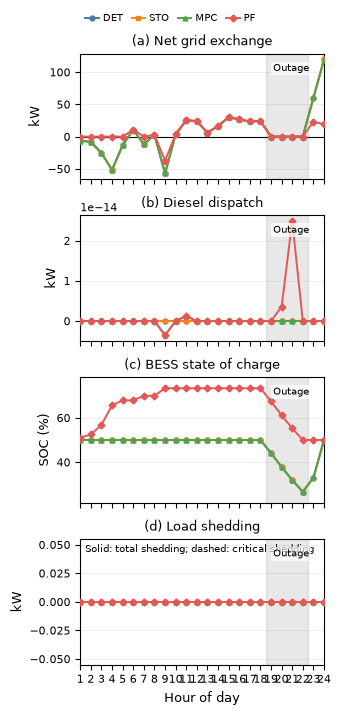


Saved PDF: forced_outage_results_v3\Fig4\Fig4_Representative_Forced_Outage_Response_IEEE.pdf
Saved PNG: forced_outage_results_v3\Fig4\Fig4_Representative_Forced_Outage_Response_IEEE.png


In [186]:
# =========================================================
# Fig.4 IEEE Final
# Representative forced grid-outage response
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Input files (run this notebook from the project root)
# ---------------------------------------------------------
files = {
    "DET": "forced_outage_representative_2020-11-19_det_hourly.csv",
    "STO": "forced_outage_representative_2020-11-19_sto_hourly.csv",
    "MPC": "forced_outage_representative_2020-11-19_mpc_hourly.csv",
    "PF":  "forced_outage_representative_2020-11-19_pf_hourly.csv",
}

# ---------------------------------------------------------
# Output folder
# ---------------------------------------------------------
outdir = Path("forced_outage_results_v3/Fig4")
outdir.mkdir(parents=True, exist_ok=True)

pdf_path = outdir / "Fig4_Representative_Forced_Outage_Response_IEEE.pdf"
png_path = outdir / "Fig4_Representative_Forced_Outage_Response_IEEE.png"

# ---------------------------------------------------------
# Helper
# ---------------------------------------------------------
def first_existing(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Could not find any of these columns: {candidates}")
    return None

# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------
data = {}

for strategy, fname in files.items():
    path = Path(fname)
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path.resolve()}")

    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]

    # required columns
    hour_col = first_existing(df, ["hour"])
    grid_col = first_existing(df, ["grid_available"])

    # use explicit import/export if available; otherwise fall back to buy/sell
    import_col = first_existing(df, ["grid_import_kwh", "buy"])
    export_col = first_existing(df, ["grid_export_kwh", "sell"])

    dg_col = first_existing(df, ["dg", "diesel_kwh"])
    soc_col = first_existing(df, ["soc_end", "soc_start", "soc"], required=False)

    shed_crit_col = first_existing(df, ["shed_crit", "critical_eens_kwh"])
    shed_ncrit_col = first_existing(df, ["shed_ncrit", "noncritical_eens_kwh"])

    keep = pd.DataFrame({
        "hour_raw": df[hour_col].astype(float),
        "grid_available": df[grid_col].astype(float),
        "grid_import": df[import_col].astype(float),
        "grid_export": df[export_col].astype(float),
        "dg": df[dg_col].astype(float),
        "soc": np.nan if soc_col is None else df[soc_col].astype(float),
        "shed_crit": df[shed_crit_col].astype(float),
        "shed_ncrit": df[shed_ncrit_col].astype(float),
    }).copy()

    # convert hour to 1...24 if file stores 0...23
    if keep["hour_raw"].min() == 0:
        keep["hour"] = keep["hour_raw"].astype(int) + 1
    else:
        keep["hour"] = keep["hour_raw"].astype(int)

    # net grid exchange: positive = import, negative = export
    keep["net_grid"] = keep["grid_import"] - keep["grid_export"]

    # total shedding
    keep["shed_total"] = keep["shed_crit"] + keep["shed_ncrit"]

    # SOC convert to %
    if keep["soc"].notna().any():
        soc_max = np.nanmax(keep["soc"].values)
        if soc_max <= 1.5:
            keep["soc_plot"] = 100.0 * keep["soc"]
        else:
            keep["soc_plot"] = keep["soc"]
    else:
        keep["soc_plot"] = np.nan

    data[strategy] = keep

    print(f"\nLoaded {strategy}: {fname}")
    print(keep.head())

# ---------------------------------------------------------
# Determine outage window from first dataset
# ---------------------------------------------------------
ref = data["DET"].copy()
out_mask = ref["grid_available"] == 0

if out_mask.any():
    outage_hours = ref.loc[out_mask, "hour"].tolist()
    outage_start = min(outage_hours)
    outage_end = max(outage_hours)
else:
    outage_start = None
    outage_end = None

print("\nOutage window:", outage_start, "to", outage_end)

# ---------------------------------------------------------
# Plot style
# ---------------------------------------------------------
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

styles = {
    "DET": {"color": "#4C78A8", "marker": "o"},
    "STO": {"color": "#F58518", "marker": "s"},
    "MPC": {"color": "#54A24B", "marker": "^"},
    "PF":  {"color": "#E45756", "marker": "D"},
}

# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------
fig, axes = plt.subplots(
    4, 1,
    figsize=(3.45, 7.2),
    sharex=True,
    constrained_layout=False
)

hours = data["DET"]["hour"].values

# =========================
# (a) Net grid exchange
# =========================
ax = axes[0]
for s in ["DET", "STO", "MPC", "PF"]:
    ax.plot(
        hours,
        data[s]["net_grid"],
        label=s,
        color=styles[s]["color"],
        marker=styles[s]["marker"],
        linewidth=1.4,
        markersize=3.5,
        zorder=3
    )

ax.set_title("(a) Net grid exchange")
ax.set_ylabel("kW")
ax.axhline(0, color="black", linewidth=0.8, zorder=2)
ax.grid(axis="y", alpha=0.25, linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

# =========================
# (b) Diesel dispatch
# =========================
ax = axes[1]
for s in ["DET", "STO", "MPC", "PF"]:
    ax.plot(
        hours,
        data[s]["dg"],
        label=s,
        color=styles[s]["color"],
        marker=styles[s]["marker"],
        linewidth=1.4,
        markersize=3.5,
        zorder=3
    )

ax.set_title("(b) Diesel dispatch")
ax.set_ylabel("kW")
ax.grid(axis="y", alpha=0.25, linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

# =========================
# (c) BESS state of charge
# =========================
ax = axes[2]
for s in ["DET", "STO", "MPC", "PF"]:
    ax.plot(
        hours,
        data[s]["soc_plot"],
        label=s,
        color=styles[s]["color"],
        marker=styles[s]["marker"],
        linewidth=1.4,
        markersize=3.5,
        zorder=3
    )

ax.set_title("(c) BESS state of charge")
ax.set_ylabel("SOC (%)")
ax.grid(axis="y", alpha=0.25, linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

# reasonable SOC limits if data exist
all_soc = np.concatenate([data[s]["soc_plot"].to_numpy() for s in data.keys()])
all_soc = all_soc[~np.isnan(all_soc)]
if len(all_soc) > 0:
    ymin = max(0, np.nanmin(all_soc) - 5)
    ymax = min(100, np.nanmax(all_soc) + 5)
    if ymax - ymin < 10:
        ymax = min(100, ymin + 10)
    ax.set_ylim(ymin, ymax)

# =========================
# (d) Load shedding
# solid = total, dashed = critical
# =========================
ax = axes[3]
for s in ["DET", "STO", "MPC", "PF"]:
    ax.plot(
        hours,
        data[s]["shed_total"],
        color=styles[s]["color"],
        marker=styles[s]["marker"],
        linewidth=1.4,
        markersize=3.5,
        linestyle="-",
        zorder=3
    )
    ax.plot(
        hours,
        data[s]["shed_crit"],
        color=styles[s]["color"],
        linewidth=1.2,
        linestyle="--",
        zorder=3
    )

ax.set_title("(d) Load shedding")
ax.set_ylabel("kW")
ax.set_xlabel("Hour of day")
ax.grid(axis="y", alpha=0.25, linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

ax.text(
    0.02, 0.96,
    "Solid: total shedding; dashed: critical shedding",
    transform=ax.transAxes,
    ha="left", va="top", fontsize=7
)

# ---------------------------------------------------------
# Add outage shading to all panels
# ---------------------------------------------------------
if outage_start is not None and outage_end is not None:
    for ax in axes:
        ax.axvspan(
            outage_start - 0.5,
            outage_end + 0.5,
            color="gray",
            alpha=0.18,
            zorder=1
        )

        y0, y1 = ax.get_ylim()
        ax.text(
            outage_start + 0.2,
            y1 - 0.08 * (y1 - y0),
            "Outage",
            fontsize=7,
            ha="left",
            va="top",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.7,
                pad=1.5
            )
        )

# ---------------------------------------------------------
# Common legend
# ---------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.99),
    columnspacing=0.9,
    handlelength=1.4,
    handletextpad=0.4
)

# ---------------------------------------------------------
# X-axis ticks
# ---------------------------------------------------------
axes[-1].set_xticks(np.arange(1, 25, 1))
axes[-1].set_xlim(1, 24)

# ---------------------------------------------------------
# Tight layout + save
# ---------------------------------------------------------
fig.tight_layout(rect=[0, 0, 1, 0.965])

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=600, bbox_inches="tight")

plt.show()

print("\nSaved PDF:", pdf_path)
print("Saved PNG:", png_path)

Outage window: 19 to 22


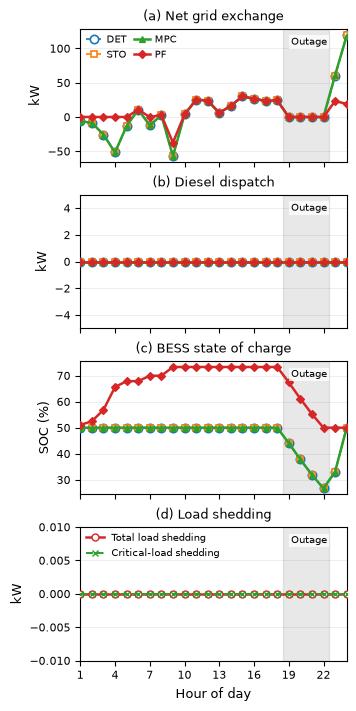

Saved PDF: forced_outage_results_v3\Fig4\Fig4_Representative_Forced_Outage_Response_IEEE_Final.pdf
Saved PNG: forced_outage_results_v3\Fig4\Fig4_Representative_Forced_Outage_Response_IEEE_Final.png


In [41]:
# =========================================================
# Fig.4 IEEE Final Polished (fully fixed)
# Representative forced-outage hourly response
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# Input files
# ---------------------------------------------------------
files = {
    "DET": "forced_outage_representative_2020-11-19_det_hourly.csv",
    "STO": "forced_outage_representative_2020-11-19_sto_hourly.csv",
    "MPC": "forced_outage_representative_2020-11-19_mpc_hourly.csv",
    "PF":  "forced_outage_representative_2020-11-19_pf_hourly.csv",
}

# ---------------------------------------------------------
# Output folder
# ---------------------------------------------------------
outdir = Path("forced_outage_results_v3/Fig4")
outdir.mkdir(parents=True, exist_ok=True)

pdf_path = outdir / "Fig4_Representative_Forced_Outage_Response_IEEE_Final.pdf"
png_path = outdir / "Fig4_Representative_Forced_Outage_Response_IEEE_Final.png"

# ---------------------------------------------------------
# Helper to find available column
# ---------------------------------------------------------
def get_col(df, names):
    for n in names:
        if n in df.columns:
            return n
    raise KeyError(f"Could not find any of these columns: {names}")

# ---------------------------------------------------------
# Load and standardize data
# ---------------------------------------------------------
data = {}

for strategy, file in files.items():
    df = pd.read_csv(file)
    df.columns = [c.strip() for c in df.columns]

    hour_col = get_col(df, ["hour"])
    grid_col = get_col(df, ["grid_available"])
    import_col = get_col(df, ["grid_import_kwh", "buy"])
    export_col = get_col(df, ["grid_export_kwh", "sell"])
    dg_col = get_col(df, ["dg", "diesel_kwh"])
    soc_col = get_col(df, ["soc_end", "soc_start", "soc"])
    crit_col = get_col(df, ["shed_crit"])
    ncrit_col = get_col(df, ["shed_ncrit"])

    d = pd.DataFrame({
        "hour": df[hour_col].astype(float),
        "grid_available": df[grid_col].astype(float),
        "grid_import": df[import_col].astype(float),
        "grid_export": df[export_col].astype(float),
        "dg": df[dg_col].astype(float),
        "soc": df[soc_col].astype(float),
        "shed_crit": df[crit_col].astype(float),
        "shed_ncrit": df[ncrit_col].astype(float),
    })

    # convert hour 0-23 to 1-24 if needed
    if d["hour"].min() == 0:
        d["hour"] = d["hour"] + 1

    # clean numerical noise
    d["dg"] = d["dg"].where(np.abs(d["dg"]) > 1e-6, 0.0)

    # positive = import, negative = export
    d["net_grid"] = d["grid_import"] - d["grid_export"]

    # total shedding
    d["shed_total"] = d["shed_crit"] + d["shed_ncrit"]

    # SOC in %
    if d["soc"].max() <= 1.5:
        d["soc_plot"] = 100.0 * d["soc"]
    else:
        d["soc_plot"] = d["soc"]

    data[strategy] = d

# ---------------------------------------------------------
# Outage window
# ---------------------------------------------------------
ref = data["DET"]
mask = ref["grid_available"] == 0

if mask.any():
    outage_start = int(ref.loc[mask, "hour"].min())
    outage_end = int(ref.loc[mask, "hour"].max())
else:
    outage_start, outage_end = None, None

print("Outage window:", outage_start, "to", outage_end)

# ---------------------------------------------------------
# Plot style
# ---------------------------------------------------------
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

styles = {
    "DET": {
        "color": "#1f77b4",
        "marker": "o",
        "linestyle": "--",
        "linewidth": 1.2,
        "markersize": 6,
        "markerfacecolor": "white",
        "markeredgewidth": 1.2,
    },
    "STO": {
        "color": "#ff7f0e",
        "marker": "s",
        "linestyle": "--",
        "linewidth": 1.2,
        "markersize": 4.3,
        "markerfacecolor": "white",
        "markeredgewidth": 1.2,
    },
    "MPC": {
        "color": "#2ca02c",
        "marker": "^",
        "linestyle": "-",
        "linewidth": 1.8,
        "markersize": 4.6,
        "markerfacecolor": "#2ca02c",
        "markeredgewidth": 0.9,
    },
    "PF": {
        "color": "#d62728",
        "marker": "D",
        "linestyle": "-",
        "linewidth": 1.8,
        "markersize": 4.3,
        "markerfacecolor": "#d62728",
        "markeredgewidth": 0.9,
    },
}

# ---------------------------------------------------------
# Figure and axes
# ---------------------------------------------------------
fig, axes = plt.subplots(
    4, 1,
    figsize=(3.45, 7.0),
    sharex=True,
    constrained_layout=True
)

hours = data["DET"]["hour"].values

# ---------------------------------------------------------
# Helper to draw one panel
# ---------------------------------------------------------
def draw_series(ax, colname):
    for s in ["DET", "STO", "MPC", "PF"]:
        st = styles[s]
        ax.plot(
            hours,
            data[s][colname].values,
            color=st["color"],
            linestyle=st["linestyle"],
            linewidth=st["linewidth"],
            marker=st["marker"],
            markersize=st["markersize"],
            markerfacecolor=st["markerfacecolor"],
            markeredgecolor=st["color"],
            markeredgewidth=st["markeredgewidth"],
            label=s,
            zorder=3
        )

# ---------------------------------------------------------
# (a) Net grid exchange
# ---------------------------------------------------------
draw_series(axes[0], "net_grid")
axes[0].set_title("(a) Net grid exchange")
axes[0].set_ylabel("kW")

# custom legend so marker shapes are always clear
strategy_handles = []
for s in ["DET", "STO", "MPC", "PF"]:
    st = styles[s]
    strategy_handles.append(
        Line2D(
            [0], [0],
            color=st["color"],
            linestyle=st["linestyle"],
            linewidth=st["linewidth"],
            marker=st["marker"],
            markersize=st["markersize"],
            markerfacecolor=st["markerfacecolor"],
            markeredgecolor=st["color"],
            markeredgewidth=st["markeredgewidth"],
            label=s
        )
    )

axes[0].legend(
    handles=strategy_handles,
    loc="upper left",
    ncol=2,
    frameon=False,
    handlelength=1.6,
    columnspacing=0.8,
    handletextpad=0.5,
    borderaxespad=0.2
)

# ---------------------------------------------------------
# (b) Diesel dispatch
# ---------------------------------------------------------
draw_series(axes[1], "dg")
axes[1].set_title("(b) Diesel dispatch")
axes[1].set_ylabel("kW")

dg_all = np.concatenate([data[s]["dg"].values for s in data])
dg_absmax = np.max(np.abs(dg_all))
dg_lim = max(5, 1.15 * dg_absmax if dg_absmax > 0 else 5)
axes[1].set_ylim(-dg_lim, dg_lim)

# ---------------------------------------------------------
# (c) BESS state of charge
# ---------------------------------------------------------
draw_series(axes[2], "soc_plot")
axes[2].set_title("(c) BESS state of charge")
axes[2].set_ylabel("SOC (%)")

# ---------------------------------------------------------
# (d) Load shedding
# ---------------------------------------------------------
ax = axes[3]

# Since all strategies overlap here, use one clean style legend:
# black solid = total shedding, black dashed = critical shedding

# You can use DET as representative if all strategies are identical here
shed_total_plot = data["DET"]["shed_total"].values
shed_crit_plot = data["DET"]["shed_crit"].values

ax.plot(
    hours,
    shed_total_plot,
    color="#d62728",
    linestyle="-",
    linewidth=1.8,
    marker="o",
    markersize=5,
    markerfacecolor="white",
    markeredgecolor="#d62728",
    label="Total load shedding",
    zorder=3
)

ax.plot(
    hours,
    shed_crit_plot,
    color="#2ca02c",
    linestyle="--",
    linewidth=1.4,
    marker="x",
    markersize=4.0,
    label="Critical-load shedding",
    zorder=3
)

ax.set_title("(d) Load shedding")
ax.set_ylabel("kW")
ax.set_xlabel("Hour of day")

shed_all = np.concatenate([
    data[s]["shed_total"].values for s in data
] + [
    data[s]["shed_crit"].values for s in data
])

shed_absmax = np.max(np.abs(shed_all))
shed_lim = max(0.01, 1.25 * shed_absmax if shed_absmax > 0 else 0.01)
ax.set_ylim(-shed_lim, shed_lim)

ax.legend(
    loc="upper left",
    frameon=False,
    handlelength=1.8,
    borderaxespad=0.2
)

# ---------------------------------------------------------
# Common formatting
# ---------------------------------------------------------
for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6, zorder=0)

    if outage_start is not None:
        ax.axvspan(
            outage_start - 0.5,
            outage_end + 0.5,
            color="gray",
            alpha=0.18,
            zorder=1
        )

        ymin, ymax = ax.get_ylim()
        y_text = ymax - 0.12 * (ymax - ymin)

        ax.text(
            outage_start + 0.2,
            y_text,
            "Outage",
            fontsize=7,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
                pad=1.5
            ),
            zorder=4
        )

# x-axis ticks
axes[-1].set_xticks(np.arange(1, 25, 3))
axes[-1].set_xlim(1, 24)

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=600, bbox_inches="tight")

plt.show()

print("Saved PDF:", pdf_path)
print("Saved PNG:", png_path)

In [181]:
import pandas as pd

file = "forced_outage_representative_2020-11-19_mpc_hourly.csv"

df = pd.read_csv(file)

print(df.shape)
print("\nColumns:")
for c in df.columns:
    print(c)

print("\nFirst 5 rows:")
print(df.head())

(24, 28)

Columns:
hour
grid_available
pv
wind
dg
charge
discharge
buy
sell
shed_crit
shed_ncrit
curtailment
soc_start
soc_end
cost_nok
critical_eens_kwh
noncritical_eens_kwh
diesel_kwh
curtailment_kwh
grid_import_kwh
grid_export_kwh
anchor_terminal_dev_soc
anchor_terminal_dev_kwh
balance_residual_kw
local_solve_time_s
anchor_solve_time_s
strategy
date

First 5 rows:
   hour  grid_available   pv   wind   dg  charge  discharge  buy       sell  \
0     0               1  0.0  26.12  0.0     0.0        0.0  0.0   6.170178   
1     1               1  0.0  29.44  0.0     0.0        0.0  0.0   8.403302   
2     2               1  0.0  45.89  0.0     0.0        0.0  0.0  25.607784   
3     3               1  0.0  72.16  0.0     0.0        0.0  0.0  51.664013   
4     4               1  0.0  36.29  0.0     0.0        0.0  0.0  13.210907   

   shed_crit  ...  curtailment_kwh  grid_import_kwh  grid_export_kwh  \
0        0.0  ...              0.0              0.0         6.170178   
1        0.

In [180]:
import pandas as pd

for f in [
    "forced_outage_representative_2020-11-19_det_hourly.csv",
    "forced_outage_representative_2020-11-19_sto_hourly.csv",
    "forced_outage_representative_2020-11-19_mpc_hourly.csv",
    "forced_outage_representative_2020-11-19_pf_hourly.csv",
]:
    df = pd.read_csv(f)
    print("\n", f)
    print(df.columns.tolist())


 forced_outage_representative_2020-11-19_det_hourly.csv
['hour', 'phase', 'grid_available', 'pv', 'wind', 'dg', 'charge', 'discharge', 'buy', 'sell', 'shed_crit', 'shed_ncrit', 'curtailment', 'soc_start', 'soc_end', 'balance_residual_kw', 'strategy', 'date']

 forced_outage_representative_2020-11-19_sto_hourly.csv
['hour', 'phase', 'grid_available', 'pv', 'wind', 'dg', 'charge', 'discharge', 'buy', 'sell', 'shed_crit', 'shed_ncrit', 'curtailment', 'soc_start', 'soc_end', 'balance_residual_kw', 'strategy', 'date']

 forced_outage_representative_2020-11-19_mpc_hourly.csv
['hour', 'grid_available', 'pv', 'wind', 'dg', 'charge', 'discharge', 'buy', 'sell', 'shed_crit', 'shed_ncrit', 'curtailment', 'soc_start', 'soc_end', 'cost_nok', 'critical_eens_kwh', 'noncritical_eens_kwh', 'diesel_kwh', 'curtailment_kwh', 'grid_import_kwh', 'grid_export_kwh', 'anchor_terminal_dev_soc', 'anchor_terminal_dev_kwh', 'balance_residual_kw', 'local_solve_time_s', 'anchor_solve_time_s', 'strategy', 'date']

 

In [171]:
import os

print(os.getcwd())

E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL


In [177]:
for x in Path.cwd().iterdir():
    print(x.name)

.ipynb_checkpoints
09_Forced_Grid_Outage_Islanding_FULL.ipynb
config
data
Fig2_CoU_SMR_RR_GC_IS.pdf
Fig2_CoU_SMR_RR_GC_IS.png
Fig6_Forced_Outage_Response_Final.pdf
Fig6_Forced_Outage_Response_Final.png
Fig6_Forced_Outage_Trajectory.pdf
Fig6_Forced_Outage_Trajectory.png
figures_source_sensitivity
final_oos_det_sto_mpc_pf_daily.csv
forced_outage_alpha20_v3_checkpoint.csv
forced_outage_alpha20_v3_daily.csv
forced_outage_alpha20_v3_summary.csv
forced_outage_alpha20_v3_with_baseline.csv
forced_outage_representative_2020-11-19_det_hourly.csv
forced_outage_representative_2020-11-19_mpc_hourly.csv
forced_outage_representative_2020-11-19_pf_hourly.csv
forced_outage_representative_2020-11-19_sto_hourly.csv
forced_outage_results_v3
forced_outage_stress_2021-02-02_det_hourly.csv
forced_outage_stress_2021-02-02_mpc_hourly.csv
forced_outage_stress_2021-02-02_pf_hourly.csv
forced_outage_stress_2021-02-02_sto_hourly.csv
Operational_Performance_Summary.csv
README_FORCED_GRID_OUTAGE_FULL.txt
source_sens

Loaded DET (24, 18)
Loaded STO (24, 18)
Loaded MPC (24, 28)
Loaded PF (24, 18)
Outage window: 19 to 22


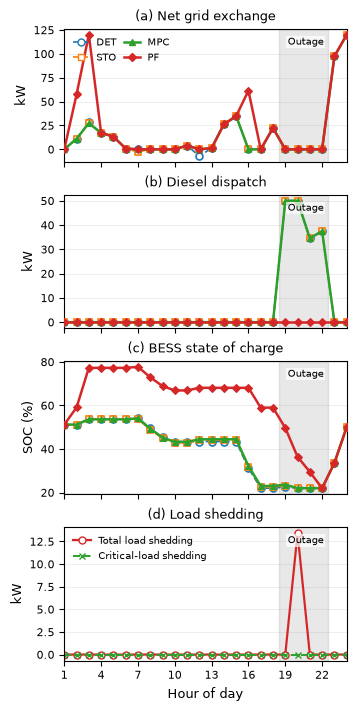


Saved PDF: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\Fig5\Fig5_Stress_Forced_Outage_Response_IEEE_Final.pdf
Saved PNG: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\Fig5\Fig5_Stress_Forced_Outage_Response_IEEE_Final.png


In [217]:
# =========================================================
# Fig.5 IEEE Final Polished
# Stress forced-outage hourly response
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D


# =========================================================
# Path
# =========================================================

base = Path(
r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL"
)


files = {

    "DET": "forced_outage_stress_2021-02-02_det_hourly.csv",
    "STO": "forced_outage_stress_2021-02-02_sto_hourly.csv",
    "MPC": "forced_outage_stress_2021-02-02_mpc_hourly.csv",
    "PF":  "forced_outage_stress_2021-02-02_pf_hourly.csv"

}



# =========================================================
# Load data
# =========================================================

data = {}


for strategy, file in files.items():

    path = base / file

    if not path.exists():
        raise FileNotFoundError(path)


    df = pd.read_csv(path)

    df.columns = [
        c.strip()
        for c in df.columns
    ]


    print(
        "Loaded",
        strategy,
        df.shape
    )


    temp = pd.DataFrame()


    temp["hour"] = (
        df["hour"]
        .astype(float)
        + 1
    )


    # grid exchange
    temp["net_grid"] = (
        df["buy"].astype(float)
        -
        df["sell"].astype(float)
    )


    # diesel
    dg = df["dg"].astype(float)

    dg[np.abs(dg) < 1e-6] = 0

    temp["dg"] = dg



    # SOC
    soc = df["soc_end"].astype(float)

    if soc.max() <= 1.5:
        temp["soc"] = soc * 100
    else:
        temp["soc"] = soc



    # shedding

    temp["shed_total"] = (
        df["shed_crit"].astype(float)
        +
        df["shed_ncrit"].astype(float)
    )


    temp["shed_crit"] = (
        df["shed_crit"].astype(float)
    )


    data[strategy] = temp




# =========================================================
# Forced outage window
# =========================================================

outage_start = 19
outage_end = 22


print(
    "Outage window:",
    outage_start,
    "to",
    outage_end
)



# =========================================================
# Plot style
# =========================================================

plt.rcParams.update({

    "font.size":8,
    "axes.labelsize":9,
    "axes.titlesize":9,
    "legend.fontsize":7,
    "xtick.labelsize":8,
    "ytick.labelsize":8

})



styles = {


"DET":
{
    "color":"#1f77b4",
    "marker":"o",
    "linestyle":"--",
    "linewidth":1.2,
    "markersize":5,
    "face":"white",
    "edge":1.2
},


"STO":
{
    "color":"#ff7f0e",
    "marker":"s",
    "linestyle":"--",
    "linewidth":1.2,
    "markersize":4.5,
    "face":"white",
    "edge":1.2
},


"MPC":
{
    "color":"#2ca02c",
    "marker":"^",
    "linestyle":"-",
    "linewidth":1.8,
    "markersize":4.8,
    "face":"#2ca02c",
    "edge":0.8
},


"PF":
{
    "color":"#d62728",
    "marker":"D",
    "linestyle":"-",
    "linewidth":1.8,
    "markersize":4.5,
    "face":"#d62728",
    "edge":0.8
}

}



# =========================================================
# Figure
# =========================================================

fig, axes = plt.subplots(

    4,
    1,

    figsize=(3.45,7.0),

    sharex=True,

    constrained_layout=True

)



hours = data["DET"]["hour"]



# =========================================================
# Common draw function
# =========================================================

def draw_series(ax, column):


    for s in [
        "DET",
        "STO",
        "MPC",
        "PF"
    ]:

        st = styles[s]


        ax.plot(

            hours,

            data[s][column],

            color=st["color"],

            linestyle=st["linestyle"],

            linewidth=st["linewidth"],

            marker=st["marker"],

            markersize=st["markersize"],

            markerfacecolor=st["face"],

            markeredgecolor=st["color"],

            markeredgewidth=st["edge"],

            label=s,

            zorder=3

        )




# =========================================================
# (a) Net grid
# =========================================================

draw_series(
    axes[0],
    "net_grid"
)


axes[0].set_title(
    "(a) Net grid exchange"
)

axes[0].set_ylabel(
    "kW"
)



# custom legend

handles=[]


for s in [
    "DET",
    "STO",
    "MPC",
    "PF"
]:

    st=styles[s]


    handles.append(

        Line2D(

            [0],

            [0],

            color=st["color"],

            linestyle=st["linestyle"],

            linewidth=st["linewidth"],

            marker=st["marker"],

            markersize=st["markersize"],

            markerfacecolor=st["face"],

            markeredgecolor=st["color"],

            label=s

        )

    )


axes[0].legend(

    handles=handles,

    loc="upper left",

    ncol=2,

    frameon=False,

    handlelength=1.6,

    columnspacing=0.8

)



# =========================================================
# (b) Diesel
# =========================================================

draw_series(
    axes[1],
    "dg"
)


axes[1].set_title(
    "(b) Diesel dispatch"
)

axes[1].set_ylabel(
    "kW"
)



# =========================================================
# (c) SOC
# =========================================================

draw_series(
    axes[2],
    "soc"
)


axes[2].set_title(
    "(c) BESS state of charge"
)


axes[2].set_ylabel(
    "SOC (%)"
)



# =========================================================
# (d) Load shedding
# =========================================================

ax = axes[3]


ax.plot(

    hours,

    data["DET"]["shed_total"],

    color="#d62728",

    marker="o",

    markersize=5,

    markerfacecolor="white",

    linewidth=1.6,

    label="Total load shedding"

)


ax.plot(

    hours,

    data["DET"]["shed_crit"],

    color="#2ca02c",

    marker="x",

    linestyle="--",

    linewidth=1.4,

    markersize=4,

    label="Critical-load shedding"

)


ax.set_title(
    "(d) Load shedding"
)


ax.set_ylabel(
    "kW"
)


ax.set_xlabel(
    "Hour of day"
)


ax.legend(

    loc="upper left",

    frameon=False,

    handlelength=1.8

)



# =========================================================
# Common formatting
# =========================================================

for ax in axes:


    ax.grid(

        axis="y",

        alpha=0.25,

        linewidth=0.6

    )


    ax.set_axisbelow(True)



    ax.axvspan(

        outage_start-0.5,

        outage_end+0.5,

        color="gray",

        alpha=0.18,

        zorder=1

    )


    ymin,ymax=ax.get_ylim()


    ax.text(

        outage_start+0.2,

        ymax-0.12*(ymax-ymin),

        "Outage",

        fontsize=7,

        bbox=dict(

            facecolor="white",

            edgecolor="none",

            alpha=0.7,

            pad=1

        )

    )



axes[-1].set_xticks(
    np.arange(1,25,3)
)


axes[-1].set_xlim(
    1,
    24
)



# =========================================================
# Save
# =========================================================

outdir = (
base /
"forced_outage_results_v3" /
"Fig5"
)


outdir.mkdir(
    parents=True,
    exist_ok=True
)


pdf = (
outdir /
"Fig5_Stress_Forced_Outage_Response_IEEE_Final.pdf"
)


png = (
outdir /
"Fig5_Stress_Forced_Outage_Response_IEEE_Final.png"
)



fig.savefig(
    pdf,
    bbox_inches="tight"
)


fig.savefig(
    png,
    dpi=600,
    bbox_inches="tight"
)


plt.show()


print("\nSaved PDF:", pdf)
print("Saved PNG:", png)

Loaded: DET (24, 18)
Loaded: STO (24, 18)
Loaded: MPC (24, 28)
Loaded: PF (24, 18)

All strategies loaded successfully
Detected outage: 19 - 22


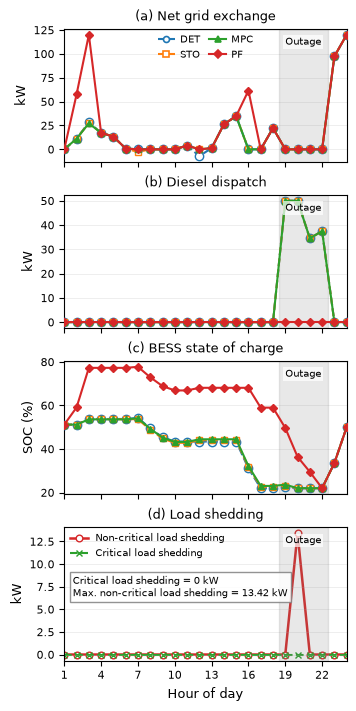


Saved PDF:
E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\Fig5\Fig5\Stress\Fig5_Stress_Forced_Outage_Response_IEEE_Final.pdf

Saved PNG:
E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\forced_outage_results_v3\Fig5\Fig5\Stress\Fig5_Stress_Forced_Outage_Response_IEEE_Final.png


In [42]:
# =========================================================
# Fig.5 IEEE Final Fixed
# Stress forced-outage response
# Part 1/2
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.lines import Line2D


# =========================================================
# Base folder
# =========================================================

base = Path(
r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL"
)


# =========================================================
# Input files
# =========================================================

files = {

    "DET":
    "forced_outage_stress_2021-02-02_det_hourly.csv",

    "STO":
    "forced_outage_stress_2021-02-02_sto_hourly.csv",

    "MPC":
    "forced_outage_stress_2021-02-02_mpc_hourly.csv",

    "PF":
    "forced_outage_stress_2021-02-02_pf_hourly.csv"

}


# =========================================================
# Load data
# =========================================================

data = {}


for strategy, filename in files.items():

    path = base / filename

    if not path.exists():
        raise FileNotFoundError(path)


    df = pd.read_csv(path)

    df.columns = [
        c.strip()
        for c in df.columns
    ]


    print(
        "Loaded:",
        strategy,
        df.shape
    )


    d = pd.DataFrame({

        "hour":
        df["hour"].astype(float),

        "grid_available":
        df["grid_available"].astype(float),

        "buy":
        df["buy"].astype(float),

        "sell":
        df["sell"].astype(float),

        "dg":
        df["dg"].astype(float),

        "soc":
        df["soc_end"].astype(float),

        "shed_crit":
        df["shed_crit"].astype(float),

        "shed_ncrit":
        df["shed_ncrit"].astype(float)

    })


    # 0-23 to 1-24

    if d["hour"].min() == 0:

        d["hour"] = d["hour"] + 1



    # numerical cleaning

    d["dg"] = np.where(
        abs(d["dg"]) < 1e-6,
        0,
        d["dg"]
    )


    # grid exchange

    d["net_grid"] = (
        d["buy"]
        -
        d["sell"]
    )


    # total shedding

    d["shed_total"] = (
        d["shed_crit"]
        +
        d["shed_ncrit"]
    )


    # SOC %

    if d["soc"].max() <= 1.5:

        d["soc_plot"] = (
            d["soc"] * 100
        )

    else:

        d["soc_plot"] = d["soc"]



    data[strategy] = d



print("\nAll strategies loaded successfully")



# =========================================================
# Outage detection
# =========================================================

ref = data["DET"]


mask = (
    ref["grid_available"] == 0
)


if mask.any():

    outage_start = int(
        ref.loc[
            mask,
            "hour"
        ].min()
    )


    outage_end = int(
        ref.loc[
            mask,
            "hour"
        ].max()
    )


else:

    outage_start = None
    outage_end = None



print(
    "Detected outage:",
    outage_start,
    "-",
    outage_end
)



# =========================================================
# IEEE Style
# =========================================================

plt.rcParams.update({

    "font.size":8,

    "axes.labelsize":9,

    "axes.titlesize":9,

    "legend.fontsize":7,

    "xtick.labelsize":8,

    "ytick.labelsize":8

})



styles = {


"DET":
{
    "color":"#1f77b4",
    "marker":"o",
    "linestyle":"--",
    "plot_size":6,
    "legend_size":4.3
},


"STO":
{
    "color":"#ff7f0e",
    "marker":"s",
    "linestyle":"--",
    "plot_size":4.3,
    "legend_size":4.3
},


"MPC":
{
    "color":"#2ca02c",
    "marker":"^",
    "linestyle":"-",
    "plot_size":4.6,
    "legend_size":4.3
},


"PF":
{
    "color":"#d62728",
    "marker":"D",
    "linestyle":"-",
    "plot_size":4.3,
    "legend_size":4.3
}

}



# =========================================================
# Figure setup
# =========================================================

fig, axes = plt.subplots(

    4,
    1,

    figsize=(3.45,7.0),

    sharex=True,

    constrained_layout=True

)


hours = data["DET"]["hour"].values



# =========================================================
# Plot function
# =========================================================

def plot_strategy(ax, variable):

    for s in [
        "DET",
        "STO",
        "MPC",
        "PF"
    ]:

        st = styles[s]


        ax.plot(

            hours,

            data[s][variable],

            color=st["color"],

            linestyle=st["linestyle"],

            marker=st["marker"],

            markersize=st["plot_size"],

            linewidth=1.5,

            markerfacecolor=(
                "white"
                if s in ["DET","STO"]
                else st["color"]
            ),

            markeredgecolor=st["color"],

            markeredgewidth=1.0,

            zorder=3

        )



# =========================================================
# Panels (a), (b), (c)
# =========================================================


plot_strategy(
    axes[0],
    "net_grid"
)

axes[0].set_title(
    "(a) Net grid exchange"
)

axes[0].set_ylabel(
    "kW"
)



plot_strategy(
    axes[1],
    "dg"
)

axes[1].set_title(
    "(b) Diesel dispatch"
)

axes[1].set_ylabel(
    "kW"
)



plot_strategy(
    axes[2],
    "soc_plot"
)

axes[2].set_title(
    "(c) BESS state of charge"
)

axes[2].set_ylabel(
    "SOC (%)"
)



# =========================================================
# Panel (d)
# Critical vs Non-critical shedding
# =========================================================

ax = axes[3]


# Representative shedding profile
# All strategies show identical shedding behaviour
# for this stress scenario

noncritical = data["DET"]["shed_ncrit"].values
critical = data["DET"]["shed_crit"].values



# Non-critical shedding

ax.plot(

    hours,

    noncritical,

    color="#d62728",

    linestyle="-",

    linewidth=1.8,

    marker="o",

    markersize=4.8,

    markerfacecolor="white",

    markeredgecolor="#d62728",

    markeredgewidth=1.0,

    label="Non-critical load shedding",

    zorder=0

)



# Critical shedding

ax.plot(

    hours,

    critical,

    color="#2ca02c",

    linestyle="--",

    linewidth=1.5,

    marker="x",

    markersize=4.2,

    label="Critical load shedding",

    zorder=0

)



ax.set_title(
    "(d) Load shedding"
)


ax.set_ylabel(
    "kW"
)


ax.set_xlabel(
    "Hour of day"
)



# =========================================================
# Observation box
# Left-middle position
# =========================================================

max_noncritical = np.max(noncritical)

max_critical = np.max(critical)


if max_critical <= 1e-6:


    observation_text = (

        "Critical load shedding = 0 kW\n"

        f"Max. non-critical load shedding = "
        f"{max_noncritical:.2f} kW"

    )


else:


    observation_text = (

        f"Critical load shedding observed\n"

        f"Maximum critical load shedding = "
        f"{max_critical:.2f} kW\n"

        f"Maximum non-critical load shedding = "
        f"{max_noncritical:.2f} kW"

    )



ax.text(

    0.03,

    0.55,

    observation_text,

    transform=ax.transAxes,

    ha="left",

    va="center",

    fontsize=7,

    bbox=dict(

        facecolor="white",

        edgecolor="gray",

        alpha=0.85,

        pad=2

    )

)



ax.legend(

    loc="upper left",

    frameon=False,

    handlelength=1.8,

    borderaxespad=0.2

)



# =========================================================
# Strategy legend (only panel a)
# unchanged
# =========================================================

handles = []


for s in [

    "DET",
    "STO",
    "MPC",
    "PF"

]:

    st = styles[s]


    handles.append(

        Line2D(

            [0],

            [0],

            color=st["color"],

            linestyle=st["linestyle"],

            linewidth=1.5,


            marker=st["marker"],

            markersize=st["legend_size"],


            markerfacecolor=(

                "white"

                if s in ["DET","STO"]

                else st["color"]

            ),


            markeredgecolor=st["color"],

            markeredgewidth=1.2,


            label=s

        )

    )



axes[0].legend(

    handles=handles,

    loc="upper center",

    ncol=2,

    frameon=False,

    handlelength=1.8,

    columnspacing=0.9,

    handletextpad=0.5,

    borderaxespad=0.2

)



# =========================================================
# Formatting
# =========================================================


for ax in axes:


    ax.grid(

        axis="y",

        alpha=0.25,

        linewidth=0.6

    )


    ax.set_axisbelow(True)



    if outage_start is not None:


        ax.axvspan(

            outage_start-0.5,

            outage_end+0.5,

            color="gray",

            alpha=0.18,

            zorder=1

        )


        ymin, ymax = ax.get_ylim()


        ax.text(

            outage_start,

            ymax - 0.12*(ymax-ymin),

            "Outage",

            fontsize=7,

            bbox=dict(

                facecolor="white",

                edgecolor="none",

                alpha=0.7,

                pad=1.5

            )

        )



# x-axis

axes[-1].set_xticks(
    np.arange(1,25,3)
)


axes[-1].set_xlim(
    1,
    24
)



# =========================================================
# Save
# =========================================================

outdir = (

    base

    /

    "forced_outage_results_v3"

    /

    "Fig5"

    /

    "Fig5"

    /

    "Stress"

)


outdir.mkdir(

    parents=True,

    exist_ok=True

)



pdf = (

    outdir

    /

    "Fig5_Stress_Forced_Outage_Response_IEEE_Final.pdf"

)


png = (

    outdir

    /

    "Fig5_Stress_Forced_Outage_Response_IEEE_Final.png"

)



fig.savefig(

    pdf,

    bbox_inches="tight"

)


fig.savefig(

    png,

    dpi=600,

    bbox_inches="tight"

)



plt.show()



print("\nSaved PDF:")
print(pdf)


print("\nSaved PNG:")
print(png)

In [277]:
from pathlib import Path

base = Path(
r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL"
)

print("Exists:", base.exists())

for f in base.glob("*stress*hourly.csv"):
    print(f.name)

Exists: True
forced_outage_stress_2021-02-02_det_hourly.csv
forced_outage_stress_2021-02-02_mpc_hourly.csv
forced_outage_stress_2021-02-02_pf_hourly.csv
forced_outage_stress_2021-02-02_sto_hourly.csv
Table_Stress_Outage_Hourly.csv


In [275]:
import pandas as pd

df = pd.read_csv("final_oos_det_sto_mpc_pf_daily.csv")

metrics = {
    "DET cost": "det_cost_nok",
    "STO cost": "sto_cost_nok",
    "MPC cost": "mpc_cost_nok",
    "PF cost": "pf_cost_nok",

    "DET diesel": "det_diesel_kwh",
    "STO diesel": "sto_diesel_kwh",
    "MPC diesel": "mpc_diesel_kwh",
    "PF diesel": "pf_diesel_kwh",

    "DET curtailment": "det_curtailment_kwh",
    "STO curtailment": "sto_curtailment_kwh",
    "MPC curtailment": "mpc_curtailment_kwh",
    "PF curtailment": "pf_curtailment_kwh",

    "DET grid import": "det_grid_import_kwh",
    "STO grid import": "sto_grid_import_kwh",
    "MPC grid import": "mpc_grid_import_kwh",
    "PF grid import": "pf_grid_import_kwh",

    "DET grid export": "det_grid_export_kwh",
    "STO grid export": "sto_grid_export_kwh",
    "MPC grid export": "mpc_grid_export_kwh",
    "PF grid export": "pf_grid_export_kwh",

    "MPC solve time": "mpc_total_solve_time_s",
}


summary = {}

for name,col in metrics.items():
    summary[name] = [
        df[col].mean(),
        1.96*df[col].std()/len(df)**0.5
    ]

pd.DataFrame(
    summary,
    index=["Mean","95% CI"]
).T

,Mean,95% CI
DET cost,961.915929,69.916010
STO cost,941.896504,69.238858
MPC cost,937.904392,69.116405
PF cost,934.806910,69.020841
DET diesel,195.959023,16.868347
STO diesel,198.246109,16.919118
MPC diesel,198.212809,16.955002
PF diesel,197.853119,16.950925
DET curtailment,88.877146,21.176737
STO curtailment,87.741390,21.175496


In [280]:

from pathlib import Path

base = Path(
r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL"
)

for f in base.rglob("*.csv"):
    print(f.name)

final_oos_det_sto_mpc_pf_daily.csv
forced_outage_alpha20_v3_checkpoint.csv
forced_outage_alpha20_v3_daily.csv
forced_outage_alpha20_v3_summary.csv
forced_outage_alpha20_v3_with_baseline.csv
forced_outage_representative_2020-11-19_det_hourly.csv
forced_outage_representative_2020-11-19_mpc_hourly.csv
forced_outage_representative_2020-11-19_pf_hourly.csv
forced_outage_representative_2020-11-19_sto_hourly.csv
forced_outage_stress_2021-02-02_det_hourly.csv
forced_outage_stress_2021-02-02_mpc_hourly.csv
forced_outage_stress_2021-02-02_pf_hourly.csv
forced_outage_stress_2021-02-02_sto_hourly.csv
Operational_Performance_Summary.csv
rye_development_304days.csv
rye_oos_127days.csv
source_sensitivity_det_sto_mpc_pf_daily.csv
source_sensitivity_det_sto_mpc_pf_summary.csv
Table_Master_Performance_Comparison.csv
Table_Representative_Outage_Hourly.csv
Table_Stress_Outage_Hourly.csv
source_sensitivity_det_sto_mpc_pf_daily-checkpoint.csv
rye_development_304days.csv
rye_oos_127days.csv
final_oos_det_sto

In [281]:
import pandas as pd
from pathlib import Path
import numpy as np

base = Path(
r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL"
)

# ---- computation time ----
df = pd.read_csv(base/"final_oos_det_sto_mpc_pf_daily.csv")

comp = {
    "DET": df["det_solve_time_s"].mean(),
    "STO": df["sto_solve_time_s"].mean(),
    "MPC": df["mpc_total_solve_time_s"].mean(),
    "PF":  df["pf_solve_time_s"].mean()
}

print("Average computation time (s)")
print(pd.Series(comp))


# ---- BESS throughput ----
# if hourly files are stored separately

throughput = {
    "DET": [],
    "STO": [],
    "MPC": [],
    "PF": []
}

for f in base.glob("*_hourly.csv"):

    name = f.name.lower()

    if "det" in name:
        key="DET"
    elif "sto" in name:
        key="STO"
    elif "mpc" in name:
        key="MPC"
    elif "pf" in name:
        key="PF"
    else:
        continue

    x=pd.read_csv(f)

    if "charge" in x.columns and "discharge" in x.columns:
        throughput[key].append(
            (x["charge"]+x["discharge"]).sum()
        )


print("\nAverage BESS throughput (kWh)")
for k,v in throughput.items():
    print(k, np.mean(v))

Average computation time (s)
DET    0.133482
STO    3.466781
MPC    1.707547
PF     0.064516
dtype: float64

Average BESS throughput (kWh)
DET 305.5280434102942
STO 308.8808141451667
MPC 311.17659738239297
PF 436.6863182304412


In [283]:
# =========================================================
# Table IV Data Extraction
# Reliability / EENS under Forced Grid-Outage Stress Test
# =========================================================

import pandas as pd
from pathlib import Path
import numpy as np


# =========================================================
# Base folder
# =========================================================

base = Path(
r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL"
)


# =========================================================
# Input files
# =========================================================

files = {

    "DET-DA":
    "forced_outage_stress_2021-02-02_det_hourly.csv",

    "STO-DA":
    "forced_outage_stress_2021-02-02_sto_hourly.csv",

    "MPC":
    "forced_outage_stress_2021-02-02_mpc_hourly.csv",

    "PF":
    "forced_outage_stress_2021-02-02_pf_hourly.csv"

}


# =========================================================
# Calculate EENS
# =========================================================

results = []


for strategy, filename in files.items():

    path = base / filename

    if not path.exists():
        raise FileNotFoundError(path)


    df = pd.read_csv(path)

    df.columns = [
        c.strip()
        for c in df.columns
    ]


    # hourly shedding
    shed_crit = df["shed_crit"].astype(float)

    shed_ncrit = df["shed_ncrit"].astype(float)


    # 1 hour resolution
    dt = 1


    critical_EENS = (
        shed_crit.sum()
        *
        dt
    )


    noncritical_EENS = (
        shed_ncrit.sum()
        *
        dt
    )


    total_EENS = (
        critical_EENS
        +
        noncritical_EENS
    )


    # Critical interruption probability
    # percentage of hours where critical shedding >0

    critical_interrupt_probability = (
        np.sum(shed_crit > 1e-6)
        /
        len(shed_crit)
        *
        100
    )


    results.append({

        "Strategy":
        strategy,

        "Critical EENS (kWh)":
        critical_EENS,

        "Non-critical EENS (kWh)":
        noncritical_EENS,

        "Total EENS (kWh)":
        total_EENS,

        "Critical interruption (%)":
        critical_interrupt_probability

    })


# =========================================================
# Table
# =========================================================

table_IV = pd.DataFrame(results)


print("\nTable IV - Reliability Performance")
print("----------------------------------")

print(
    table_IV.round(4)
)


# Optional save

out = base / "Table_IV_Reliability_EENS.csv"

table_IV.to_csv(
    out,
    index=False
)

print("\nSaved:")
print(out)


Table IV - Reliability Performance
----------------------------------
  Strategy  Critical EENS (kWh)  Non-critical EENS (kWh)  Total EENS (kWh)  \
0   DET-DA                  0.0                  13.4189           13.4189   
1   STO-DA                  0.0                  10.3380           10.3380   
2      MPC                  0.0                   8.3799            8.3799   
3       PF                  0.0                   0.0000            0.0000   

   Critical interruption (%)  
0                        0.0  
1                        0.0  
2                        0.0  
3                        0.0  

Saved:
E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\Table_IV_Reliability_EENS.csv


In [286]:
# =========================================================
# Table III Exact CoU / SMR / RR
# =========================================================

import pandas as pd
from pathlib import Path


# ---------------------------------------------------------
# File
# ---------------------------------------------------------

base = Path(
r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL"
)


file = base / "final_oos_det_sto_mpc_pf_daily.csv"


df = pd.read_csv(file)

df.columns = [c.strip() for c in df.columns]


print("Modes:")
print(df["mode"].unique())


# ---------------------------------------------------------
# Calculate
# ---------------------------------------------------------

results=[]


for mode in df["mode"].unique():

    x = df[df["mode"] == mode]


    DET = x["det_cost_nok"].mean()

    STO = x["sto_cost_nok"].mean()

    MPC = x["mpc_cost_nok"].mean()

    PF = x["pf_cost_nok"].mean()


    # Cost of uncertainty

    CoU = DET - PF


    # STO mitigation ratio

    SMR = (
        (DET-STO)
        /
        CoU
        *
        100
    )


    # MPC recovery ratio

    RR = (
        (DET-MPC)
        /
        CoU
        *
        100
    )


    results.append({

        "Mode": mode,

        "DET cost (NOK/day)": DET,

        "STO cost (NOK/day)": STO,

        "MPC cost (NOK/day)": MPC,

        "PF cost (NOK/day)": PF,

        "CoU (NOK/day)": CoU,

        "SMR (%)": SMR,

        "RR (%)": RR

    })


table3 = pd.DataFrame(results)


print("\n===== TABLE III =====")

display(
    table3.round(3)
)


# save

out = base / "Table_III_CoU_SMR_RR.csv"

table3.to_csv(
    out,
    index=False
)

print("\nSaved:", out)

Modes:
<StringArray>
['GC', 'IS']
Length: 2, dtype: str

===== TABLE III =====


,Mode,DET cost (NOK/day),STO cost (NOK/day),MPC cost (NOK/day),PF cost (NOK/day),CoU (NOK/day),SMR (%),RR (%)
0,GC,150.385,150.342,150.468,150.116,0.269,16.128,-30.888
1,IS,1773.447,1733.451,1725.340,1719.498,53.949,74.136,89.170



Saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\Table_III_CoU_SMR_RR.csv


In [2]:
import pandas as pd
from pathlib import Path

file = Path(
r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\final_oos_det_sto_mpc_pf_daily.csv"
)

df = pd.read_csv(file)

print(df["Hp"].unique())

[6]


In [3]:
print(
    df.groupby("mode")["Hp"].describe()
)

      count  mean  std  min  25%  50%  75%  max
mode                                           
GC    508.0   6.0  0.0  6.0  6.0  6.0  6.0  6.0
IS    508.0   6.0  0.0  6.0  6.0  6.0  6.0  6.0


In [4]:
print(df[[
    "mode",
    "Hp",
    "mpc_cost_nok",
    "mpc_noncritical_eens_kwh",
    "mpc_critical_eens_kwh"
]].head())

  mode  Hp  mpc_cost_nok  mpc_noncritical_eens_kwh  mpc_critical_eens_kwh
0   GC   6    -27.918323                       0.0                    0.0
1   IS   6    221.200920                       0.0                    0.0
2   GC   6    -27.918323                       0.0                    0.0
3   IS   6    221.200920                       0.0                    0.0
4   GC   6    -27.918323                       0.0                    0.0


In [5]:
import pandas as pd
from pathlib import Path

file = Path(
r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Forced_Grid_Outage_FULL\final_oos_det_sto_mpc_pf_daily.csv"
)

df = pd.read_csv(file)

print(df["Hp"].unique())

[6]
